In [ ]:
# Importing Libraries
from scipy.spatial import distance
from scipy.stats import wasserstein_distance
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.metrics import (
    accuracy_score,
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)
from mauve import compute_mauve

from typing import List, Dict, Optional, Tuple, Any
from pathlib import Path
import logging 

import pandas as pd
import numpy as np
import subprocess

from openai import OpenAI

import time
import os
import glob

import json # Ensure import is present
import os
import glob
import numpy as np # Ensure import is present
import traceback # Ensure import is present
import json
import stat # For reset_gpus

%matplotlib inline

# Custom Logger
class CustomLogger:
    """
    Logger class that can be accessed from any other
    class to maintain consistent logging across the application.

    """
    # _instance = None
    # _logger: Optional[logging.Logger] = None

    # def __new__(cls):
    #     if cls._instance is None:
    #         cls._instance = super(CustomLogger, cls).__new__(cls)
    #     return cls._instance
    
    def __init__(self, inference_type: Optional[str] = None, 
                 process_name: Optional[str] = None, 
                 model_name: Optional[str] = None, 
                 path: Optional[str] = None,
                 timestamp: Optional[str] = None):
        # Only initialize if not already done
        self.path = path
        self._logger = None
        self.model_name = None
        self.process_name = None
        self.inference_type = None
        self.timestamp = timestamp
        self._setup_logger()

    def _setup_logger(self) -> None:
        """Initialize logger with both file and console handlers"""
        if self.path is None:
            # Create logs directory if it does not exist
            log_dir = Path("./logs")
            log_dir.mkdir(parents=True, exist_ok=True)

            # Create log file with timestamp
            model_suffix = f"{self.model_name}" if self.model_name else ""
            log_file = log_dir / f"{self.path.replace('.csv', '')}.log"
        else:
            log_file = f"{self.path.replace('.csv', '')}.log"
            model_suffix = self.model_name.split("Olama:")[1].split(":")[0] if self.model_name else ""

        # Initialize logger
        logger_name = f"DSM_{self.process_name}_{self.inference_type}_{model_suffix}"
        self._logger = logging.getLogger(logger_name)
        self._logger.setLevel(logging.INFO)

        # Remove any existing handlers
        if self._logger.handlers:
            self._logger.handlers = []

        # Create file handler
        file_handler = logging.FileHandler(log_file)
        file_handler.setLevel(logging.INFO)

        # Create console handler
        console_handler = logging.StreamHandler()
        console_handler.setLevel(logging.INFO)

        # Create formatter and add it to the handlers
        formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
        file_handler.setFormatter(formatter)
        console_handler.setFormatter(formatter)
        
        # Add handlers to logger
        self._logger.addHandler(file_handler)
        self._logger.addHandler(console_handler)

    def info(self, message: str) -> None:
        """Log info message"""
        if self._logger:
            self._logger.info(message)

    def error(self, message: str) -> None:
        """Log error message"""
        if self._logger:
            self._logger.error(message)

    def warning(self, message: str) -> None:
        """Log warning message"""
        if self._logger:
            self._logger.warning(message)

    def debug(self, message: str) -> None:
        """Log debug message"""
        if self._logger:
            self._logger.debug(message)

    def critical(self, message: str) -> None:
        """Log critical message"""
        if self._logger:
            self._logger.critical(message)

    def cleanup(self) -> None:
        """Clean up logger handlers"""
        if self._logger:
            for handler in self._logger.handlers[:]:
                handler.flush()
                handler.close()
                self._logger.removeHandler(handler)

os.environ['OPENAI_API_KEY'] = '<YOUR API KEY>'
api_key = os.getenv('OPENAI_API_KEY')  # Get API key from environment variable

# Similarities and LLM Filtering
def get_embeddings(texts, model="text-embedding-3-small"):
    """
    Create embeddings for a list of texts using OpenAI's API
    
    Args:
        texts: List of strings to get embeddings for
        model: OpenAI embedding model to use
    Returns:
        List of embeddings
    """
    client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))
    
    # Clean and prepare texts
    texts = [str(text).strip().replace("\n", " ") for text in texts]
    
    try:
        response = client.embeddings.create(
            model=model,
            input=texts
        )
        # Extract embeddings from response
        embeddings = [item.embedding for item in response.data]
        return embeddings
    
    except Exception as e:
        print(f"Error getting embeddings: {e}")
        return None

def calculate_semantic_similarities(vec1, vec2, text1=None, text2=None):
    """
    Calculate multiple similarity metrics between two embedding vectors.

    Args:
        vec1, vec2: numpy arrays of some dimension
        text1, text2: original text strings for MAUVE computation
    
    Returns:
        dict: Dictionary containing different similarity scores
    """
    similarities = {
        # Normalized scores (1 = identical, 0 = completely different)
        "cosine": 1 - distance.cosine(vec1, vec2),
        "euclidean": 1 / (1+ distance.euclidean(vec1, vec2)),
        "manhattan": 1 / (1+ distance.cityblock(vec1, vec2)),
        "dot_product": np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2)),
        "chebyshev": 1 / (1+ distance.chebyshev(vec1, vec2)),
        "minkowski": 1 / (1+ distance.minkowski(vec1, vec2, p=2)),
        "canberra": 1 / (1+ distance.canberra(vec1, vec2)),
        "braycurtis": 1 / (1+ distance.braycurtis(vec1, vec2)),
        "jaccard": 1 / (1+ distance.jaccard(vec1, vec2)),
        "hamming": 1 / (1+ distance.hamming(vec1, vec2)),
        
        # Distance metrics (lower = more similar)
        "wasserstein": wasserstein_distance(vec1, vec2),
        "jensenshannon": distance.jensenshannon(vec1, vec2),
    }

    # Add MAUVE score if text is provided
    if text1 is not None and text2 is not None:
        try:
            mauve_score = compute_mauve(
                source_texts=[text1],
                target_texts=[text2],
                device_id=0,  # Use GPU if available
                max_text_length=512,
                verbose=False
            ).mauve
            similarities["mauve"] = mauve_score
        except Exception as e:
            logger.warning(f"Failed to compute MAUVE score: {e}")
            similarities["mauve"] = 0.0

    return similarities

def calculate_similarity_results(product_data, predicted_data):
    """Calculate similarity results between ground truth and predicted components"""
    # Get components and create embeddings
    gt_components = list(product_data.columns)
    pred_components = list(predicted_data.columns)
    all_components = list(set(gt_components + pred_components))

    # Create embeddings for all components
    all_embeddings = get_embeddings(all_components)
    embeddings_dict = {
        component: embedding 
        for component, embedding in zip(all_components, all_embeddings)
    }

    # Initialize similarity results
    similarity_results = []

    # Calculate similarities between components
    for gt_comp in gt_components:
        for pred_comp in pred_components:
            vec1 = embeddings_dict[gt_comp]
            vec2 = embeddings_dict[pred_comp]
            
            # Calculate similarities including MAUVE
            similarities = calculate_semantic_similarities(
                vec1, vec2,
                text1=gt_comp,
                text2=pred_comp
            )
            ensemble_score = ensemble_similarity(vec1, vec2)
            
            result = {
                'ground_truth_component': gt_comp,
                'predicted_component': pred_comp,
                'ground_truth_value': product_data.loc[gt_comp, gt_comp],
                'predicted_value': predicted_data.loc[pred_comp, pred_comp],
                'embedding_similarity': ensemble_score,
                **similarities
            }
            similarity_results.append(result)

    return pd.DataFrame(similarity_results)

def ensemble_similarity(vec1, vec2, weights=None):
    """
    Calculate weighted ensemble of multiple similarity metrics.

    Args:
        vec1, vec2: numpy arrays of same dimension
        weights: dictionary of metric names and their weights
    Returns:
        float: combined similarity score
    """
    if weights is None:
        weights = {
            'cosine': 0.5,
            'mauve': 0.5  # Add MAUVE to default weights
            # 'euclidean': 1.0,
            # 'manhattan': 1.0,
            # 'dot_product': 1.0,
            # 'chebyshev': 1.0,
            # 'minkowski': 1.0,
            # 'canberra': 1.0,
            # 'braycurtis': 1.0,
            # 'jaccard': 1.0,       # Nope
            # 'hamming': 1.0,       # Nope
            # 'wasserstein': 1.0,
            # 'jensenshannon': 1.0, # Nope
        }
    
    similarities = calculate_semantic_similarities(vec1, vec2)

    # Only use available metrics
    available_weights = {k: v for k, v in weights.items() if k in similarities}
    if available_weights:
        # Normalize weights
        weight_sum = sum(available_weights.values())
        normalized_weights = {k: v/weight_sum for k, v in available_weights.items()}
        
        ensemble_score = sum(
            normalized_weights[metric] * similarities[metric]
            for metric in normalized_weights
        )
    else:
        # Fallback to cosine similarity if no weights available
        ensemble_score = similarities.get('cosine', 0.0)

    return ensemble_score

def extract_context_from_path(product_name):
    """
    Extract system context from the product name
    """
    if product_name.lower() == 'powerdrill':
        return 'power drill'
    elif product_name.lower() == 'cubesat':
        return 'cubesat'
    return 'cyber-physical system'  # default fallback

def get_model_from_path(path):
    """Extract model name from the path"""
    if 'ollama' in path.lower():
        # Extract model name for Ollama models
        model_name = path.split('ollama:')[1].split('_')[0]
        return model_name
    elif 'gpt-4-turbo-preview' in path:
        return "gpt-4-turbo-preview"
    elif 'gpt-4o-2024-11-20' in path:
        return "gpt-4o-2024-11-20"
    else:
        return "gpt-4-turbo-preview"  # default fallback

def get_best_component_matches(gt_components, 
                             pred_components, 
                             results_df, 
                             context="mechanical system", 
                             similarity_threshold=0.3,
                             relationship_type='whole-part',
                             logger=None,
                             predicted_path=None):
    """
    Use LLM to select best matches considering all components simultaneously.
    Components with similarity > 0.8 are matched automatically.
    """
    # Use logger if available, otherwise print
    log_func = logger.info if logger and hasattr(logger, 'info') else print
    log_func("Starting get_best_component_matches function")
    
    # Extract model from path
    log_func(f"Extracting model from path: {predicted_path}")
    model = get_model_from_path(predicted_path)
    log_func(f"Extracted model: {model}")
    
    # First, find automatic high-similarity matches
    automatic_matches = {}
    used_pred_components = set()
    remaining_gt = gt_components.copy()
    remaining_pred = pred_components.copy()
    high_similarity_threshold = 0.70
    
    # Find high-similarity matches first (threshold = 0.8)
    for gt_comp in gt_components:
        for pred_comp in pred_components:
            mask = (results_df['ground_truth_component'] == gt_comp) & (results_df['predicted_component'] == pred_comp)
            similarity = results_df.loc[mask, 'embedding_similarity'].values[0]
            
            if similarity > high_similarity_threshold and pred_comp not in used_pred_components:
                automatic_matches[gt_comp] = pred_comp
                used_pred_components.add(pred_comp)
                remaining_gt.remove(gt_comp)
                remaining_pred.remove(pred_comp)
                log_func(f"Automatic high-similarity match: {gt_comp} -> {pred_comp} (similarity: {similarity:.3f})")

    # If all components are matched with high similarity, return early
    if not remaining_gt or not remaining_pred:
        log_func("All components matched with high similarity")
        return automatic_matches

    # Create similarity matrix text for remaining components
    matches_text = ""
    for gt_comp in remaining_gt:
        matches_text += f"\n{gt_comp} potential matches:\n"
        for pred_comp in remaining_pred:
            mask = (results_df['ground_truth_component'] == gt_comp) & (results_df['predicted_component'] == pred_comp)
            similarity = results_df.loc[mask, 'embedding_similarity'].values[0]
            if similarity > similarity_threshold:
                matches_text += f"- {pred_comp} (similarity: {similarity:.3f})\n"
    
    # Update prompt to only consider remaining components
    prompt = f"""You are an expert matching engine for {context} systems. Your task is to determine the optimal one-to-one mapping between remaining ground truth and predicted major components.

Remaining Ground Truth Components:
{remaining_gt}

Remaining Predicted Components:
{remaining_pred}

Note: The following components have already been automatically matched due to high similarity (>0.8):
{[f"{gt} -> {pred}" for gt, pred in automatic_matches.items()]}

Available Matches for Remaining Components (above {similarity_threshold} similarity threshold):
{matches_text}

Instructions:
1. Evaluate each pairing based on:
   - Embedding similarity scores
   - Functional equivalence at the core architecture level
   - System-level {relationship_type} relationships
   - Overall coherence within the {context}
2. Each predicted component may only be matched once
3. Each ground truth component may receive at most one match
4. Do not include any text other than what is specified below
5. Only match the remaining components - do not rematch already matched components

Output Format (exactly as shown):
--------------------------------------------------
MAPPINGS:
[ground truth 1] -> [predicted 1] 
[ground truth 2] -> [predicted 2]
...
REASON: [brief explanation focusing on functional equivalence]
--------------------------------------------------"""

    log_func(f"Prompt: \n{prompt}")
    try:
        log_func(f"Attempting to use model: {model}")
        if 'ollama' in predicted_path:
            log_func("Using Ollama path")
            import requests
            
            request_data = {
                'model': model,
                'prompt': prompt,
                'stream': False
            }
            
            log_func(f"Model name: {model}")
            log_func(f"Prompt length: {len(prompt)}")
            
            response = requests.post(
                'http://localhost:11434/api/generate',
                json=request_data
            )
            
            log_func(f"Response status code: {response.status_code}")
            
            if response.status_code == 200:
                log_func("API call succeeded")
                result = response.json()['response']
                log_func(f"Got response: {result[:100]}...")
            else:
                log_func(f"API call failed: {response.text}")
                raise Exception(f"Error code: {response.status_code} - {response.json()}")
                    
        else:
            # Use OpenAI as fallback
            client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))
            response = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=0
            )
            result = response.choices[0].message.content
        
        # Parse the LLM mappings
        llm_mappings = {}
        in_mappings = False
        for line in result.split('\n'):
            if line.strip() == 'MAPPINGS:':
                in_mappings = True
                continue
            if line.strip().startswith('REASON:'):
                break
            if in_mappings and '->' in line:
                gt, pred = line.split('->')
                gt = gt.strip().strip('[]\'\"').strip()
                pred = pred.strip().strip('[]\'\"').strip()
                if gt in remaining_gt and pred in remaining_pred and pred not in used_pred_components:
                    llm_mappings[gt] = pred
                    used_pred_components.add(pred)

        # Combine automatic matches with valid LLM matches
        all_matches = automatic_matches.copy()
        all_matches.update(llm_mappings)
        
        log_func("\nFinal Mappings:")
        log_func(f"Automatic high-similarity matches: {automatic_matches}")
        log_func(f"LLM-suggested matches: {llm_mappings}")
        
        return all_matches
        
    except Exception as e:
        log_func(f"Error in LLM matching: {e}")
        # Fall back to ensemble similarity matching for remaining components
        for gt in remaining_gt:
            best_match = None
            best_similarity = similarity_threshold
            
            for pred in remaining_pred:
                if pred not in used_pred_components:
                    mask = (results_df['ground_truth_component'] == gt) & (results_df['predicted_component'] == pred)
                    similarity = results_df.loc[mask, 'embedding_similarity'].values[0]
                    
                    if similarity > best_similarity:
                        best_match = pred
                        best_similarity = similarity
            
            if best_match:
                automatic_matches[gt] = best_match
                used_pred_components.add(best_match)
        
        log_func(f"Fallback similarity matching results: {automatic_matches}")
        return automatic_matches

# Evaluator
class DSMevaluator:
    """Evaluates predicted DSM against ground truth."""
    def __init__(self, A_gt, A_pred):
        assert A_gt.shape == A_pred.shape, f"Matrices must have same shape! GT: {A_gt.shape}, Pred: {A_pred.shape}"
        self.A_gt = A_gt.astype(float) # Ensure float type
        self.A_pred = A_pred.astype(float) # Ensure float type

    def cell_by_cell_classification_metrics(self):
        """
        Computes accuracy, precision, recall, and F1 by flattening both
        adjacency matrices into 1D arrays, treating each cell as a binary
        classification (1 vs. 0). Includes diagnostic prints.
        Filters out cells where the predicted value is not 0 or 1 before calculation.
        """
        A_gt_flat = self.A_gt.flatten()
        A_pred_flat = self.A_pred.flatten()

        # Create a mask to identify valid prediction cells (0 or 1)
        valid_indices_mask = (A_pred_flat == 0) | (A_pred_flat == 1)

        # Filter both y_true and y_pred based on the mask
        y_true_filtered = A_gt_flat[valid_indices_mask].astype(float) # Ensure binary {0, 1} for GT
        y_pred_filtered = A_pred_flat[valid_indices_mask].astype(float) # Pred is already 0 or 1 here

        original_size = A_pred_flat.size
        filtered_size = y_pred_filtered.size
        excluded_count = original_size - filtered_size

        # --- Start Diagnostic Prints ---
        print(f"--- Debugging cell_by_cell_classification_metrics ---")
        print(f"Original matrix size (flattened): {original_size}")
        print(f"Number of cells excluded (prediction not 0 or 1): {excluded_count}")
        print(f"Filtered matrix size for metrics: {filtered_size}")

        if filtered_size == 0:
            print("Warning: All prediction cells were filtered out. Returning zero metrics.")
            return 0.0, 0.0, 0.0, 0.0 # Or handle as appropriate, maybe NaNs?

        print(f"Shape of y_true_filtered: {y_true_filtered.shape}")
        print(f"Shape of y_pred_filtered: {y_pred_filtered.shape}")
        print_limit = min(50, filtered_size)
        print(f"First {print_limit} y_true_filtered: {y_true_filtered[:print_limit]}")
        print(f"First {print_limit} y_pred_filtered: {y_pred_filtered[:print_limit]}")

        # Calculate Confusion Matrix for detailed insight using filtered data
        tn, fp, fn, tp = -1, -1, -1, -1 # Default/error values
        try:
            cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=[0, 1])
            print(f"Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): {cm.tolist()}")
            tn, fp, fn, tp = cm.ravel()
            print(f"Confusion Matrix Ravelled (TN, FP, FN, TP): ({tn}, {fp}, {fn}, {tp})")

        except ValueError as e:
            # This might happen if filtered arrays contain only one class after filtering
            print(f"Could not compute/ravel confusion matrix on filtered data: {e}")
            # Attempt to calculate metrics anyway, sklearn functions might handle it.

        print(f"Manual Check - TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")
        # --- End Diagnostic Prints ---

        # Calculate metrics using the filtered arrays
        acc = accuracy_score(y_true_filtered, y_pred_filtered)
        prec = precision_score(y_true_filtered, y_pred_filtered, average='binary', zero_division=0)
        rec = recall_score(y_true_filtered, y_pred_filtered, average='binary', zero_division=0)
        f1 = f1_score(y_true_filtered, y_pred_filtered, average='binary', zero_division=0)

        # --- Start Diagnostic Prints ---
        print(f"Calculated Accuracy: {acc:.4f}  [Formula: (TP+TN)/(TP+TN+FP+FN)]")
        print(f"Calculated Precision (binary, label=1, zero_division=0): {prec:.4f} [Formula: TP/(TP+FP)]")
        print(f"Calculated Recall (binary, label=1, zero_division=0): {rec:.4f}    [Formula: TP/(TP+FN)]")
        print(f"Calculated F1 Score (binary, label=1, zero_division=0): {f1:.4f}  [Formula: 2*(Prec*Rec)/(Prec+Rec)]")
        print(f"--- End Debugging ---")

        return acc, prec, rec, f1

    def adjacency_l1_distance(self):
        """
        Computes the sum of absolute differences between two adjacency matrices.
        Often called 'edit distance' in an unweighted scenario.
        """
        return np.sum(np.abs(self.A_gt - self.A_pred))

    def adjacency_spectral_distance(self):
        """
        Computes the distance between sorted adjacency eigenvalues (L2 norm).
        1) Compute eigenvalues for both
        2) Sort descending (real parts)
        3) Sum of squared differences, then sqrt
        """
        # Eigenvalues
        vals_gt = np.linalg.eigvals(self.A_gt)
        vals_pred = np.linalg.eigvals(self.A_pred)

        # Sort descending by real part
        sort_gt = np.sort(vals_gt.real)[::-1]
        sort_pred = np.sort(vals_pred.real)[::-1]

        # Euclidean (L2) distance
        dist = np.sqrt(np.sum((sort_gt - sort_pred)**2))
        return dist

    def evaluate_all(self):
        """
        Returns a dictionary with:
          - accuracy, precision, recall, f1
          - edit_distance (L1)
          - spectral_distance (adjacency)
        """
        acc, prec, rec, f1 = self.cell_by_cell_classification_metrics()
        edit_dist = self.adjacency_l1_distance()
        spectral_dist = self.adjacency_spectral_distance()

        return {
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1_score": f1,
            "edit_distance": edit_dist,
            "spectral_distance": spectral_dist
        }

# Visualization  
class MetricBarPlotter:
    def __init__(self, A_gt_avg, A_pred_avg,
                product_name: str, model_type: str, model_name: str, ref_type: Optional[str], # Added model_name
                raw_metrics_stats=None, aligned_metrics_stats=None, save_path=None, logger=None):
        self.A_gt_avg = A_gt_avg
        self.A_pred_avg = A_pred_avg
        self.product_name = product_name
        self.model_type = model_type
        self.model_name = model_name # Store model name
        self.ref_type = ref_type
        self.raw_metrics_stats = raw_metrics_stats if raw_metrics_stats else {}
        self.aligned_metrics_stats = aligned_metrics_stats if aligned_metrics_stats else {}
        self.save_path = save_path
        self.logger = logger # Store logger instance

        # Construct base title prefix including model name
        # Extract the core model name if it's an ollama path
        core_model_name = self.model_name
        if 'ollama:' in self.model_name:
            parts = self.model_name.split(':')
            if len(parts) >= 2:
                core_model_name = parts[1] # Take the part after 'ollama:'

        self.title_prefix = f"{self.product_name} / {self.model_type} / {core_model_name}" # Use core_model_name
        if self.ref_type:
            self.title_prefix += f" / {self.ref_type}"

        # Initialize plotting attributes
        self.raw_gt_matrix = None
        self.raw_pred_matrix = None
        self.aligned_gt_matrix = None
        self.aligned_pred_matrix = None
        self.product_data = None
        self.predicted_data = None
        self.gt_components = [] # Ensure these are lists
        self.pred_components = [] # Ensure these are lists

        self.performance_colors = {
            'accuracy': '#E67E22', 'precision': '#2ECC71',
            'recall': '#F1C40F', 'f1_score': '#9B59B6',
        }
        self.distance_colors = {
            'edit_distance': '#3498DB', 'spectral_distance': '#FF5733'
        }
        self.fallback_color = '#808080'

    def save_plot(self, fig, name):
        if self.save_path:
            try:
                plot_dir = Path(self.save_path).parent / 'plots'
                plot_dir.mkdir(exist_ok=True, parents=True)
                plot_path = plot_dir / f"{name}.png"
                fig.savefig(plot_path, bbox_inches='tight', dpi=300)
                # Use self.logger if available
                if self.logger:
                    self.logger.info(f"Saved plot to {plot_path}")
                else:
                    print(f"INFO: Saved plot to {plot_path}") # Fallback print
            except Exception as e:
                 # Use self.logger if available
                 if self.logger:
                     self.logger.error(f"Failed to save plot {name}.png: {e}")
                 else:
                     print(f"ERROR: Failed to save plot {name}.png: {e}") # Fallback print

    def _lighten_color(self, color_input: str, factor: float = 0.4) -> str:
        try:
            import matplotlib.colors as mc
            import colorsys
            try:
                rgb_norm = mc.to_rgb(color_input)
            except ValueError:
                return self.fallback_color # Return fallback if color is invalid
            h, l, s = colorsys.rgb_to_hls(*rgb_norm)
            l = l + (1 - l) * factor
            l = max(0, min(1, l)) # Clamp lightness between 0 and 1
            return mc.to_hex(colorsys.hls_to_rgb(h, l, s))
        except Exception:
             # In case of any other error during color conversion
            return self.fallback_color

    def _get_value_annotation_font_size(self, bar_width_data):
        font_size = max(8, bar_width_data * 100)
        return font_size

    def plot_metrics_comparison(self):
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 13))
        fig.suptitle(f'{self.title_prefix} - Raw vs Aligned Metrics (Mean ± StdDev)', fontsize=18, weight='bold')

        bar_width = 0.8
        capsize = 4

        # Classification Metrics
        cls_metrics=["F1-Score", "Precision", "Recall", "Accuracy"]
        cls_keys=[m.lower().replace('-', '_') for m in cls_metrics]
        cls_colors=[self.performance_colors.get(k, self.fallback_color) for k in cls_keys]
        raw_m_c=[self.raw_metrics_stats.get(f"{k}_mean", np.nan) for k in cls_keys]
        raw_s_c=[self.raw_metrics_stats.get(f"{k}_std", np.nan) for k in cls_keys]
        aln_m_c=[self.aligned_metrics_stats.get(f"{k}_mean", np.nan) for k in cls_keys]
        aln_s_c=[self.aligned_metrics_stats.get(f"{k}_std", np.nan) for k in cls_keys]

        ax1.bar(cls_metrics, raw_m_c, yerr=raw_s_c, color=cls_colors, capsize=capsize, width=bar_width, ecolor='black', error_kw={'elinewidth':1.5})
        ax1.set_ylim(0, 1.05)
        ax1.set_title('Raw LLM Classification Metrics', fontsize=14, weight='bold')
        ax1.set_ylabel("Score (0-1)", fontsize=12)

        ax2.bar(cls_metrics, aln_m_c, yerr=aln_s_c, color=cls_colors, capsize=capsize, width=bar_width, ecolor='black', error_kw={'elinewidth':1.5})
        ax2.set_ylim(0, 1.05)
        ax2.set_title('Aligned Components Classification Metrics', fontsize=14, weight='bold')
        ax2.set_ylabel("Score (0-1)", fontsize=12)

        # Distance Metrics
        dist_metrics=["Edit Distance", "Spectral Distance"]
        dist_keys=[m.lower().replace(' ', '_') for m in dist_metrics]
        dist_colors=[self.distance_colors.get(k, self.fallback_color) for k in dist_keys]
        raw_m_d=[self.raw_metrics_stats.get(f"{k}_mean", np.nan) for k in dist_keys]
        raw_s_d=[self.raw_metrics_stats.get(f"{k}_std", np.nan) for k in dist_keys]
        aln_m_d=[self.aligned_metrics_stats.get(f"{k}_mean", np.nan) for k in dist_keys]
        aln_s_d=[self.aligned_metrics_stats.get(f"{k}_std", np.nan) for k in dist_keys]

        max_r = np.nanmax([np.nansum([m, s]) for m, s in zip(raw_m_d, raw_s_d)]) if raw_m_d else 0
        max_a = np.nanmax([np.nansum([m, s]) for m, s in zip(aln_m_d, aln_s_d)]) if aln_m_d else 0
        y_max_d = max(max_r, max_a) * 1.15

        ax3.bar(dist_metrics, raw_m_d, yerr=raw_s_d, color=dist_colors, capsize=capsize, width=bar_width, ecolor='black', error_kw={'elinewidth':1.5})
        ax3.set_title('Raw LLM Distance Metrics', fontsize=14, weight='bold')
        ax3.set_ylabel("Distance", fontsize=12)

        ax4.bar(dist_metrics, aln_m_d, yerr=aln_s_d, color=dist_colors, capsize=capsize, width=bar_width, ecolor='black', error_kw={'elinewidth':1.5})
        ax4.set_title('Aligned Components Distance Metrics', fontsize=14, weight='bold')
        ax4.set_ylabel("Distance", fontsize=12)

        # Set common y-limit for distance plots
        if not np.isnan(y_max_d) and y_max_d > 0:
            ax3.set_ylim(0, y_max_d)
            ax4.set_ylim(0, y_max_d)
        else:
            # Fallback if max calculation results in NaN or zero
            ax3.set_ylim(0, 1)
            ax4.set_ylim(0, 1)

        # Annotate bars and style axes
        for ax in [ax1, ax2, ax3, ax4]:
            for bar in ax.patches:
                if bar.get_height() > 0:
                    mean_val = bar.get_height()
                    font_sz = max(8, bar.get_width() * 30) # Adjust font size dynamically
                    y_offset = 0.01 * (ax.get_ylim()[1] - ax.get_ylim()[0]) # Small offset above bar
                    ax.text(bar.get_x() + bar.get_width() / 2., mean_val + y_offset,
                            f'{mean_val:.3f}', ha='center', va='bottom',
                            fontsize=font_sz, weight='bold')
            ax.tick_params(axis='x', rotation=0, labelsize=11)
            ax.tick_params(axis='y', labelsize=11)
            ax.grid(axis='y', linestyle='--', alpha=0.6)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        self.save_plot(fig, "metrics_comparison_with_stddev_2x2")
        plt.show()
        plt.close(fig)

    def _plot_individual_metric_group(self, metrics_list: list, metric_type: str, title: str, filename: str,
                                    figsize: tuple = (12, 8), alpha: float = 0.6, # Alpha for transparency
                                    light_factor: float = 0.4,
                                    y_limit: Optional[float] = None, show_legend: bool = False,
                                    bar_spacing_factor: float = 0.55):
        n_metrics = len(metrics_list)
        fig, ax = plt.subplots(figsize=figsize)
        bar_width = 0.35
        index = np.arange(n_metrics)
        spacing = bar_width * bar_spacing_factor
        max_y_val = 0
        color_map = {}
        if metric_type == 'performance':
            color_map = self.performance_colors
        elif metric_type == 'distance':
             color_map = self.distance_colors

        metric_colors = [color_map.get(k, self.fallback_color) for k in metrics_list]

        # Import moved here temporarily for notebook context, ideally at top
        import matplotlib.transforms as mtransforms

        def plot_single_bar_set(means, stds, base_positions, offset, base_colors, group_label):
            nonlocal max_y_val
            bars_list = []
            positions = base_positions + offset
            # Define y-position for labels below bars using blended transform
            label_y_pos_axes = -0.04 # Position slightly below the x-axis baseline in Axes coordinates
            text_trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

            for i, (mean, std) in enumerate(zip(means, stds)):
                mean_num, std_num = np.nan_to_num(mean), np.nan_to_num(std) # Use different var names
                pos = positions[i]
                base_color = base_colors[i]
                lighter_color = self._lighten_color(base_color, light_factor)
                error_bar_alpha = alpha
                lower_bound = max(0, mean_num - std_num)
                upper_bound = mean_num + std_num
                max_y_val = max(max_y_val, upper_bound)

                bar_label = group_label if i == 0 and show_legend else "" # Only label first bar for legend if shown
                bar = ax.bar(pos, mean_num, bar_width, color=base_color, label=bar_label, zorder=2)[0]
                bars_list.append(bar)

                # Draw std dev shading
                if mean_num > lower_bound:
                    ax.bar(pos, mean_num - lower_bound, bar_width, bottom=lower_bound, color=lighter_color, alpha=error_bar_alpha, zorder=3, linewidth=0)
                ax.bar(pos, std_num, bar_width, bottom=mean_num, color=lighter_color, alpha=error_bar_alpha, zorder=3, linewidth=0)

                # Draw markers
                marker_line_width_fraction = 0.1
                line_width = 2.0
                bar_right_edge_x = pos + bar_width / 2
                marker_x_start = bar_right_edge_x - (bar_width * marker_line_width_fraction)
                marker_x_end = bar_right_edge_x
                ax.plot([marker_x_start, marker_x_end], [lower_bound, lower_bound], color='black', linewidth=line_width, zorder=4, solid_capstyle='butt')
                ax.plot([marker_x_start, marker_x_end], [mean_num, mean_num], color='black', linewidth=line_width, zorder=4, solid_capstyle='butt')
                ax.plot([marker_x_start, marker_x_end], [upper_bound, upper_bound], color='black', linewidth=line_width, zorder=4, solid_capstyle='butt')

                # ---- Start: Added Text Label ----
                ax.text(pos, label_y_pos_axes, group_label, # Use group_label ('Raw' or 'Aligned')
                        ha='center', va='top',              # Alignment relative to (pos, label_y_pos_axes)
                        fontsize=8, weight='bold', color='black',
                        transform=text_trans,              # Use blended transform
                        clip_on=False)                     # Allow text outside plot area
                # ---- End: Added Text Label ----

            return bars_list, positions

        # Plot Raw Data
        raw_means = [self.raw_metrics_stats.get(f"{k}_mean", np.nan) for k in metrics_list]
        raw_stds = [self.raw_metrics_stats.get(f"{k}_std", np.nan) for k in metrics_list]
        raw_bars, raw_positions_actual = plot_single_bar_set(raw_means, raw_stds, index, -spacing, metric_colors, 'Raw')

        # Plot Aligned Data
        aligned_means = [self.aligned_metrics_stats.get(f"{k}_mean", np.nan) for k in metrics_list]
        aligned_stds = [self.aligned_metrics_stats.get(f"{k}_std", np.nan) for k in metrics_list]
        aligned_bars, aligned_positions_actual = plot_single_bar_set(aligned_means, aligned_stds, index, spacing, metric_colors, 'Aligned')

        # Annotate bars (Value annotations remain at the top)
        y_text_pos_relative = 0.02
        font_size = self._get_value_annotation_font_size(bar_width)
        value_trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes) # Separate transform for value annotations
        for i, bar in enumerate(raw_bars):
            mean, std = np.nan_to_num(raw_means[i]), np.nan_to_num(raw_stds[i])
            label = f'{mean:.3f}\n±{std:.3f}'
            x_pos_data = raw_positions_actual[i]
            # Note: Using value_trans for these top labels
            ax.text(x_pos_data, y_text_pos_relative, label, ha='center', va='bottom', rotation=90, fontsize=font_size, weight='bold', color='black', transform=value_trans)
        for i, bar in enumerate(aligned_bars):
            mean, std = np.nan_to_num(aligned_means[i]), np.nan_to_num(aligned_stds[i])
            label = f'{mean:.3f}\n±{std:.3f}'
            x_pos_data = aligned_positions_actual[i]
            # Note: Using value_trans for these top labels
            ax.text(x_pos_data, y_text_pos_relative, label, ha='center', va='bottom', rotation=90, fontsize=font_size, weight='bold', color='black', transform=value_trans)


        # Configure Axes and Labels
        ax.set_ylabel('Score', fontsize=14, weight='bold')
        ax.set_title(f'{title} - {self.title_prefix} (Mean ± StdDev)', fontsize=16, weight='bold')
        ax.set_xticks(index)
        ax.set_xticklabels([m.upper().replace('_', ' ') for m in metrics_list], fontsize=11, weight='bold')
        ax.tick_params(axis='y', labelsize=11)

        # ---- Start: Added Adjustment ----
        # Adjust bottom margin to make space for the 'Raw'/'Aligned' labels
        plt.subplots_adjust(bottom=0.15)
        # ---- End: Added Adjustment ----

        if show_legend:
             # Legend drawing code remains, but show_legend is False from calling function
            ax.legend(fontsize=12, loc='best')

        ax.grid(True, axis='y', linestyle=':', alpha=0.5, zorder=0)

        if y_limit is not None:
            ax.set_ylim(0, y_limit)
        else:
            # Adjusted ylim slightly to ensure bottom labels don't touch axis if y=0
            current_ymin = 0 if max_y_val > 0 else -0.1 # Avoid negative limit if max is 0
            current_ymax = max_y_val * 1.20 if max_y_val > 0 else 1
            ax.set_ylim(current_ymin, current_ymax)


        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Changed tight_layout call slightly
        # Use tight_layout *before* saving if possible, or adjust manually
        plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # Adjust rect slightly if needed after subplots_adjust

        self.save_plot(fig, filename)
        plt.show()
        plt.close(fig)

    def plot_performance_metrics_individual(self, save_path_suffix=""):
        metrics = ['accuracy', 'precision', 'recall', 'f1_score']
        title = 'Performance Metrics Comparison'
        filename = f'performance_metrics{save_path_suffix}'
        self._plot_individual_metric_group(metrics, 'performance', title, filename, alpha=0.6, y_limit=1.05, show_legend=False, bar_spacing_factor=0.65) # Enabled legend

    def plot_distance_metrics_individual(self, save_path_suffix=""):
        metrics = ['edit_distance', 'spectral_distance']
        title = 'Distance Metrics Comparison'
        filename = f'distance_metrics{save_path_suffix}'
        self._plot_individual_metric_group(metrics, 'distance', title, filename, alpha=0.6, y_limit=None, show_legend=False, bar_spacing_factor=0.55) # Enabled legend

    def plot_matrices(self):
        """Plot both original (average) and aligned (average) matrices with updated aligned labels."""
        log_func = self.logger.info if self.logger and hasattr(self.logger, 'info') else print
        fig, axes = plt.subplots(2, 2, figsize=(20, 20))
        fig.suptitle(f'Matrix Comparisons: Raw (Avg) vs Aligned (Avg) - {self.title_prefix}', fontsize=18, weight='bold')
        ax1, ax2 = axes[0]
        ax3, ax4 = axes[1]

        def configure_heatmap_axes(ax, title, data, labels, fmt='.1f'):
            if data is not None and labels is not None and len(labels) > 0:
                # Ensure labels are strings before using them
                str_labels = [str(lbl) for lbl in labels]
                annot_kws = {"size": 10} # Default annotation size

                # Adjust annotation size based on matrix size
                if data.shape[0] > 15:
                    annot_kws = {"size": 8}
                elif data.shape[0] > 10:
                    annot_kws = {"size": 9}

                # Create heatmap
                sns.heatmap(data, ax=ax, cmap='YlOrRd', annot=True, fmt=fmt, xticklabels=str_labels, yticklabels=str_labels, cbar=False, annot_kws=annot_kws)

                # Set title
                ax.set_title(title, fontsize=14, weight='bold')

                # Adjust label font size based on label length
                label_fontsize = 11 # Default label size
                max_label_len = 0
                if str_labels:
                    max_label_len = max(len(lbl) for lbl in str_labels)

                if max_label_len > 35:
                    label_fontsize = 8
                elif max_label_len > 25:
                    label_fontsize = 9
                elif max_label_len > 15:
                    label_fontsize = 10

                # Apply label settings
                plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=label_fontsize)
                plt.setp(ax.get_yticklabels(), rotation=0, fontsize=label_fontsize)
            else:
                # Handle cases where data or labels are missing
                ax.set_title(f'{title} - Data Unavailable', fontsize=14, weight='bold')
                ax.axis('off')
                # Optional logging if data or labels are missing but not both None
                if data is not None or (labels is not None and len(labels) > 0):
                    missing_element = 'labels' if data is not None else 'data'
                    log_func(f"Plotting skipped for '{title}': Missing {missing_element}.")

        # Prepare raw matrix labels
        raw_labels_prod = list(self.product_data.columns) if self.product_data is not None else []
        raw_labels_pred = list(self.predicted_data.columns) if self.predicted_data is not None else []

        # Plot raw matrices
        configure_heatmap_axes(ax1, 'Ground Truth Matrix (Raw)', self.raw_gt_matrix, raw_labels_prod)
        configure_heatmap_axes(ax2, 'Predicted Matrix (Raw LLM Average)', self.raw_pred_matrix, raw_labels_pred)

        # Prepare aligned matrix labels
        aligned_gt_labels = self.gt_components if (self.gt_components and len(self.gt_components) > 0) else []
        aligned_pred_labels = [] # Initialize

        # Check if we have everything needed for combined aligned labels
        can_create_combined_labels = (
            self.aligned_pred_matrix is not None and
            self.gt_components and len(self.gt_components) > 0 and
            self.pred_components and len(self.pred_components) == len(self.gt_components) # Crucial check
        )

        if can_create_combined_labels:
            try:
                # Create combined labels: "Predicted Component (Ground Truth Component)"
                str_pred_components = [str(p) for p in self.pred_components]
                str_gt_components = [str(g) for g in self.gt_components]
                aligned_pred_labels = [f"{pred} ({gt})" for pred, gt in zip(str_pred_components, str_gt_components)]
            except Exception as e:
                log_func(f"Error creating combined aligned labels: {e}")
                aligned_pred_labels = [] # Fallback if label creation fails
        else:
            # Log why combined labels cannot be created if expected data is present but conditions not met
            if self.aligned_pred_matrix is None:
                 log_func("Cannot create combined aligned labels: Aligned predicted matrix is missing.")
            elif not self.gt_components:
                log_func("Cannot create combined aligned labels: Ground truth components list is missing or empty.")
            elif not self.pred_components:
                log_func("Cannot create combined aligned labels: Predicted components list is missing or empty.")
            elif self.gt_components and self.pred_components: # Only log length mismatch if both lists exist
                 log_func(f"Cannot create combined aligned labels: gt_components ({len(self.gt_components)}) and pred_components ({len(self.pred_components)}) lengths differ.")


        # Plot aligned matrices
        # For GT aligned, use only GT labels
        configure_heatmap_axes(ax3, 'Ground Truth Matrix (Aligned)', self.aligned_gt_matrix, aligned_gt_labels)
        # For Predicted aligned, use the combined labels if available, otherwise fallback
        configure_heatmap_axes(ax4, 'Predicted Matrix (Aligned Average)', self.aligned_pred_matrix, aligned_pred_labels)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        self.save_plot(fig, "matrices_comparison_avg")
        plt.show()
        plt.close(fig)

# Define the base paths and configurations
# ExperimentConfig class definition
class ExperimentConfig:
    def __init__(self, product_name, model_type, model_name, ref_type=None, relationship_type='all'):
        self.product_name = product_name
        self.model_type = model_type  # 'LLM', 'LLM_RAG', or 'LLM_GRAPH_RAG'
        self.model_name = model_name
        self.ref_type = ref_type  # None for LLM, 'R1', 'R1_R2', etc. for RAG types
        self.relationship_type = relationship_type  # 'all', 'whole-part', 'spatial', etc.

        # Get the absolute path to the current script (notebook-safe version)
        try:
            script_dir = os.path.dirname(os.path.abspath(__file__))
        except NameError:
            # For Jupyter notebooks, use current working directory
            script_dir = os.getcwd()
            if os.path.basename(script_dir) != 'scripts':
                # If not already in scripts dir, add scripts to path
                script_dir = os.path.join(script_dir, 'scripts')
                
        base_dir = os.path.dirname(script_dir)  # Go up one level from scripts/ to xLM_DSM_wip/

        # Construct absolute paths using os.path.join
        self.product_path = os.path.join(base_dir, 'logs', 'Process', f'gt_{product_name.lower()}.csv')

        # Base path construction for predicted files
        base_log_path = os.path.join(base_dir, 'logs', 'Process', 'ii', product_name)
        timestamp_placeholder = '{timestamp}' # Keep placeholder for find_latest_prediction_file

        if self.model_type == 'LLM':
            self.predicted_path = os.path.join(
                base_log_path, 'LLM',
                f'experiment_llm_{model_name}_{timestamp_placeholder}',
                'llm_refs_baseline',
                f'average_matrix_{timestamp_placeholder}.csv'
            )
        elif self.model_type == 'LLM_RAG':
             # Uses 'te3s' intermediate directory based on original code
            self.predicted_path = os.path.join(
                base_log_path, 'te3s', 'LLM_RAG',
                f'experiment_llm_rag_{model_name}_{timestamp_placeholder}',
                f'llm_rag_refs_{ref_type}',
                f'average_matrix_{timestamp_placeholder}.csv'
            )
        elif self.model_type == 'LLM_GRAPH_RAG': # Added condition for GRAPH_RAG
             # Assuming 'te3s' intermediate directory and similar structure for GRAPH_RAG
             self.predicted_path = os.path.join(
                base_log_path, 'te3s', 'LLM_GRAPH_RAG',
                f'experiment_llm_graph_rag_{model_name}_{timestamp_placeholder}',
                f'llm_graph_rag_refs_{ref_type}', # Using 'llm_graph_rag_refs_' convention
                f'average_matrix_{timestamp_placeholder}.csv'
            )
        else:
            # Raise error for unknown type
            raise ValueError(f"Unknown model_type specified: {self.model_type}")

# Define all experiments
experiments = [
    # CubeSat LLM experiments (keep existing ones if needed, commented out here)
    # ExperimentConfig('CubeSat', 'LLM', 'gpt-4-turbo-preview', relationship_type='whole-part'),
    # ... other LLM experiments ...

    # CubeSat LLM experiments
    # *[
    #     ExperimentConfig(
    #         product_name='CubeSat',
    #         model_type='LLM',
    #         model_name=model,
    #         relationship_type='spatial proximity' # As specified in the original attempt
    #     )
    #     for model in [
    #         'gpt-4-turbo-preview',
    #         'ollama:deepseek-r1:14b-5k',
    #         'ollama:llama3.3:70b-8k',
    #         'ollama:mixtral:8x22b-6k'
    #     ]
    # ]
    # *[
    #     ExperimentConfig(
    #         product_name='powerscrewdriver',
    #         model_type='LLM',
    #         model_name=model,
    #         relationship_type='spatial proximity' # As specified in the original attempt
    #     )
    #     for model in [
    #         'gpt-4-turbo-preview',
    #         'ollama:deepseek-r1:14b-5k',
    #         'ollama:llama3.3:70b-8k',
    #         'ollama:mixtral:8x22b-6k'
    #     ]
    # ]
    *[
        ExperimentConfig(
            product_name='CubeSat',
            model_type='LLM_RAG',
            model_name=model,
            ref_type=ref,
            relationship_type='spatial proximity' # As specified in the original attempt
        )
        for model in [
            # 'gpt-4-turbo-preview',
            # 'ollama:deepseek-r1:14b-5k',
            # 'ollama:llama3.3:70b-8k',
            'ollama:mixtral:8x22b-6k'
        ]
        for ref in ['R1','R2', 'R3', 'R1_R2', 'R1_R3', 'R2_R3', 'R1_R2_R3'] # Using lowercase to match actual directory names
    ],

    # Power Screwdriver LLM_RAG experiments
    *[
        ExperimentConfig(
            product_name='powerscrewdriver', # Corrected product name if needed
            model_type='LLM_RAG',
            model_name=model,
            ref_type=ref,
            relationship_type='whole-part' # As specified in the original attempt
        )
        for model in [
            # 'gpt-4-turbo-preview',
            # 'ollama:deepseek-r1:14b-5k',
            # 'ollama:llama3.3:70b-8k',
            'ollama:mixtral:8x22b-6k'
        ]
        for ref in ['R1','R2', 'R3', 'R1_R2', 'R1_R3', 'R2_R3', 'R1_R2_R3'] # Using lowercase to match actual directory names
    ]
    # *[
    #     ExperimentConfig(
    #         product_name='CubeSat',
    #         model_type='LLM_GRAPH_RAG',
    #         model_name=model,
    #         ref_type=ref,
    #         relationship_type='spatial proximity' # As specified in the original attempt
    #     )
    #     for model in [
    #         'gpt-4-turbo-preview',
    #         'ollama:deepseek-r1:14b-5k',
    #         'ollama:llama3.3:70b-8k',
    #         'ollama:mixtral:8x22b-6k'
    #     ]
    #     for ref in ['r1_r2','r2_r3'] # Using lowercase to match actual directory names
    # ]

    # # Power Screwdriver LLM_GRAPH_RAG experiments
    # *[
    #     ExperimentConfig(
    #         product_name='powerscrewdriver', # Corrected product name if needed
    #         model_type='LLM_GRAPH_RAG',
    #         model_name=model,
    #         ref_type=ref,
    #         relationship_type='whole-part' # As specified in the original attempt
    #     )
    #     for model in [
    #         'gpt-4-turbo-preview',
    #         'ollama:deepseek-r1:14b-5k',
    #         'ollama:llama3.3:70b-8k',
    #         'ollama:mixtral:8x22b-6k'
    #     ]
    #     for ref in ['r1_r2','r2_r3'] # Using lowercase to match actual directory names
    # ]
]

# Analysis
def find_latest_prediction_file(experiment):
    """
    Find the most recent prediction files (average CSV and the corresponding JSON
    which now seems to be named average_matrix_*.json) for the experiment.
    """
    try:
        path_template = experiment.predicted_path # CSV path template
        print(f"\n---> [FIND_LATEST] Processing: {experiment.product_name} / {experiment.model_name} / {experiment.ref_type}")
        print(f"---> [FIND_LATEST] CSV Path Template: {path_template}")

        # --- Step 1: Find the latest experiment directory ---
        exp_dir_template = os.path.dirname(os.path.dirname(path_template))
        exp_dir_pattern = exp_dir_template.format(timestamp='*')
        print(f"---> [FIND_LATEST] Searching Exp Dirs: {exp_dir_pattern}")
        
        # DEBUG: Check if directory exists before glob
        parent_dir = os.path.dirname(exp_dir_pattern.replace('*', 'dummy'))
        print(f"---> [FIND_LATEST] Checking if parent directory exists: {parent_dir}")
        if not os.path.exists(parent_dir):
            print(f"---> [FIND_LATEST] ERROR: Parent directory doesn't exist: {parent_dir}")
            # Try to find closest parent that exists
            path_parts = parent_dir.split(os.sep)
            for i in range(len(path_parts), 0, -1):
                test_path = os.sep.join(path_parts[:i])
                if os.path.exists(test_path):
                    print(f"---> [FIND_LATEST] Closest existing parent: {test_path}")
                    break
        else:
            print(f"---> [FIND_LATEST] Parent directory exists!")
            
        matching_exp_dirs = glob.glob(exp_dir_pattern)
        # Sort directories by creation time to find the latest
        matching_exp_dirs.sort(key=os.path.getctime, reverse=True)
        print(f"---> [FIND_LATEST] Found Exp Dirs (sorted): {matching_exp_dirs}")

        if not matching_exp_dirs:
            print(f"DEBUG: No experiment directories found matching pattern: {exp_dir_pattern}")
            return None, None, None

        latest_exp_dir = matching_exp_dirs[0] # Take the first one after sorting
        print(f"---> [FIND_LATEST] Latest Exp Dir: {latest_exp_dir}")

        # --- Step 2: Find the latest average_matrix CSV within the latest experiment directory ---
        ref_dir_name = os.path.basename(os.path.dirname(path_template.format(timestamp='dummy')))
        ref_dir_path = os.path.join(latest_exp_dir, ref_dir_name)
        print(f"---> [FIND_LATEST] Ref Dir Path: {ref_dir_path}")
        
        # DEBUG: Check if reference directory exists
        if not os.path.exists(ref_dir_path):
            print(f"---> [FIND_LATEST] ERROR: Reference directory doesn't exist: {ref_dir_path}")
            # List contents of latest_exp_dir to see what's available
            if os.path.exists(latest_exp_dir):
                print(f"---> [FIND_LATEST] Contents of {latest_exp_dir}:")
                for item in os.listdir(latest_exp_dir):
                    print(f"    {item}")
        else:
            print(f"---> [FIND_LATEST] Reference directory exists!")

        csv_search_pattern = os.path.join(ref_dir_path, 'average_matrix_*.csv')
        print(f"---> [FIND_LATEST] Searching CSV Files: {csv_search_pattern}")
        matching_csv_files = glob.glob(csv_search_pattern)
        # Sort CSV files by creation time
        matching_csv_files.sort(key=os.path.getctime, reverse=True)
        print(f"---> [FIND_LATEST] Found CSV Files (sorted): {matching_csv_files}") # Modified

        if not matching_csv_files:
             print(f"DEBUG: No average_matrix_*.csv file found in {ref_dir_path}")
             return None, None, None

        latest_csv_file = matching_csv_files[0] # Take the latest one
        print(f"---> [FIND_LATEST] Latest CSV File: {latest_csv_file}")

        # --- Step 3: Find corresponding JSON file (using CORRECTED name pattern) ---
        timestamp = latest_csv_file.split('_')[-1].replace('.csv', '')
        # *** Use the JSON filename pattern that actually exists ***
        json_filename = f"average_matrix_{timestamp}.json" # CORRECTED FILENAME PATTERN
        json_file_path = os.path.join(ref_dir_path, json_filename)
        print(f"---> [FIND_LATEST] Expected JSON File: {json_file_path}") # Name now matches user file

        if not os.path.exists(json_file_path):
            print(f"WARNING: Corresponding JSON file not found: {json_file_path}")
            json_file_path = None
        else:
             print(f"---> [FIND_LATEST] Found JSON File: {json_file_path}")

        return latest_csv_file, json_file_path, timestamp

    except Exception as e:
        print(f"Error in find_latest_prediction_file for experiment {experiment.product_name}/{experiment.model_name}: {e}")
        traceback.print_exc()
        return None, None, None

def load_data(product_path, predicted_path):
    """Load ground truth and predicted DSM data"""
    product_data = pd.read_csv(product_path, index_col=0)
    predicted_data = pd.read_csv(predicted_path, index_col=0)
    return product_data, predicted_data

def calculate_similarity_results(product_data, predicted_data):
    """Calculate similarity results between ground truth and predicted components"""
    # Get components and create embeddings
    gt_components = list(product_data.columns)
    pred_components = list(predicted_data.columns)
    all_components = list(set(gt_components + pred_components))

    # Create embeddings for all components (Assuming get_embeddings is defined)
    all_embeddings = get_embeddings(all_components)
    if all_embeddings is None:
         print("Error: Failed to get embeddings. Similarity calculation cannot proceed.")
         return pd.DataFrame() # Return empty DataFrame on embedding failure

    embeddings_dict = {
        component: embedding
        for component, embedding in zip(all_components, all_embeddings)
    }

    # Initialize similarity results
    similarity_results = []

    # Calculate similarities between components
    for gt_comp in gt_components:
        for pred_comp in pred_components:
            if gt_comp not in embeddings_dict or pred_comp not in embeddings_dict:
                 print(f"Warning: Missing embedding for '{gt_comp}' or '{pred_comp}'. Skipping similarity calculation.")
                 continue

            vec1 = embeddings_dict[gt_comp]
            vec2 = embeddings_dict[pred_comp]

            # Assuming calculate_semantic_similarities and ensemble_similarity are defined
            similarities = calculate_semantic_similarities(vec1, vec2)
            ensemble_score = ensemble_similarity(vec1, vec2)

            # Handle potential missing values in dataframes safely
            gt_val = product_data.loc[gt_comp, gt_comp] if gt_comp in product_data.index and gt_comp in product_data.columns else np.nan
            pred_val = predicted_data.loc[pred_comp, pred_comp] if pred_comp in predicted_data.index and pred_comp in predicted_data.columns else np.nan

            result = {
                'ground_truth_component': gt_comp,
                'predicted_component': pred_comp,
                'ground_truth_value': gt_val,
                'predicted_value': pred_val,
                'embedding_similarity': ensemble_score,
                **similarities
            }
            similarity_results.append(result)

    return pd.DataFrame(similarity_results)

def calculate_raw_metrics(product_data, predicted_data):
    """Calculate metrics for raw matrices"""
    # Ensure matrices are aligned if necessary, or handle shape mismatches
    # THIS IS A SIMPLIFIED VERSION - Assumes shapes match or evaluation handles it
    raw_gt_matrix = product_data.values.astype(float)
    raw_pred_matrix = predicted_data.values.astype(float)
    if raw_gt_matrix.shape != raw_pred_matrix.shape:
         print(f"Warning: Raw GT shape {raw_gt_matrix.shape} != Raw Pred shape {raw_pred_matrix.shape}. Metrics might be inaccurate.")
         # Basic handling: return NaNs or attempt resizing/padding (not shown here)
         return {key: np.nan for key in ["accuracy", "precision", "recall", "f1_score", "edit_distance", "spectral_distance"]}

    raw_evaluator = DSMevaluator(raw_gt_matrix, raw_pred_matrix)
    return raw_evaluator.evaluate_all()

def calculate_aligned_metrics(product_data, predicted_data, mapping_df):
    """Calculate metrics for aligned matrices"""
    try:
        gt_components = list(mapping_df['Ground Truth Component'])
        pred_components = list(mapping_df['Matched Predicted Component'])

        # Ensure components exist in the respective dataframes
        if not all(comp in product_data.index and comp in product_data.columns for comp in gt_components):
            missing_gt = [c for c in gt_components if c not in product_data.index or c not in product_data.columns]
            print(f"Error: Mapped GT components not found in product_data: {missing_gt}")
            return None, None, None
        if not all(comp in predicted_data.index and comp in predicted_data.columns for comp in pred_components):
            missing_pred = [c for c in pred_components if c not in predicted_data.index or c not in predicted_data.columns]
            print(f"Error: Mapped Predicted components not found in predicted_data: {missing_pred}")
            return None, None, None

        aligned_gt_df = product_data.loc[gt_components, gt_components]
        aligned_gt_matrix = aligned_gt_df.values.astype(float)

        aligned_pred_matrix = np.zeros_like(aligned_gt_matrix)
        for i, pred_comp_row in enumerate(pred_components):
            for j, pred_comp_col in enumerate(pred_components):
                 # Access predicted_data using the mapped predicted component names
                 aligned_pred_matrix[i, j] = predicted_data.loc[pred_comp_row, pred_comp_col]

        aligned_evaluator = DSMevaluator(aligned_gt_matrix, aligned_pred_matrix)
        return aligned_evaluator.evaluate_all(), aligned_gt_matrix, aligned_pred_matrix
    except KeyError as e:
        print(f"Error calculating aligned metrics: Component '{e}' not found in DataFrame index/columns.")
        return None, None, None
    except Exception as e:
        print(f"Unexpected error calculating aligned metrics: {e}")
        traceback.print_exc()
        return None, None, None

def create_component_mapping(product_data, predicted_data, results_df, experiment, similarity_threshold=0.3, logger=None, predicted_path=None):
    """Create and validate component mapping"""
    if results_df.empty:
         print("Cannot create mapping: Similarity results DataFrame is empty.")
         return pd.DataFrame(columns=['Ground Truth Component', 'Matched Predicted Component'])

    gt_components = list(product_data.columns)
    pred_components = list(predicted_data.columns)

    # Extract context from the experiment config
    # Assuming extract_context_from_path is defined
    context = extract_context_from_path(experiment.product_name)

    # Assuming get_best_component_matches is defined
    initial_mapping = get_best_component_matches(
        gt_components,
        pred_components,
        results_df,
        context=context,
        similarity_threshold=similarity_threshold,
        relationship_type=experiment.relationship_type,
        logger=logger,  # Pass logger to get_best_component_matches
        predicted_path=predicted_path  # Pass predicted_path to get_best_component_matches
    )
    # Use logger if available, otherwise print
    log_func = logger.info if logger and hasattr(logger, 'info') else print
    log_func(f"Initial mapping: {initial_mapping}")

    # Filter and validate mappings
    final_mapping = {}
    processed_pred = set() # Keep track of predicted components already mapped
    for gt, pred in initial_mapping.items():
        # Basic validation: ensure components exist and pred hasn't been used
        if not pred or gt not in gt_components or pred not in pred_components:
            log_func(f"Skipping mapping for GT '{gt}': Invalid initial match '{pred}'.")
            continue
        if pred in processed_pred:
            log_func(f"Skipping mapping for GT '{gt}': Predicted component '{pred}' already mapped.")
            continue

        # Check similarity score from results_df
        mask = (results_df['ground_truth_component'] == gt) & (results_df['predicted_component'] == pred)
        if mask.any():
            similarity = results_df.loc[mask, 'embedding_similarity'].iloc[0] # Use iloc[0] for single value
            if similarity > similarity_threshold:
                final_mapping[gt] = pred
                processed_pred.add(pred) # Mark predicted component as used
            else:
                 log_func(f"Skipping mapping for GT '{gt}' -> Pred '{pred}': Similarity {similarity:.3f} <= threshold {similarity_threshold}.")
        else:
             log_func(f"Warning: No similarity score found for GT '{gt}' -> Pred '{pred}' in results_df.")

    return pd.DataFrame(list(final_mapping.items()),
                       columns=['Ground Truth Component', 'Matched Predicted Component'])

def reset_gpus():
    """Reset GPUs using the reset scripts"""
    import os
    import subprocess
    import time
    import traceback
    import stat # For checking/setting permissions

    # Define the expected path relative to the current working directory
    reset_script_name = "gpu_reset.sh"
    reset_script_path = os.path.abspath(reset_script_name) # Get absolute path based on cwd

    print(f"\nAttempting GPU reset using script: {reset_script_path}")
    print(f"(Looking for '{reset_script_name}' in current directory: {os.getcwd()})")

    try:
        # Check if script exists
        if not os.path.isfile(reset_script_path):
            print(f"Error: GPU reset script not found at expected location: {reset_script_path}")
            print(f"Please ensure '{reset_script_name}' is in the directory '{os.getcwd()}' or adjust the path in the 'reset_gpus' function.")
            # Fallback wait even if script not found
            wait_time = 5
            print(f"Skipping reset, waiting {wait_time} seconds instead...")
            time.sleep(wait_time)
            return # Exit the function

        # Check if script is executable
        if not os.access(reset_script_path, os.X_OK):
            print(f"Warning: GPU reset script found at {reset_script_path} but is not executable.")
            print("Attempting to make it executable (chmod +x)...")
            try:
                # Get current permissions and add execute bits for owner, group, other
                current_mode = os.stat(reset_script_path).st_mode
                os.chmod(reset_script_path, current_mode | stat.S_IXUSR | stat.S_IXGRP | stat.S_IXOTH)

                # Verify again
                if not os.access(reset_script_path, os.X_OK):
                     print("Failed to make the script executable after chmod. Please check file/directory permissions manually.")
                     wait_time = 5
                     print(f"Skipping reset, waiting {wait_time} seconds instead...")
                     time.sleep(wait_time)
                     return # Exit
                else:
                     print("Script successfully made executable.")
            except Exception as chmod_err:
                 print(f"Error trying to make script executable: {chmod_err}")
                 wait_time = 5
                 print(f"Skipping reset, waiting {wait_time} seconds instead...")
                 time.sleep(wait_time)
                 return # Exit

        # Execute the script
        print("Executing GPU reset script...")
        result = subprocess.run(
            ['bash', reset_script_path], # Use the full path
            capture_output=True,
            text=True,
            check=False # Don't raise exception on non-zero exit
        )

        if result.returncode == 0:
            print("GPU reset script finished successfully.")
            if result.stdout: print(f"Stdout:\n{result.stdout.strip()}")
            if result.stderr: print(f"Stderr:\n{result.stderr.strip()}") # Still print stderr even on success
        else:
            print(f"GPU reset script finished with error code {result.returncode}.")
            if result.stdout: print(f"Stdout:\n{result.stdout.strip()}")
            if result.stderr: print(f"Stderr:\n{result.stderr.strip()}")

        # Wait after reset attempt
        wait_time = 15 # Keep the original wait time after execution
        print(f"Waiting for {wait_time} seconds after GPU reset attempt...")
        time.sleep(wait_time)

    except Exception as e:
        print(f"Error during GPU reset execution: {str(e)}")
        traceback.print_exc()
        time.sleep(15) # Still wait even if reset fails

def run_analysis(experiment):
    """Main analysis function including std deviation calculation."""
    individual_matrices = []
    logger = None
    raw_metrics_stats = {}
    aligned_metrics_stats = {}
    aligned_gt_matrix = None
    aligned_pred_avg = None
    mapping_df = None
    predicted_path = None
    individual_json_path = None
    timestamp = None

    # Define a basic fallback logger if CustomLogger isn't found
    log_func_print = lambda level, msg: print(f"{level.upper()}: {msg}")
    fallback_logger = type('FallbackLogger', (object,), {
        'info': lambda msg: log_func_print('info', msg),
        'warning': lambda msg: log_func_print('warning', msg),
        'error': lambda msg: log_func_print('error', msg),
        'debug': lambda msg: log_func_print('debug', msg),
        'cleanup': lambda: None # No-op cleanup
    })()

    try:
        # Step 1: Find latest prediction files
        predicted_path, individual_json_path, timestamp = find_latest_prediction_file(experiment)

        if not predicted_path:
            print(f"No matching average_matrix_*.csv found for {experiment.model_name} \
                  (product: {experiment.product_name}, type: {experiment.model_type}, \
                    ref: {experiment.ref_type}). Skipping analysis.")
            return

        # Step 2: Initialize logger
        try:
             # Assuming CustomLogger is globally available or imported
             logger = CustomLogger(
                 inference_type="evaluation_with_stddev",
                 process_name=experiment.product_name,
                 model_name=experiment.model_name,
                 path=predicted_path,
                 timestamp=timestamp
             )
             print(f"CustomLogger initialized successfully for {experiment.model_name}.")
        except NameError:
             print("CustomLogger not found. Using basic print logger.")
             logger = fallback_logger # Use the fallback if CustomLogger isn't defined


        # Step 3: Reset GPUs
        logger.info("Resetting GPUs...")
        reset_gpus()

        # Step 4: Print experiment details
        logger.info(f"Running Analysis For:")
        logger.info(f"  Product: {experiment.product_name}")
        logger.info(f"  Model: {experiment.model_name}")
        logger.info(f"  Type: {experiment.model_type}")
        if experiment.ref_type: logger.info(f"  Reference: {experiment.ref_type}")
        logger.info(f"  Relationship: {experiment.relationship_type}")
        logger.info(f"  Ground Truth Path: {experiment.product_path}")
        logger.info(f"  Avg Pred Path: {predicted_path}")
        logger.info(f"  Indiv JSON Path: {individual_json_path if individual_json_path else 'Not Found'}")

        # Step 5: Load data
        product_data, predicted_data = load_data(experiment.product_path, predicted_path)
        A_gt = product_data.values.astype(float)

        # Step 6: Load INDIVIDUAL predicted matrices
        raw_metrics_runs = []
        individual_matrices = [] # Reset before loading
        if individual_json_path and os.path.exists(individual_json_path):
            logger.info(f"Loading individual matrices from {individual_json_path}")
            try:
                with open(individual_json_path, 'r') as f: individual_data_json = json.load(f)
                if 'individual_runs' in individual_data_json and isinstance(individual_data_json['individual_runs'], list):
                    for run_idx, run_data in enumerate(individual_data_json['individual_runs']):
                        if 'matrix' in run_data:
                            matrix_data = run_data['matrix']
                            if isinstance(matrix_data, list):
                                try: individual_matrices.append(np.array(matrix_data).astype(float))
                                except ValueError as ve: logger.warning(f"Run {run_idx+1}: Could not convert matrix: {ve}.")
                            else: logger.warning(f"Run {run_idx+1}: 'matrix' not list.")
                        else: logger.warning(f"Run {run_idx+1}: Missing 'matrix' key.")
                elif isinstance(individual_data_json, list): # Handle direct list case
                    logger.warning("JSON structure appears to be list of runs.")
                    for run_idx, run_data in enumerate(individual_data_json):
                         if isinstance(run_data, dict) and 'matrix' in run_data:
                              matrix_data = run_data['matrix']
                              if isinstance(matrix_data, list):
                                   try: individual_matrices.append(np.array(matrix_data).astype(float))
                                   except ValueError as ve: logger.warning(f"Run {run_idx+1}: Could not convert matrix: {ve}.")
                              else: logger.warning(f"Run {run_idx+1}: 'matrix' not list.")
                         else: logger.warning(f"Run {run_idx+1}: Item not dict or missing 'matrix'.")
                else: raise ValueError("JSON structure incorrect.")
                logger.info(f"Loaded {len(individual_matrices)} individual matrices.")
                if not individual_matrices: raise ValueError("JSON loaded but no valid matrices found.")
                # Shape validation...
                first_shape = individual_matrices[0].shape
                if not all(m.shape == first_shape for m in individual_matrices): logger.warning(f"Inconsistent individual shapes! First: {first_shape}")
                if first_shape != A_gt.shape: logger.warning(f"Individual shape {first_shape} != GT shape {A_gt.shape}.")
            except Exception as json_err:
                logger.error(f"Failed loading/parsing individual matrices JSON: {json_err}")
                individual_matrices = []
        else:
            logger.warning("Individual matrices JSON file not found/specified.")
            individual_matrices = []


        # Step 7: Calculate Raw Metrics
        logger.info("Calculating Raw Metrics...")
        metric_keys = ["accuracy", "precision", "recall", "f1_score", "edit_distance", "spectral_distance"]
        if individual_matrices:
            first_individual_shape = individual_matrices[0].shape
            if first_individual_shape == A_gt.shape:
                for i, A_pred_run in enumerate(individual_matrices):
                    if A_pred_run.shape == A_gt.shape:
                        logger.debug(f"Calculating raw metrics for run {i+1}")
                        try:
                            evaluator_run = DSMevaluator(A_gt, A_pred_run)
                            raw_metrics_runs.append(evaluator_run.evaluate_all())
                        except Exception as e:
                            logger.error(f"Error raw metrics run {i+1}: {e}. Appending NaNs.")
                            raw_metrics_runs.append({key: np.nan for key in metric_keys})
                    else:
                        logger.warning(f"Skipping raw metric run {i+1} shape mismatch. Appending NaNs.")
                        raw_metrics_runs.append({key: np.nan for key in metric_keys})
                if raw_metrics_runs:
                    for key in metric_keys:
                        values = [run.get(key, np.nan) for run in raw_metrics_runs]
                        if np.all(np.isnan(values)): raw_metrics_stats[f"{key}_mean"], raw_metrics_stats[f"{key}_std"] = np.nan, np.nan
                        else: raw_metrics_stats[f"{key}_mean"], raw_metrics_stats[f"{key}_std"] = np.nanmean(values), np.nanstd(values)
                    logger.info("Calculated Raw Metrics Mean/StdDev from runs.")
                else:
                    logger.warning("No raw metrics calculated from runs.")
                    for key in metric_keys: raw_metrics_stats[f"{key}_mean"], raw_metrics_stats[f"{key}_std"] = np.nan, np.nan
            else:
                logger.warning(f"Individual shape {first_individual_shape} != GT shape {A_gt.shape}. Skipping raw std dev.")
                individual_matrices = [] # Trigger fallback
        if not individual_matrices:
             logger.info("Calculating Raw Metrics from Average Predicted Matrix.")
             A_pred_avg_raw_fallback = predicted_data.values.astype(float)
             if A_pred_avg_raw_fallback.shape == A_gt.shape:
                 try:
                     metrics_avg = DSMevaluator(A_gt, A_pred_avg_raw_fallback).evaluate_all()
                     for key in metric_keys: raw_metrics_stats[f"{key}_mean"], raw_metrics_stats[f"{key}_std"] = metrics_avg.get(key, np.nan), 0.0
                     logger.info("Calculated Raw Metrics from Average.")
                 except Exception as e:
                      logger.error(f"Error calculating raw metrics on average: {e}")
                      for key in metric_keys: raw_metrics_stats[f"{key}_mean"], raw_metrics_stats[f"{key}_std"] = np.nan, np.nan
             else:
                 logger.error(f"Avg Pred shape {A_pred_avg_raw_fallback.shape} != GT shape {A_gt.shape}. Cannot calc raw metrics.")
                 for key in metric_keys: raw_metrics_stats[f"{key}_mean"], raw_metrics_stats[f"{key}_std"] = np.nan, np.nan


        # Step 8: Create Component Mapping
        logger.info("Calculating Component Similarity based on Average Matrix...")
        results_df = calculate_similarity_results(product_data, predicted_data)

        logger.info("Attempting Component Mapping based on Average Matrix...")
        mapping_df = create_component_mapping( # Call UPDATED function
            product_data,
            predicted_data,
            results_df,
            experiment,
            logger=logger, # Pass logger to create_component_mapping
            similarity_threshold=0.3,
            predicted_path=predicted_path  # Pass predicted_path to create_component_mapping
        )

        if mapping_df is None or mapping_df.empty:
            logger.error("No valid component mappings found. Skipping aligned metrics and plots.")
            # Log raw stats before exiting
            logger.info("\nRaw Metrics Summary (Alignment Failed):")
            for key in metric_keys:
                mean_val = raw_metrics_stats.get(f"{key}_mean", np.nan); std_val = raw_metrics_stats.get(f"{key}_std", np.nan)
                logger.info(f"  {key}: {mean_val:.4f} ± {std_val:.4f}")
            if logger: logger.cleanup()
            return # Exit

        logger.info("Component mapping successful.")
        logger.info("\nComponent Mapping:"); logger.info(mapping_df.to_string())

        # Step 9: Calculate Aligned Metrics
        logger.info("Calculating Aligned Metrics...")
        aligned_metrics_runs = []
        aligned_gt_matrix = None # Reset before calculation
        try:
            gt_components_mapped = list(mapping_df['Ground Truth Component'])
            missing_gt_for_align = [c for c in gt_components_mapped if c not in product_data.index or c not in product_data.columns]
            if missing_gt_for_align: raise KeyError(f"Mapped GT components missing from product_data: {missing_gt_for_align}")
            aligned_gt_df = product_data.loc[gt_components_mapped, gt_components_mapped]
            aligned_gt_matrix = aligned_gt_df.values.astype(float)
            logger.debug(f"Created aligned GT matrix shape {aligned_gt_matrix.shape}.")
        except Exception as align_gt_err:
             logger.error(f"Failed creating aligned GT matrix: {align_gt_err}")
             aligned_gt_matrix = None

        individual_run_calculation_failed = False # Reset flag
        if individual_matrices and aligned_gt_matrix is not None:
            logger.info("Calculating Aligned Metrics Mean/StdDev from runs...")
            pred_components_mapped = list(mapping_df['Matched Predicted Component'])
            avg_pred_cols = list(predicted_data.columns)
            try:
                missing_pred_for_align_idx = [c for c in pred_components_mapped if c not in avg_pred_cols]
                if missing_pred_for_align_idx: raise KeyError(f"Mapped pred components missing from avg pred columns: {missing_pred_for_align_idx}")
                pred_indices_in_avg_rows = {comp: avg_pred_cols.index(comp) for comp in pred_components_mapped}
                pred_indices_in_avg_cols = pred_indices_in_avg_rows
                for i, A_pred_run_raw in enumerate(individual_matrices):
                    logger.debug(f"Aligning metrics run {i+1}")
                    aligned_pred_run = np.zeros_like(aligned_gt_matrix)
                    try:
                        if A_pred_run_raw.shape != predicted_data.shape:
                             logger.warning(f"Run {i+1}: Raw shape {A_pred_run_raw.shape} != avg pred shape {predicted_data.shape}. Skipping.")
                             aligned_metrics_runs.append({key: np.nan for key in metric_keys}); continue
                        for row_idx_aligned, gt_comp_row in enumerate(gt_components_mapped):
                            pred_comp_row = pred_components_mapped[row_idx_aligned]
                            pred_row_idx_orig = pred_indices_in_avg_rows[pred_comp_row]
                            for col_idx_aligned, gt_comp_col in enumerate(gt_components_mapped):
                                pred_comp_col = pred_components_mapped[col_idx_aligned]
                                pred_col_idx_orig = pred_indices_in_avg_cols[pred_comp_col]
                                aligned_pred_run[row_idx_aligned, col_idx_aligned] = A_pred_run_raw[pred_row_idx_orig, pred_col_idx_orig]
                        if aligned_pred_run.shape == aligned_gt_matrix.shape:
                            evaluator_aligned_run = DSMevaluator(aligned_gt_matrix, aligned_pred_run)
                            aligned_metrics_runs.append(evaluator_aligned_run.evaluate_all())
                        else:
                            logger.warning(f"Aligned run {i+1} shape mismatch. Appending NaNs.")
                            aligned_metrics_runs.append({key: np.nan for key in metric_keys})
                    except Exception as align_run_inner_err: # Catch errors within the inner loop for a single run
                         logger.warning(f"Error aligning/evaluating run {i+1}: {align_run_inner_err}. Appending NaNs.")
                         aligned_metrics_runs.append({key: np.nan for key in metric_keys})
                if aligned_metrics_runs:
                    for key in metric_keys:
                        values = [run.get(key, np.nan) for run in aligned_metrics_runs]
                        if np.all(np.isnan(values)): aligned_metrics_stats[f"{key}_mean"], aligned_metrics_stats[f"{key}_std"] = np.nan, np.nan
                        else: aligned_metrics_stats[f"{key}_mean"], aligned_metrics_stats[f"{key}_std"] = np.nanmean(values), np.nanstd(values)
                    logger.info("Calculated Aligned Metrics Mean/StdDev from runs.")
                else:
                    logger.warning("No aligned metrics calculated from runs.")
                    individual_run_calculation_failed = True
            except Exception as align_run_err:
                 logger.error(f"Error during aligned metric calculation per run: {align_run_err}")
                 traceback.print_exc(); individual_run_calculation_failed = True
            if individual_run_calculation_failed:
                 logger.warning("Falling back to aligned metrics on average matrix.")
                 individual_matrices = [] # Force fallback
        if not individual_matrices or aligned_gt_matrix is None:
             if aligned_gt_matrix is None: logger.error("Cannot calculate aligned metrics: Aligned GT matrix missing.")
             else:
                 logger.info("Calculating Aligned Metrics from Average Predicted Matrix (Fallback).")
                 try:
                     A_pred_avg_raw_fallback = predicted_data.values.astype(float)
                     pred_components_mapped = list(mapping_df['Matched Predicted Component'])
                     avg_pred_cols = list(predicted_data.columns)
                     missing_pred_for_align_avg = [c for c in pred_components_mapped if c not in avg_pred_cols]
                     if missing_pred_for_align_avg: raise KeyError(f"Mapped pred components missing from avg data for fallback: {missing_pred_for_align_avg}")
                     aligned_pred_avg = np.zeros_like(aligned_gt_matrix)
                     for row_idx_aligned, gt_comp_row in enumerate(gt_components_mapped):
                         pred_comp_row = pred_components_mapped[row_idx_aligned]
                         pred_row_idx_orig = avg_pred_cols.index(pred_comp_row)
                         for col_idx_aligned, gt_comp_col in enumerate(gt_components_mapped):
                             pred_comp_col = pred_components_mapped[col_idx_aligned]
                             pred_col_idx_orig = avg_pred_cols.index(pred_comp_col)
                             aligned_pred_avg[row_idx_aligned, col_idx_aligned] = A_pred_avg_raw_fallback[pred_row_idx_orig, pred_col_idx_orig]
                     metrics_aligned_avg = DSMevaluator(aligned_gt_matrix, aligned_pred_avg).evaluate_all()
                     for key in metric_keys: aligned_metrics_stats[f"{key}_mean"], aligned_metrics_stats[f"{key}_std"] = metrics_aligned_avg.get(key, np.nan), 0.0
                     logger.info("Calculated Aligned Metrics from Average.")
                 except Exception as align_avg_err:
                      logger.error(f"Failed aligned metrics fallback: {align_avg_err}")
                      aligned_pred_avg = None
                      for key in metric_keys: aligned_metrics_stats[f"{key}_mean"], aligned_metrics_stats[f"{key}_std"] = np.nan, np.nan
             if aligned_gt_matrix is None or aligned_pred_avg is None: # Set stats to NaN if fallback failed
                 for key in metric_keys: aligned_metrics_stats[f"{key}_mean"], aligned_metrics_stats[f"{key}_std"] = np.nan, np.nan
        if individual_matrices and aligned_gt_matrix is not None and aligned_pred_avg is None: # Calc avg matrix if needed for heatmap
             logger.info("Calculating Aligned Average Predicted Matrix for heatmap...")
             try:
                 A_pred_avg_raw = predicted_data.values.astype(float)
                 pred_components_mapped = list(mapping_df['Matched Predicted Component'])
                 avg_pred_cols = list(predicted_data.columns)
                 missing_pred_for_heatmap_avg = [c for c in pred_components_mapped if c not in avg_pred_cols]
                 if missing_pred_for_heatmap_avg: raise KeyError(f"Mapped pred components missing for heatmap avg calc: {missing_pred_for_heatmap_avg}")
                 aligned_pred_avg = np.zeros_like(aligned_gt_matrix)
                 for row_idx_aligned, gt_comp_row in enumerate(gt_components_mapped):
                     pred_comp_row = pred_components_mapped[row_idx_aligned]
                     pred_row_idx_orig = avg_pred_cols.index(pred_comp_row)
                     for col_idx_aligned, gt_comp_col in enumerate(gt_components_mapped):
                         pred_comp_col = pred_components_mapped[col_idx_aligned]
                         pred_col_idx_orig = avg_pred_cols.index(pred_comp_col)
                         aligned_pred_avg[row_idx_aligned, col_idx_aligned] = A_pred_avg_raw[pred_row_idx_orig, pred_col_idx_orig]
             except Exception as align_avg_err:
                  logger.error(f"Failed calculating aligned avg pred matrix for heatmap: {align_avg_err}")
                  aligned_pred_avg = None


        # Step 10: Create visualizations
        logger.info("Generating plots...")
        # Ensure MetricBarPlotter is defined/imported
        try:
            plotter = MetricBarPlotter(
                A_gt_avg=A_gt, # Pass raw GT avg
                A_pred_avg=predicted_data.values.astype(float), # Pass raw Pred avg
                product_name=experiment.product_name,    # Pass product name
                model_type=experiment.model_type,        # Pass model type
                model_name=experiment.model_name,        # Pass model name <<< ADDED
                ref_type=experiment.ref_type,            # Pass ref type
                raw_metrics_stats=raw_metrics_stats,
                aligned_metrics_stats=aligned_metrics_stats,
                save_path=predicted_path,
                logger=logger # Pass the logger instance
            )
            # Add attributes needed for matrix plots
            plotter.raw_gt_matrix = A_gt
            plotter.raw_pred_matrix = predicted_data.values.astype(float)
            plotter.aligned_gt_matrix = aligned_gt_matrix # Might be None
            plotter.aligned_pred_matrix = aligned_pred_avg # Might be None
            plotter.product_data = product_data
            plotter.predicted_data = predicted_data
            if mapping_df is not None and not mapping_df.empty:
                 plotter.gt_components = list(mapping_df['Ground Truth Component'])
                 plotter.pred_components = list(mapping_df['Matched Predicted Component']) # Correct assignment
            else:
                 plotter.gt_components = []
                 plotter.pred_components = [] # Ensure empty if mapping failed

            logger.info("Plotting performance metrics...")
            plotter.plot_performance_metrics_individual(save_path_suffix="_with_stddev")
            logger.info("Plotting distance metrics...")
            plotter.plot_distance_metrics_individual(save_path_suffix="_with_stddev")
            logger.info("Plotting matrix comparison...")
            plotter.plot_matrices()
            logger.info("Plots generated and saved.")
        except NameError as plot_err:
             logger.error(f"Plotting failed: MetricBarPlotter class likely not defined or imported correctly. {plot_err}")
        except Exception as plot_err:
             logger.error(f"An unexpected error occurred during plotting: {plot_err}")
             traceback.print_exc()


        # Step 11: Log results
        logger.info(f"\n--- Results Summary for {experiment.model_name} ({experiment.ref_type}) ---")
        logger.info("\nRaw Metrics (Mean ± StdDev):")
        for key in metric_keys:
             mean_val = raw_metrics_stats.get(f"{key}_mean", np.nan); std_val = raw_metrics_stats.get(f"{key}_std", np.nan)
             logger.info(f"  {key}: {mean_val:.4f} ± {std_val:.4f}")
        logger.info("\nAligned Metrics (Mean ± StdDev):")
        for key in metric_keys:
             mean_val = aligned_metrics_stats.get(f"{key}_mean", np.nan); std_val = aligned_metrics_stats.get(f"{key}_std", np.nan)
             logger.info(f"  {key}: {mean_val:.4f} ± {std_val:.4f}")
        logger.info("\nComponent Mapping (used for alignment):")
        if mapping_df is not None: logger.info(mapping_df.to_string())
        else: logger.info("  (Mapping failed or was empty)")
        logger.info("--- End Results Summary ---")


    except Exception as e:
        # Catch any unexpected error during the main analysis flow
        error_trace = traceback.format_exc()
        print(f"Error processing experiment ({experiment.product_name}, {experiment.model_name}, {experiment.ref_type}): {str(e)}")
        print(f"Traceback:\n{error_trace}")
        if logger: # Use logger if initialized
            logger.error(f"Error processing experiment: {str(e)}")
            logger.error(f"Traceback:\n{error_trace}")
        print("Attempting GPU reset after error...")
        reset_gpus()

    finally:
        # Ensure logger cleanup happens if it was successfully initialized
        if logger:
            logger.cleanup()
            print(f"Logger closed for {experiment.model_name} ({experiment.ref_type}).")
        else:
            if predicted_path is None: print(f"Logger not initialized for {experiment.product_name}/{experiment.model_name}({experiment.ref_type}) - pred file not found.")
            else: print(f"Logger was None at cleanup for {experiment.product_name}/{experiment.model_name}({experiment.ref_type}).")


2025-04-12 23:21:05,778 - DSM_None_None_ - INFO - Resetting GPUs...



---> [FIND_LATEST] Processing: CubeSat / ollama:mixtral:8x22b-6k / R1
---> [FIND_LATEST] CSV Path Template: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_{timestamp}/llm_rag_refs_R1/average_matrix_{timestamp}.csv
---> [FIND_LATEST] Searching Exp Dirs: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_*
---> [FIND_LATEST] Checking if parent directory exists: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG
---> [FIND_LATEST] Parent directory exists!
---> [FIND_LATEST] Found Exp Dirs (sorted): ['xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636']
---> [FIND_LATEST] Latest Exp Dir: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636
---> [FIND_LATEST] Ref Dir Path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1
--

2025-04-12 23:21:30,919 - DSM_None_None_ - INFO - Running Analysis For:
2025-04-12 23:21:30,920 - DSM_None_None_ - INFO -   Product: CubeSat
2025-04-12 23:21:30,921 - DSM_None_None_ - INFO -   Model: ollama:mixtral:8x22b-6k
2025-04-12 23:21:30,922 - DSM_None_None_ - INFO -   Type: LLM_RAG
2025-04-12 23:21:30,923 - DSM_None_None_ - INFO -   Reference: R1
2025-04-12 23:21:30,923 - DSM_None_None_ - INFO -   Relationship: spatial proximity
2025-04-12 23:21:30,925 - DSM_None_None_ - INFO -   Ground Truth Path: xLM_DSM_wip/logs/Process/gt_cubesat.csv
2025-04-12 23:21:30,925 - DSM_None_None_ - INFO -   Avg Pred Path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1/average_matrix_20250223-150636.csv
2025-04-12 23:21:30,926 - DSM_None_None_ - INFO -   Indiv JSON Path: Not Found
2025-04-12 23:21:30,935 - DSM_None_None_ - WARNING - Individual matrices JSON file not found/specified.
2025-04-12 23:21:30,936 - DSM_None_None_

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 36
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 36
Shape of y_true_filtered: (36,)
Shape of y_pred_filtered: (36,)
First 36 y_true_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0.
 1. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1.]
First 36 y_pred_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[2, 14], [0, 20]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (2, 14, 0, 20)
Manual Check - TP: 20, FP: 14, FN: 0, TN: 2
Calculated Accuracy: 0.6111  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.5882 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 1.0000    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.7407  [Formula: 2

2025-04-12 23:21:32,128 - DSM_None_None_ - INFO - Attempting Component Mapping based on Average Matrix...
2025-04-12 23:21:32,129 - DSM_None_None_ - INFO - Starting get_best_component_matches function
2025-04-12 23:21:32,130 - DSM_None_None_ - INFO - Extracting model from path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1/average_matrix_20250223-150636.csv
2025-04-12 23:21:32,131 - DSM_None_None_ - INFO - Extracted model: mixtral:8x22b-6k
2025-04-12 23:21:32,138 - DSM_None_None_ - INFO - Automatic high-similarity match: Power Subsystem -> Power System (similarity: 0.786)
2025-04-12 23:21:32,150 - DSM_None_None_ - INFO - Prompt: 
You are an expert matching engine for cubesat systems. Your task is to determine the optimal one-to-one mapping between remaining ground truth and predicted major components.

Remaining Ground Truth Components:
['Spacecraft', 'Guidance, Navigation, and Control (GNC) Subsystem', 'Prop

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 36
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 36
Shape of y_true_filtered: (36,)
Shape of y_pred_filtered: (36,)
First 36 y_true_filtered: [1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0.
 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1.]
First 36 y_pred_filtered: [1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[2, 14], [0, 20]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (2, 14, 0, 20)
Manual Check - TP: 20, FP: 14, FN: 0, TN: 2
Calculated Accuracy: 0.6111  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.5882 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 1.0000    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.7407  [Formula: 2

2025-04-12 23:22:29,450 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1/plots/performance_metrics_with_stddev.png


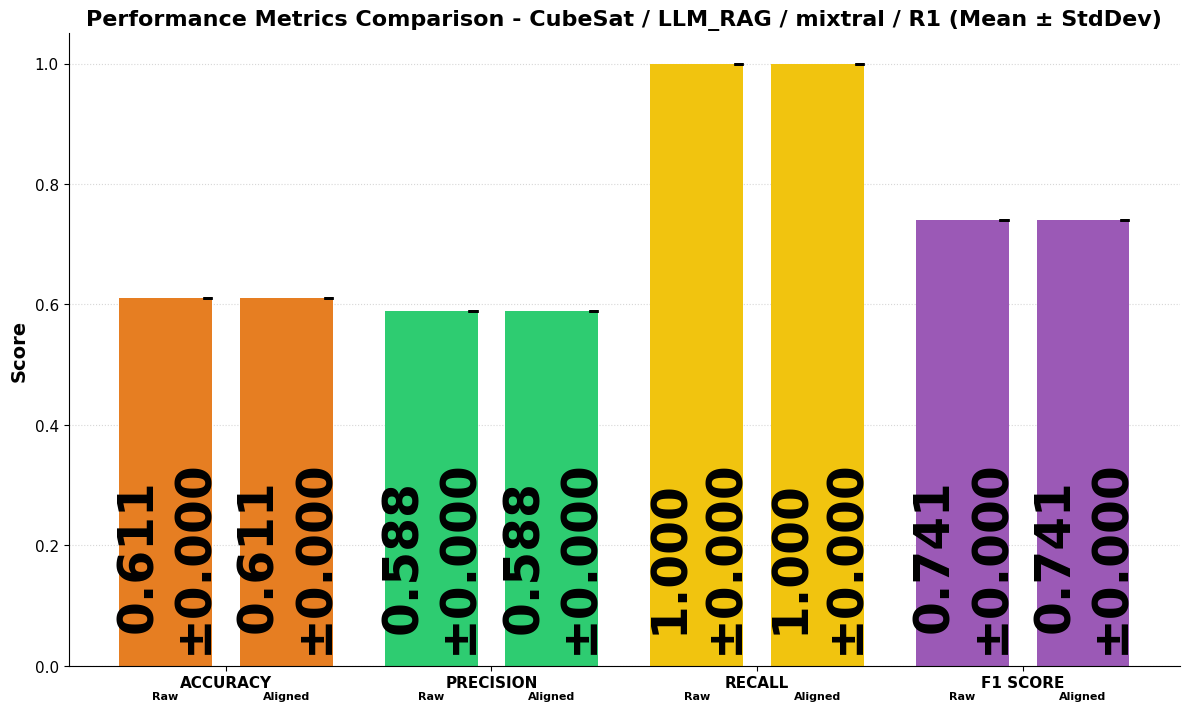

2025-04-12 23:22:29,574 - DSM_None_None_ - INFO - Plotting distance metrics...
2025-04-12 23:22:30,058 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1/plots/distance_metrics_with_stddev.png


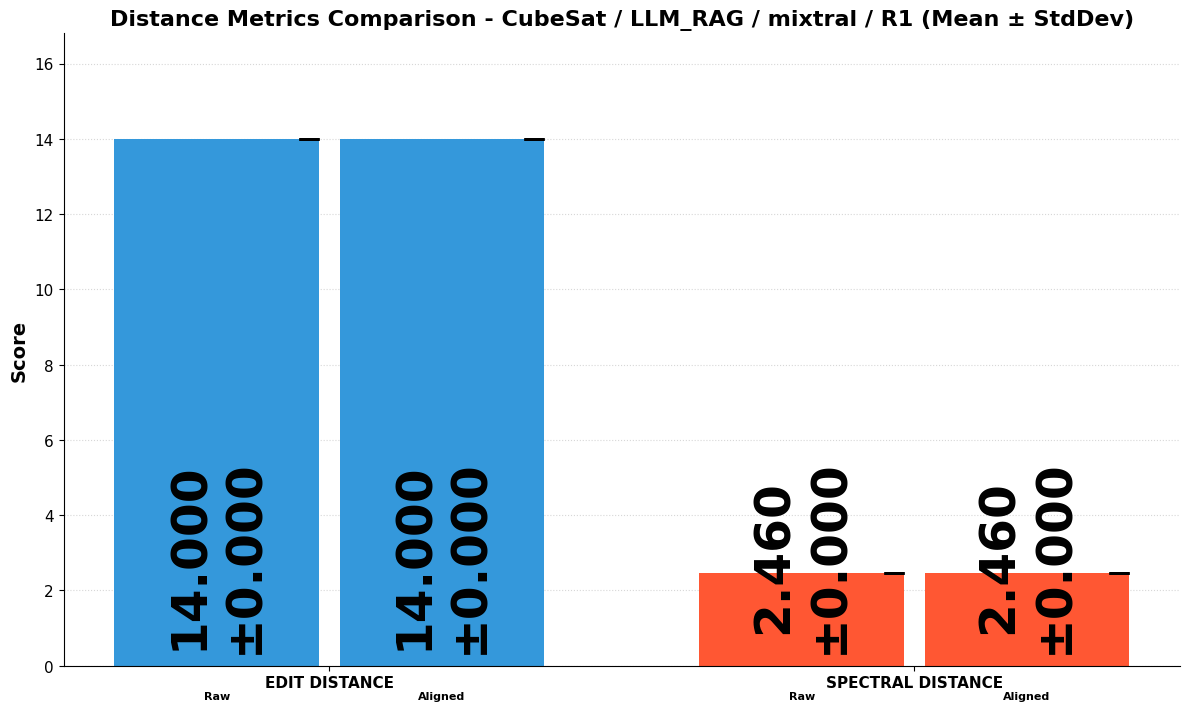

2025-04-12 23:22:30,174 - DSM_None_None_ - INFO - Plotting matrix comparison...
2025-04-12 23:22:32,641 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1/plots/matrices_comparison_avg.png


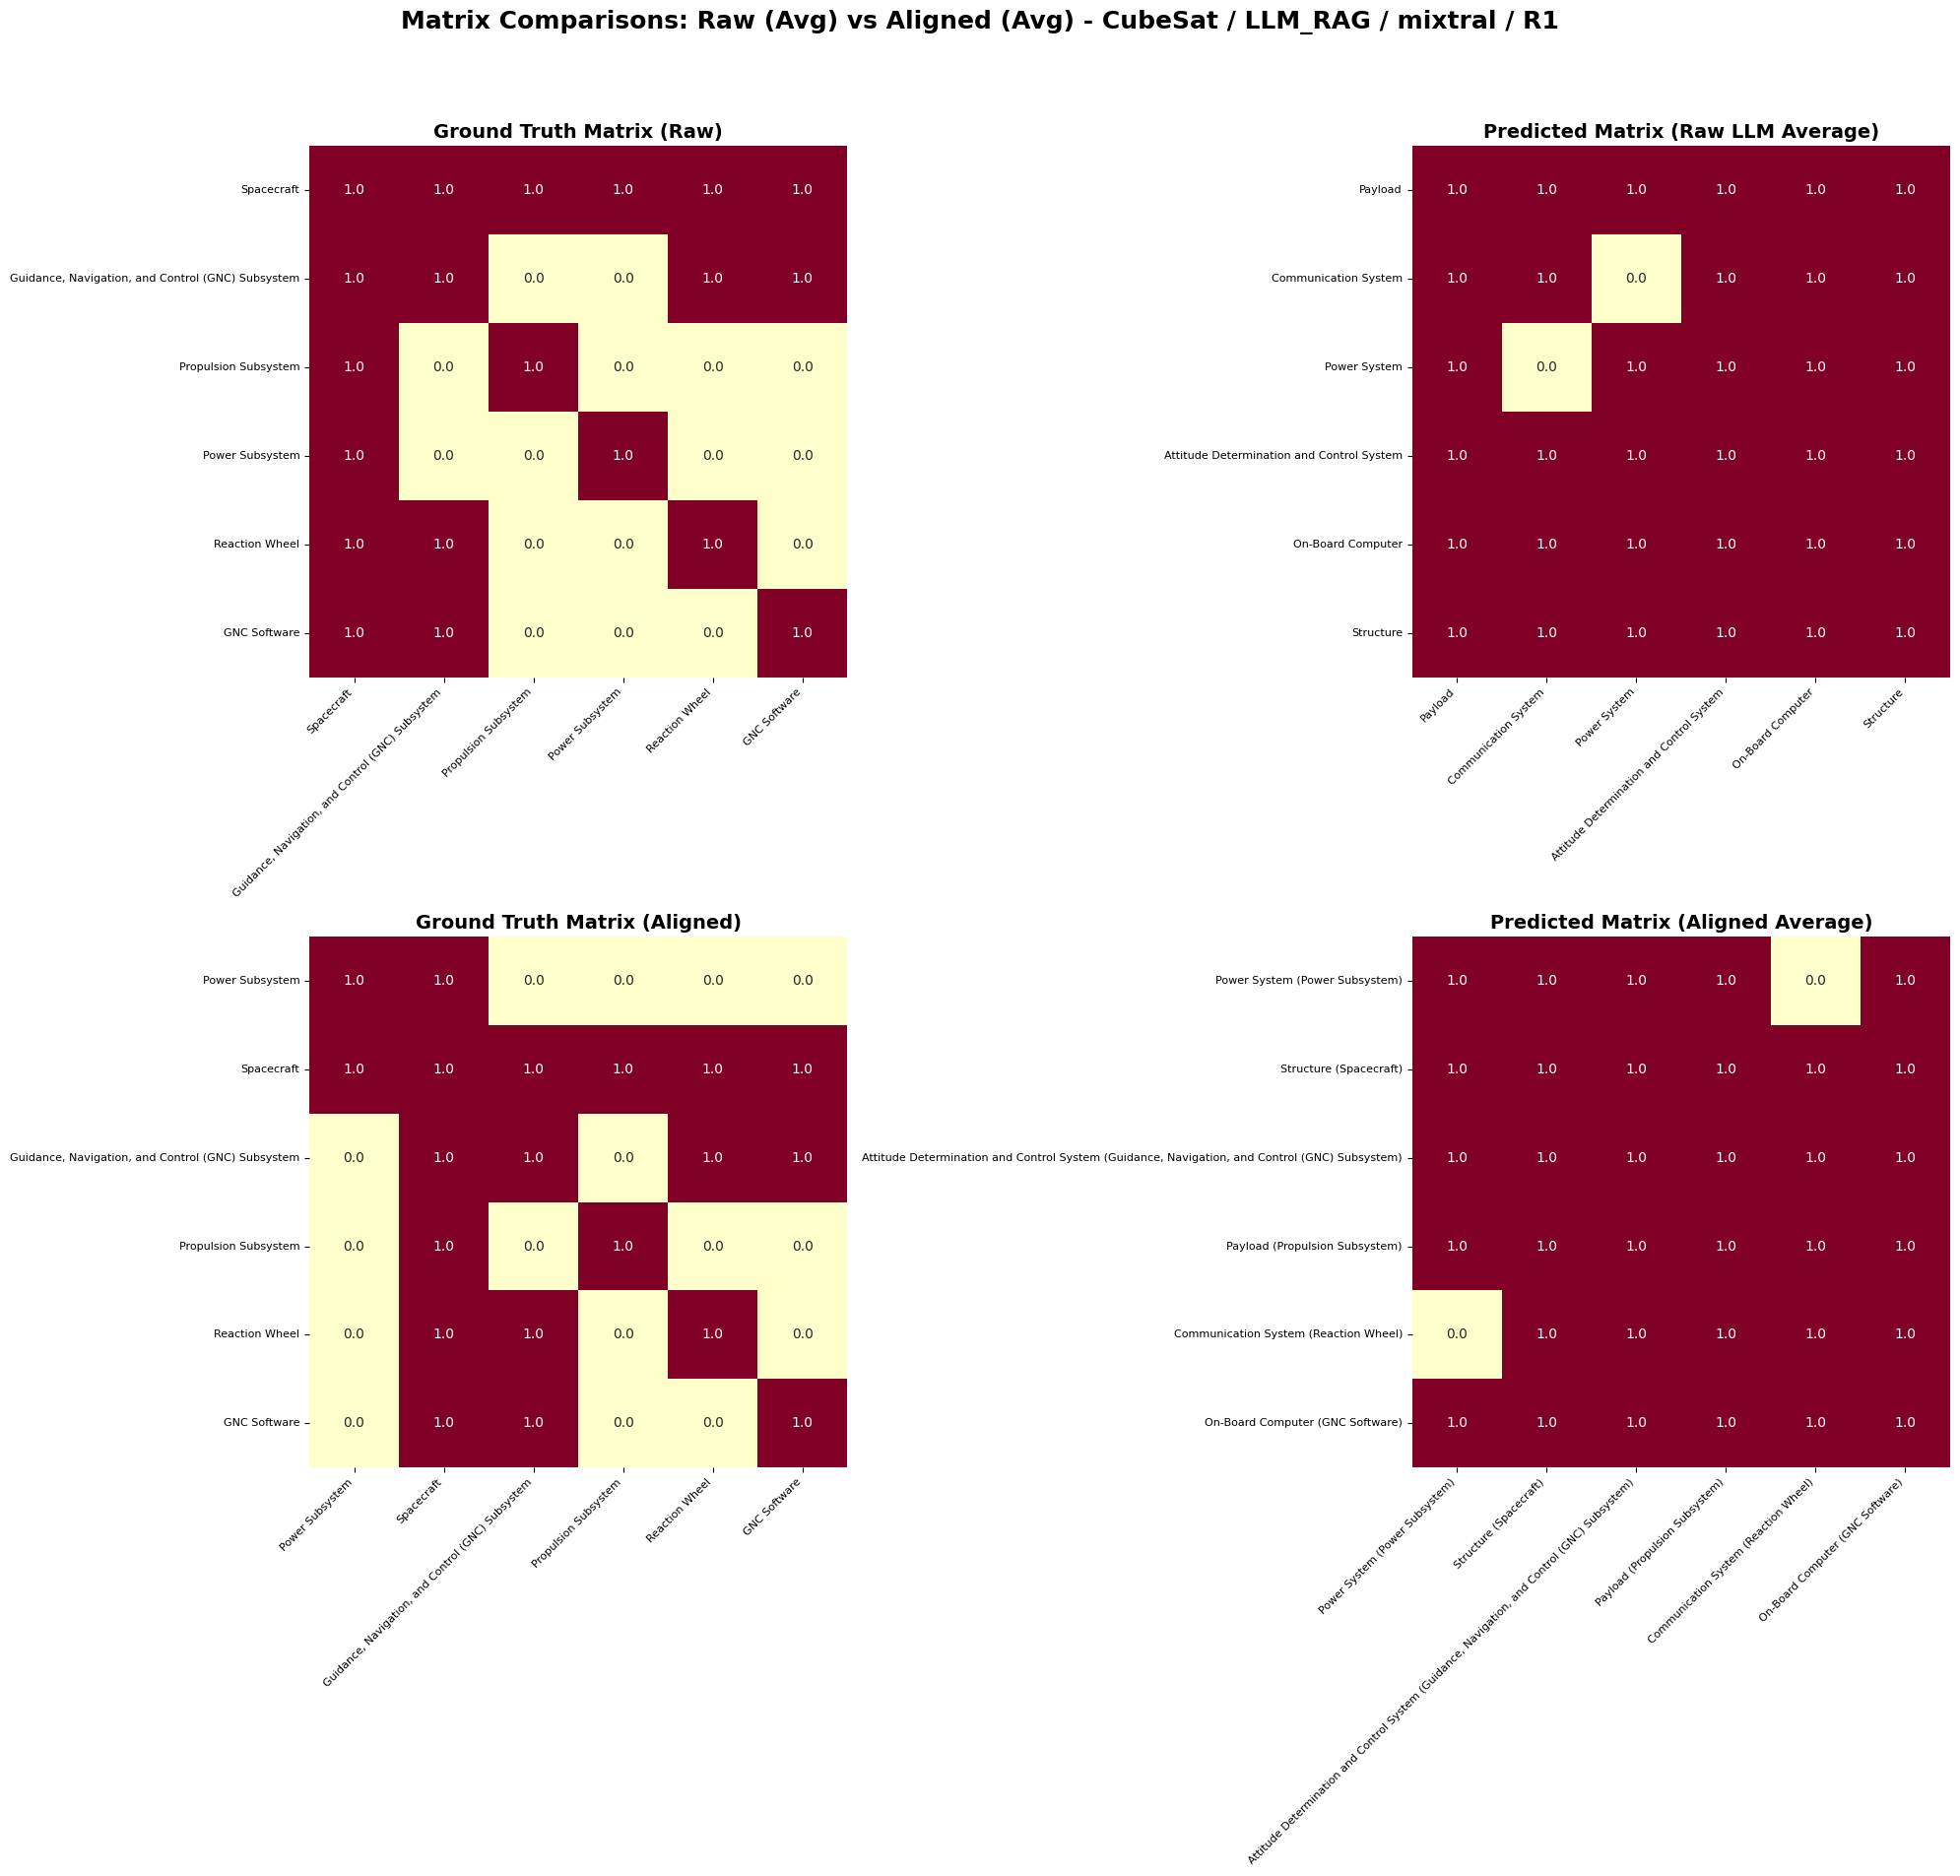

2025-04-12 23:22:33,083 - DSM_None_None_ - INFO - Plots generated and saved.
2025-04-12 23:22:33,084 - DSM_None_None_ - INFO - 
--- Results Summary for ollama:mixtral:8x22b-6k (R1) ---
2025-04-12 23:22:33,085 - DSM_None_None_ - INFO - 
Raw Metrics (Mean ± StdDev):
2025-04-12 23:22:33,086 - DSM_None_None_ - INFO -   accuracy: 0.6111 ± 0.0000
2025-04-12 23:22:33,086 - DSM_None_None_ - INFO -   precision: 0.5882 ± 0.0000
2025-04-12 23:22:33,087 - DSM_None_None_ - INFO -   recall: 1.0000 ± 0.0000
2025-04-12 23:22:33,088 - DSM_None_None_ - INFO -   f1_score: 0.7407 ± 0.0000
2025-04-12 23:22:33,088 - DSM_None_None_ - INFO -   edit_distance: 14.0000 ± 0.0000
2025-04-12 23:22:33,090 - DSM_None_None_ - INFO -   spectral_distance: 2.4599 ± 0.0000
2025-04-12 23:22:33,091 - DSM_None_None_ - INFO - 
Aligned Metrics (Mean ± StdDev):
2025-04-12 23:22:33,091 - DSM_None_None_ - INFO -   accuracy: 0.6111 ± 0.0000
2025-04-12 23:22:33,093 - DSM_None_None_ - INFO -   precision: 0.5882 ± 0.0000
2025-04-12 2

Logger closed for ollama:mixtral:8x22b-6k (R1).

---> [FIND_LATEST] Processing: CubeSat / ollama:mixtral:8x22b-6k / R2
---> [FIND_LATEST] CSV Path Template: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_{timestamp}/llm_rag_refs_R2/average_matrix_{timestamp}.csv
---> [FIND_LATEST] Searching Exp Dirs: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_*
---> [FIND_LATEST] Checking if parent directory exists: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG
---> [FIND_LATEST] Parent directory exists!
---> [FIND_LATEST] Found Exp Dirs (sorted): ['xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636']
---> [FIND_LATEST] Latest Exp Dir: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636
---> [FIND_LATEST] Ref Dir Path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mix

2025-04-12 23:22:54,850 - DSM_None_None_ - INFO - Running Analysis For:
2025-04-12 23:22:54,851 - DSM_None_None_ - INFO -   Product: CubeSat
2025-04-12 23:22:54,852 - DSM_None_None_ - INFO -   Model: ollama:mixtral:8x22b-6k
2025-04-12 23:22:54,853 - DSM_None_None_ - INFO -   Type: LLM_RAG
2025-04-12 23:22:54,854 - DSM_None_None_ - INFO -   Reference: R2
2025-04-12 23:22:54,855 - DSM_None_None_ - INFO -   Relationship: spatial proximity
2025-04-12 23:22:54,856 - DSM_None_None_ - INFO -   Ground Truth Path: xLM_DSM_wip/logs/Process/gt_cubesat.csv
2025-04-12 23:22:54,857 - DSM_None_None_ - INFO -   Avg Pred Path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R2/average_matrix_20250223-150636.csv
2025-04-12 23:22:54,858 - DSM_None_None_ - INFO -   Indiv JSON Path: Not Found
2025-04-12 23:22:54,864 - DSM_None_None_ - WARNING - Individual matrices JSON file not found/specified.
2025-04-12 23:22:54,865 - DSM_None_None_

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 36
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 36
Shape of y_true_filtered: (36,)
Shape of y_pred_filtered: (36,)
First 36 y_true_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0.
 1. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1.]
First 36 y_pred_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[4, 12], [0, 20]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (4, 12, 0, 20)
Manual Check - TP: 20, FP: 12, FN: 0, TN: 4
Calculated Accuracy: 0.6667  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.6250 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 1.0000    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.7692  [Formula: 2

2025-04-12 23:22:56,169 - DSM_None_None_ - INFO - Attempting Component Mapping based on Average Matrix...
2025-04-12 23:22:56,170 - DSM_None_None_ - INFO - Starting get_best_component_matches function
2025-04-12 23:22:56,171 - DSM_None_None_ - INFO - Extracting model from path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R2/average_matrix_20250223-150636.csv
2025-04-12 23:22:56,171 - DSM_None_None_ - INFO - Extracted model: mixtral:8x22b-6k
2025-04-12 23:22:56,179 - DSM_None_None_ - INFO - Automatic high-similarity match: Power Subsystem -> Power system (similarity: 0.778)
2025-04-12 23:22:56,191 - DSM_None_None_ - INFO - Prompt: 
You are an expert matching engine for cubesat systems. Your task is to determine the optimal one-to-one mapping between remaining ground truth and predicted major components.

Remaining Ground Truth Components:
['Spacecraft', 'Guidance, Navigation, and Control (GNC) Subsystem', 'Prop

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 9
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 9
Shape of y_true_filtered: (9,)
Shape of y_pred_filtered: (9,)
First 9 y_true_filtered: [1. 1. 0. 1. 1. 1. 0. 1. 1.]
First 9 y_pred_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[0, 2], [0, 7]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (0, 2, 0, 7)
Manual Check - TP: 7, FP: 2, FN: 0, TN: 0
Calculated Accuracy: 0.7778  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.7778 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 1.0000    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.8750  [Formula: 2*(Prec*Rec)/(Prec+Rec)]
--- End Debugging ---


2025-04-12 23:23:49,699 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R2/plots/performance_metrics_with_stddev.png


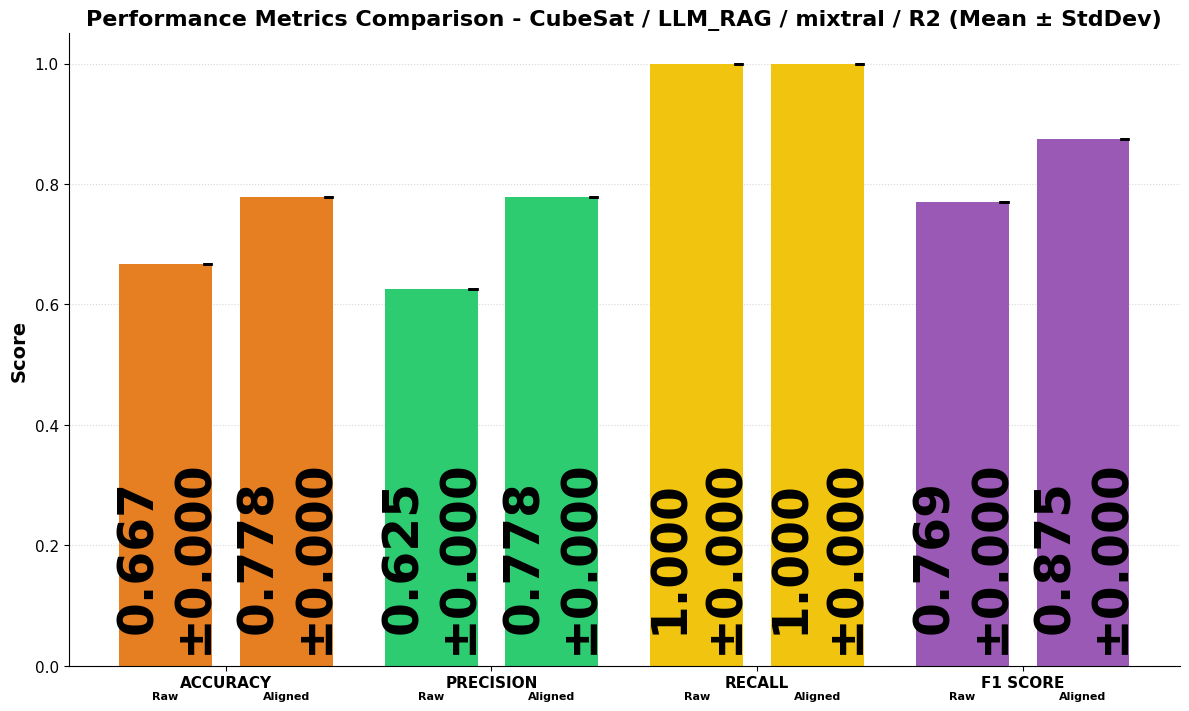

2025-04-12 23:23:49,817 - DSM_None_None_ - INFO - Plotting distance metrics...
2025-04-12 23:23:50,273 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R2/plots/distance_metrics_with_stddev.png


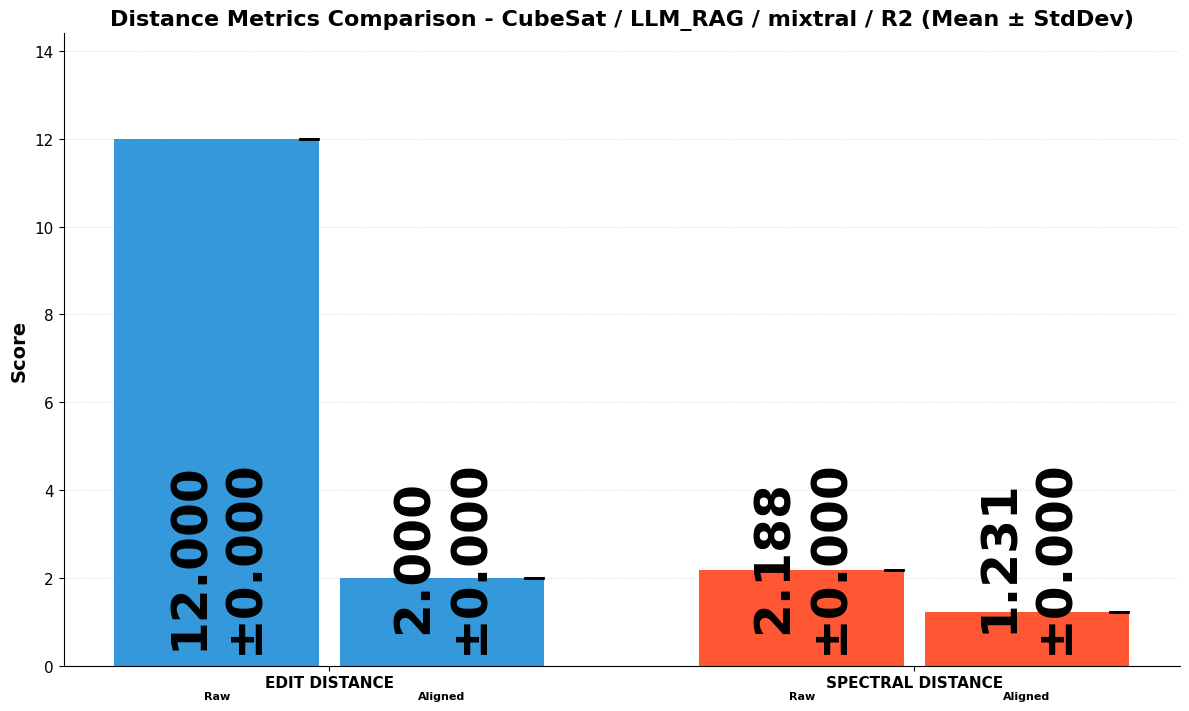

2025-04-12 23:23:50,386 - DSM_None_None_ - INFO - Plotting matrix comparison...
2025-04-12 23:23:52,518 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R2/plots/matrices_comparison_avg.png


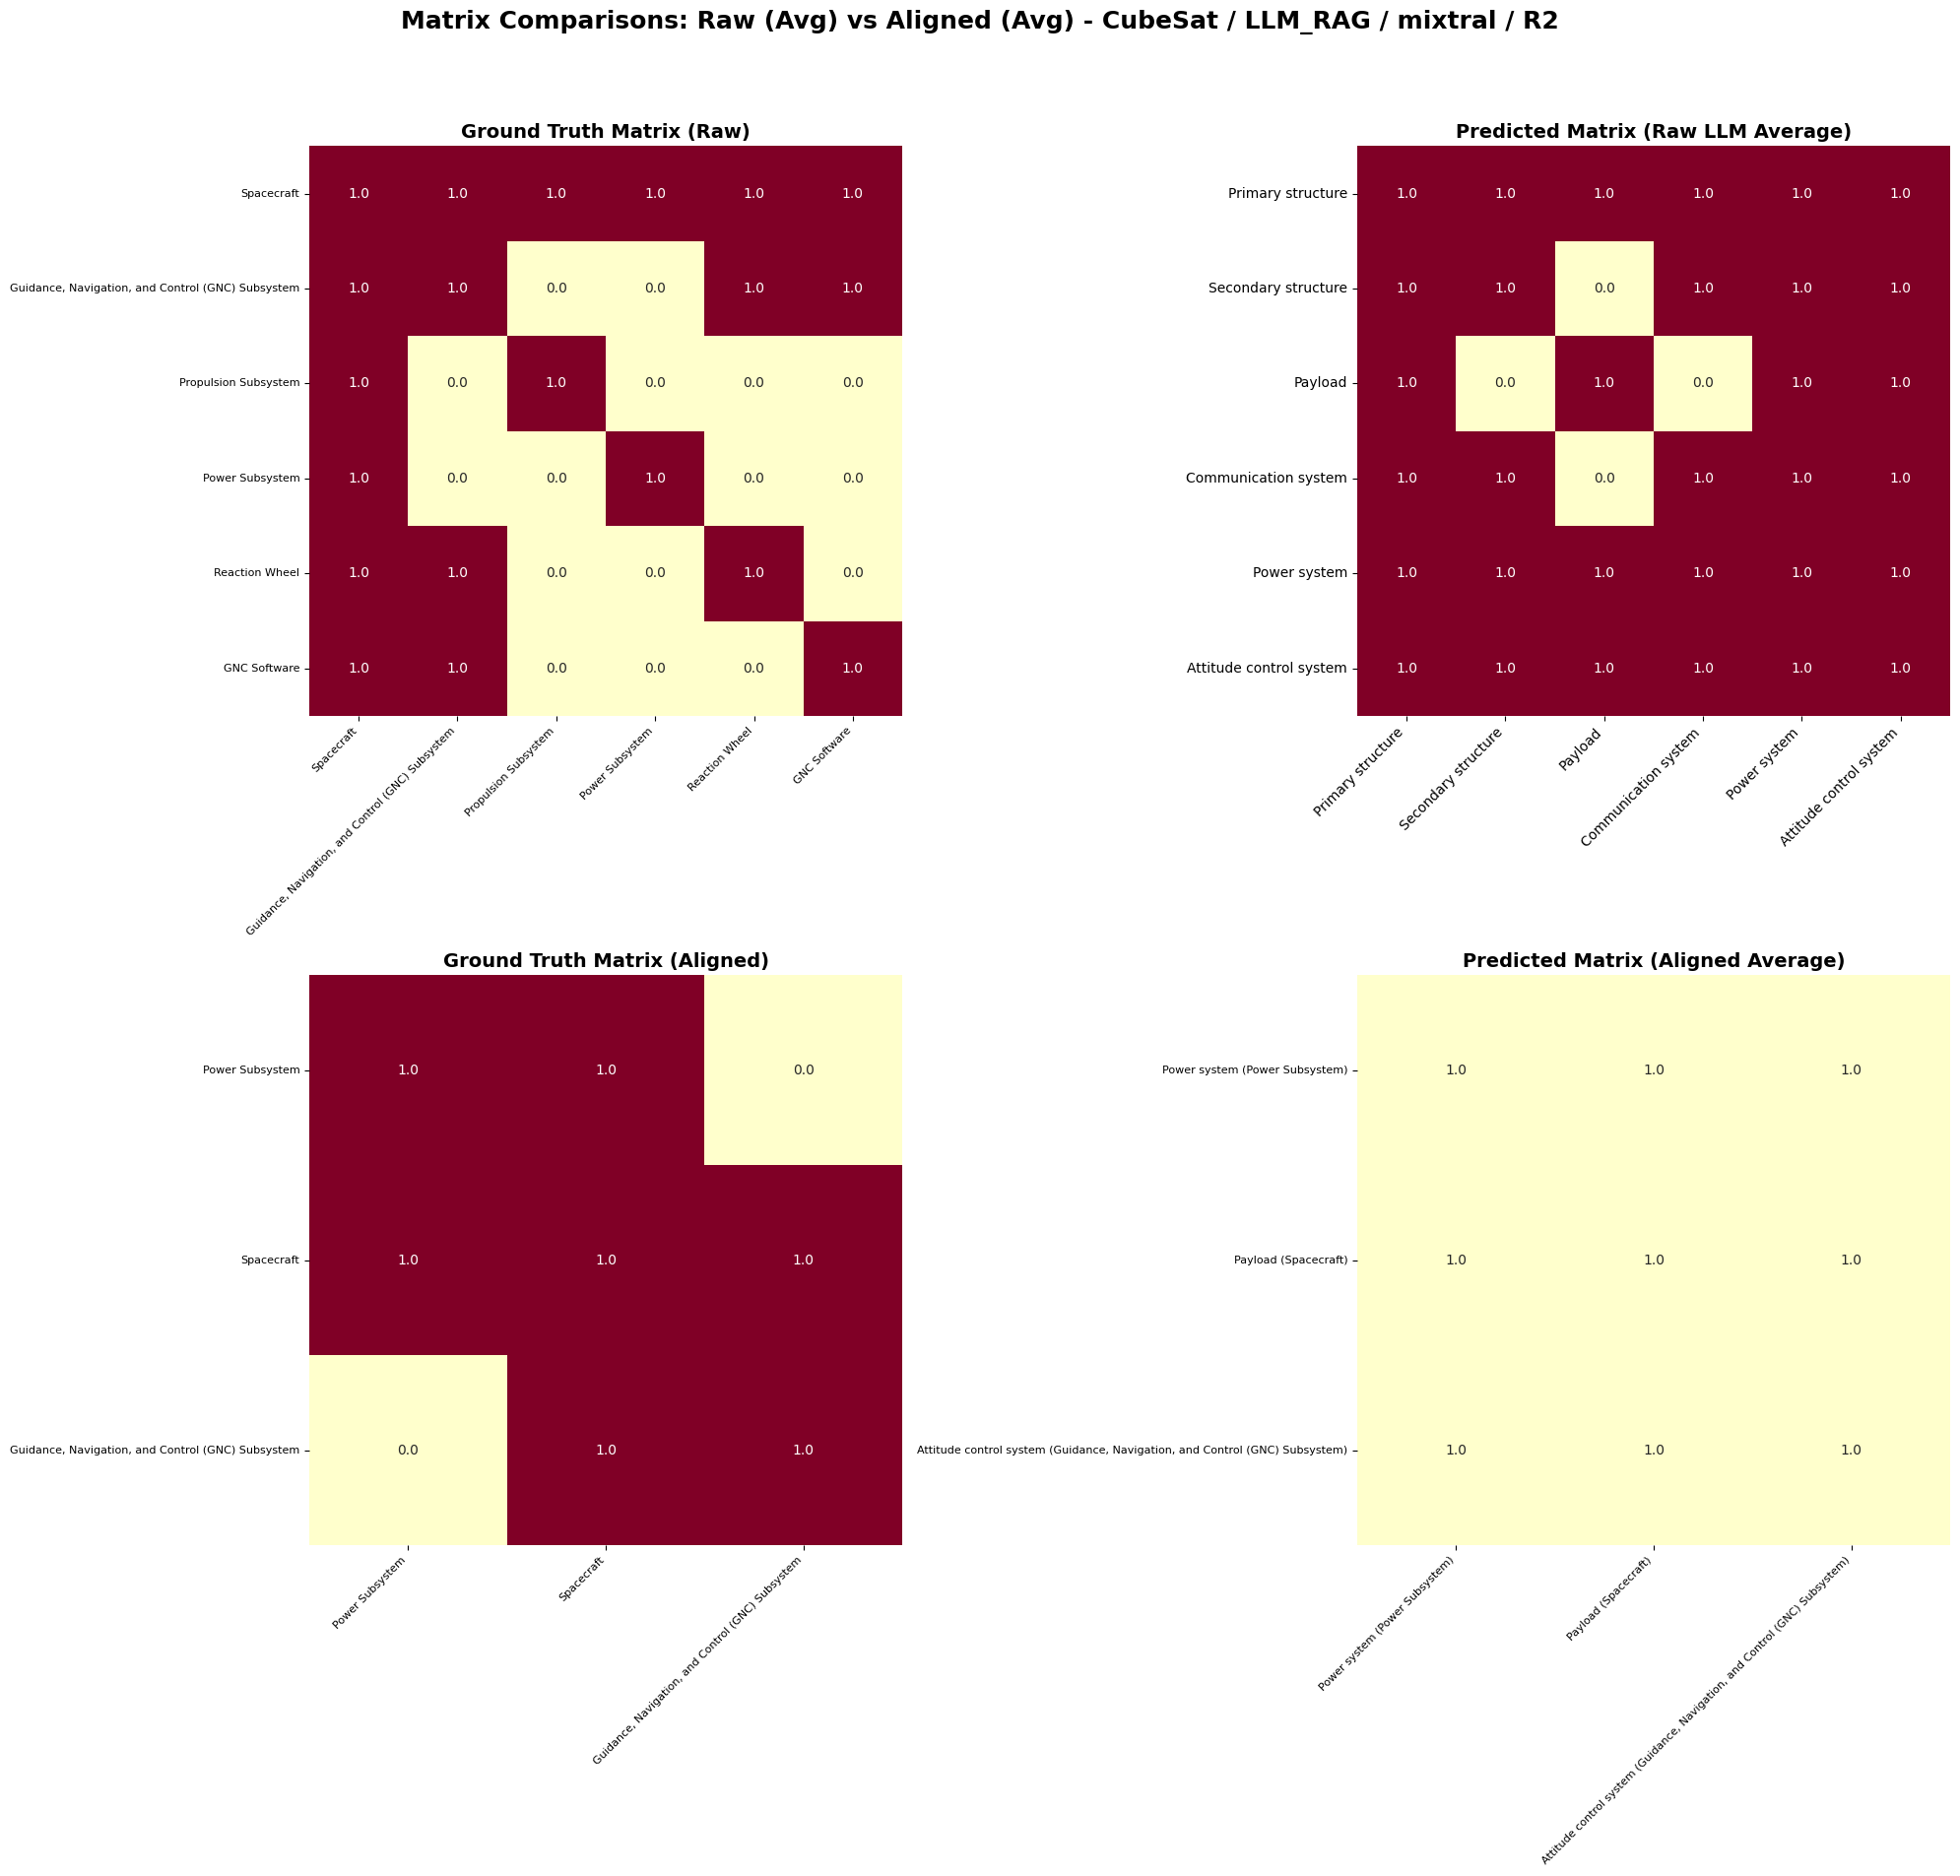

2025-04-12 23:23:52,894 - DSM_None_None_ - INFO - Plots generated and saved.
2025-04-12 23:23:52,895 - DSM_None_None_ - INFO - 
--- Results Summary for ollama:mixtral:8x22b-6k (R2) ---
2025-04-12 23:23:52,896 - DSM_None_None_ - INFO - 
Raw Metrics (Mean ± StdDev):
2025-04-12 23:23:52,897 - DSM_None_None_ - INFO -   accuracy: 0.6667 ± 0.0000
2025-04-12 23:23:52,898 - DSM_None_None_ - INFO -   precision: 0.6250 ± 0.0000
2025-04-12 23:23:52,898 - DSM_None_None_ - INFO -   recall: 1.0000 ± 0.0000
2025-04-12 23:23:52,899 - DSM_None_None_ - INFO -   f1_score: 0.7692 ± 0.0000
2025-04-12 23:23:52,899 - DSM_None_None_ - INFO -   edit_distance: 12.0000 ± 0.0000
2025-04-12 23:23:52,900 - DSM_None_None_ - INFO -   spectral_distance: 2.1876 ± 0.0000
2025-04-12 23:23:52,901 - DSM_None_None_ - INFO - 
Aligned Metrics (Mean ± StdDev):
2025-04-12 23:23:52,901 - DSM_None_None_ - INFO -   accuracy: 0.7778 ± 0.0000
2025-04-12 23:23:52,902 - DSM_None_None_ - INFO -   precision: 0.7778 ± 0.0000
2025-04-12 2

Logger closed for ollama:mixtral:8x22b-6k (R2).

---> [FIND_LATEST] Processing: CubeSat / ollama:mixtral:8x22b-6k / R3
---> [FIND_LATEST] CSV Path Template: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_{timestamp}/llm_rag_refs_R3/average_matrix_{timestamp}.csv
---> [FIND_LATEST] Searching Exp Dirs: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_*
---> [FIND_LATEST] Checking if parent directory exists: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG
---> [FIND_LATEST] Parent directory exists!
---> [FIND_LATEST] Found Exp Dirs (sorted): ['xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636']
---> [FIND_LATEST] Latest Exp Dir: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636
---> [FIND_LATEST] Ref Dir Path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mix

2025-04-12 23:24:14,637 - DSM_None_None_ - INFO - Running Analysis For:
2025-04-12 23:24:14,638 - DSM_None_None_ - INFO -   Product: CubeSat
2025-04-12 23:24:14,639 - DSM_None_None_ - INFO -   Model: ollama:mixtral:8x22b-6k
2025-04-12 23:24:14,640 - DSM_None_None_ - INFO -   Type: LLM_RAG
2025-04-12 23:24:14,641 - DSM_None_None_ - INFO -   Reference: R3
2025-04-12 23:24:14,642 - DSM_None_None_ - INFO -   Relationship: spatial proximity
2025-04-12 23:24:14,642 - DSM_None_None_ - INFO -   Ground Truth Path: xLM_DSM_wip/logs/Process/gt_cubesat.csv
2025-04-12 23:24:14,644 - DSM_None_None_ - INFO -   Avg Pred Path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R3/average_matrix_20250223-150636.csv
2025-04-12 23:24:14,645 - DSM_None_None_ - INFO -   Indiv JSON Path: Not Found
2025-04-12 23:24:14,651 - DSM_None_None_ - WARNING - Individual matrices JSON file not found/specified.
2025-04-12 23:24:14,652 - DSM_None_None_

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 36
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 36
Shape of y_true_filtered: (36,)
Shape of y_pred_filtered: (36,)
First 36 y_true_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0.
 1. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1.]
First 36 y_pred_filtered: [1. 1. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0.
 0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[6, 10], [10, 10]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (6, 10, 10, 10)
Manual Check - TP: 10, FP: 10, FN: 10, TN: 6
Calculated Accuracy: 0.4444  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.5000 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.5000    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.5000  [Formula

2025-04-12 23:24:15,278 - DSM_None_None_ - INFO - Attempting Component Mapping based on Average Matrix...
2025-04-12 23:24:15,279 - DSM_None_None_ - INFO - Starting get_best_component_matches function
2025-04-12 23:24:15,280 - DSM_None_None_ - INFO - Extracting model from path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R3/average_matrix_20250223-150636.csv
2025-04-12 23:24:15,281 - DSM_None_None_ - INFO - Extracted model: mixtral:8x22b-6k
2025-04-12 23:24:15,304 - DSM_None_None_ - INFO - Prompt: 
You are an expert matching engine for cubesat systems. Your task is to determine the optimal one-to-one mapping between remaining ground truth and predicted major components.

Remaining Ground Truth Components:
['Spacecraft', 'Guidance, Navigation, and Control (GNC) Subsystem', 'Propulsion Subsystem', 'Power Subsystem', 'Reaction Wheel', 'GNC Software']

Remaining Predicted Components:
['Satellite housing', 'Arduino

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 1
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 1
Shape of y_true_filtered: (1,)
Shape of y_pred_filtered: (1,)
First 1 y_true_filtered: [1.]
First 1 y_pred_filtered: [1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[0, 0], [0, 1]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (0, 0, 0, 1)
Manual Check - TP: 1, FP: 0, FN: 0, TN: 0
Calculated Accuracy: 1.0000  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 1.0000 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 1.0000    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 1.0000  [Formula: 2*(Prec*Rec)/(Prec+Rec)]
--- End Debugging ---


2025-04-12 23:25:07,785 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R3/plots/performance_metrics_with_stddev.png


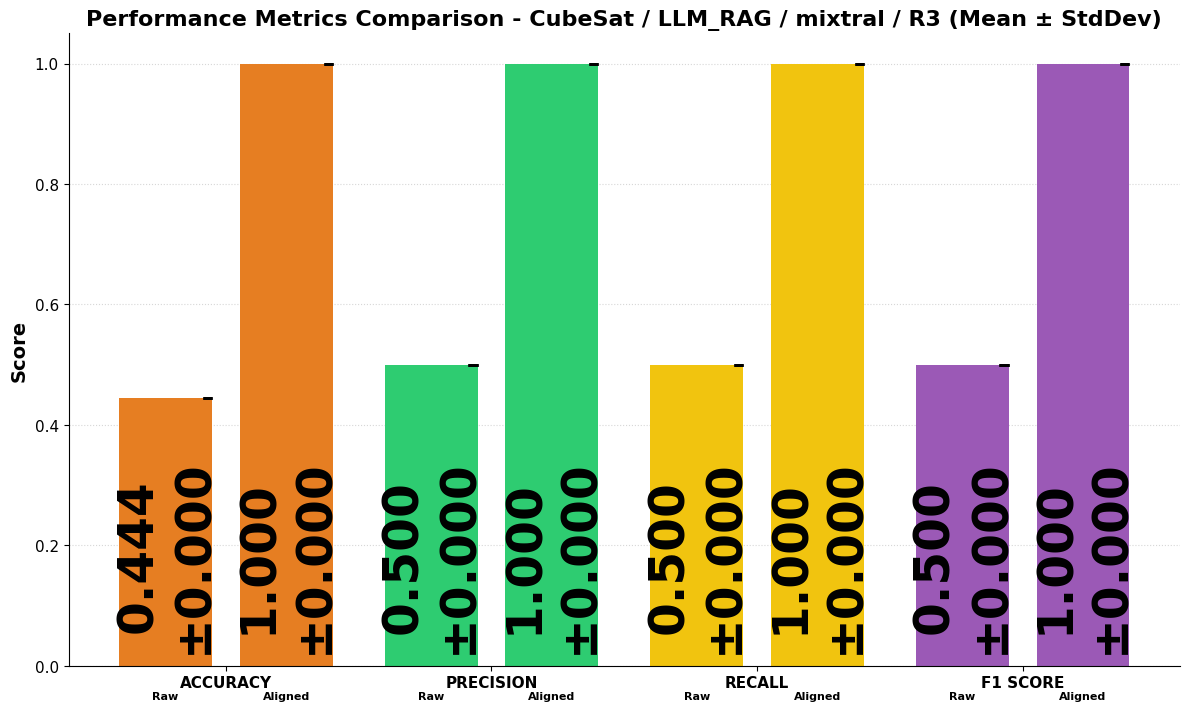

2025-04-12 23:25:07,904 - DSM_None_None_ - INFO - Plotting distance metrics...
2025-04-12 23:25:08,344 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R3/plots/distance_metrics_with_stddev.png


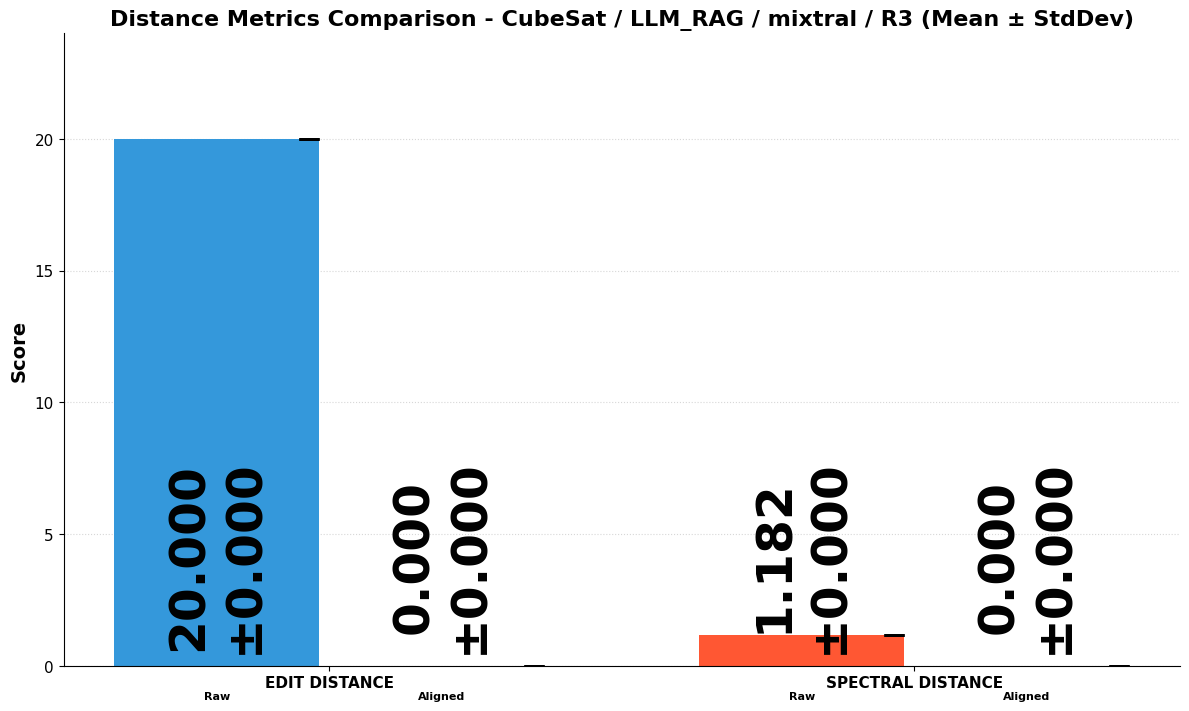

2025-04-12 23:25:08,450 - DSM_None_None_ - INFO - Plotting matrix comparison...
2025-04-12 23:25:10,453 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R3/plots/matrices_comparison_avg.png


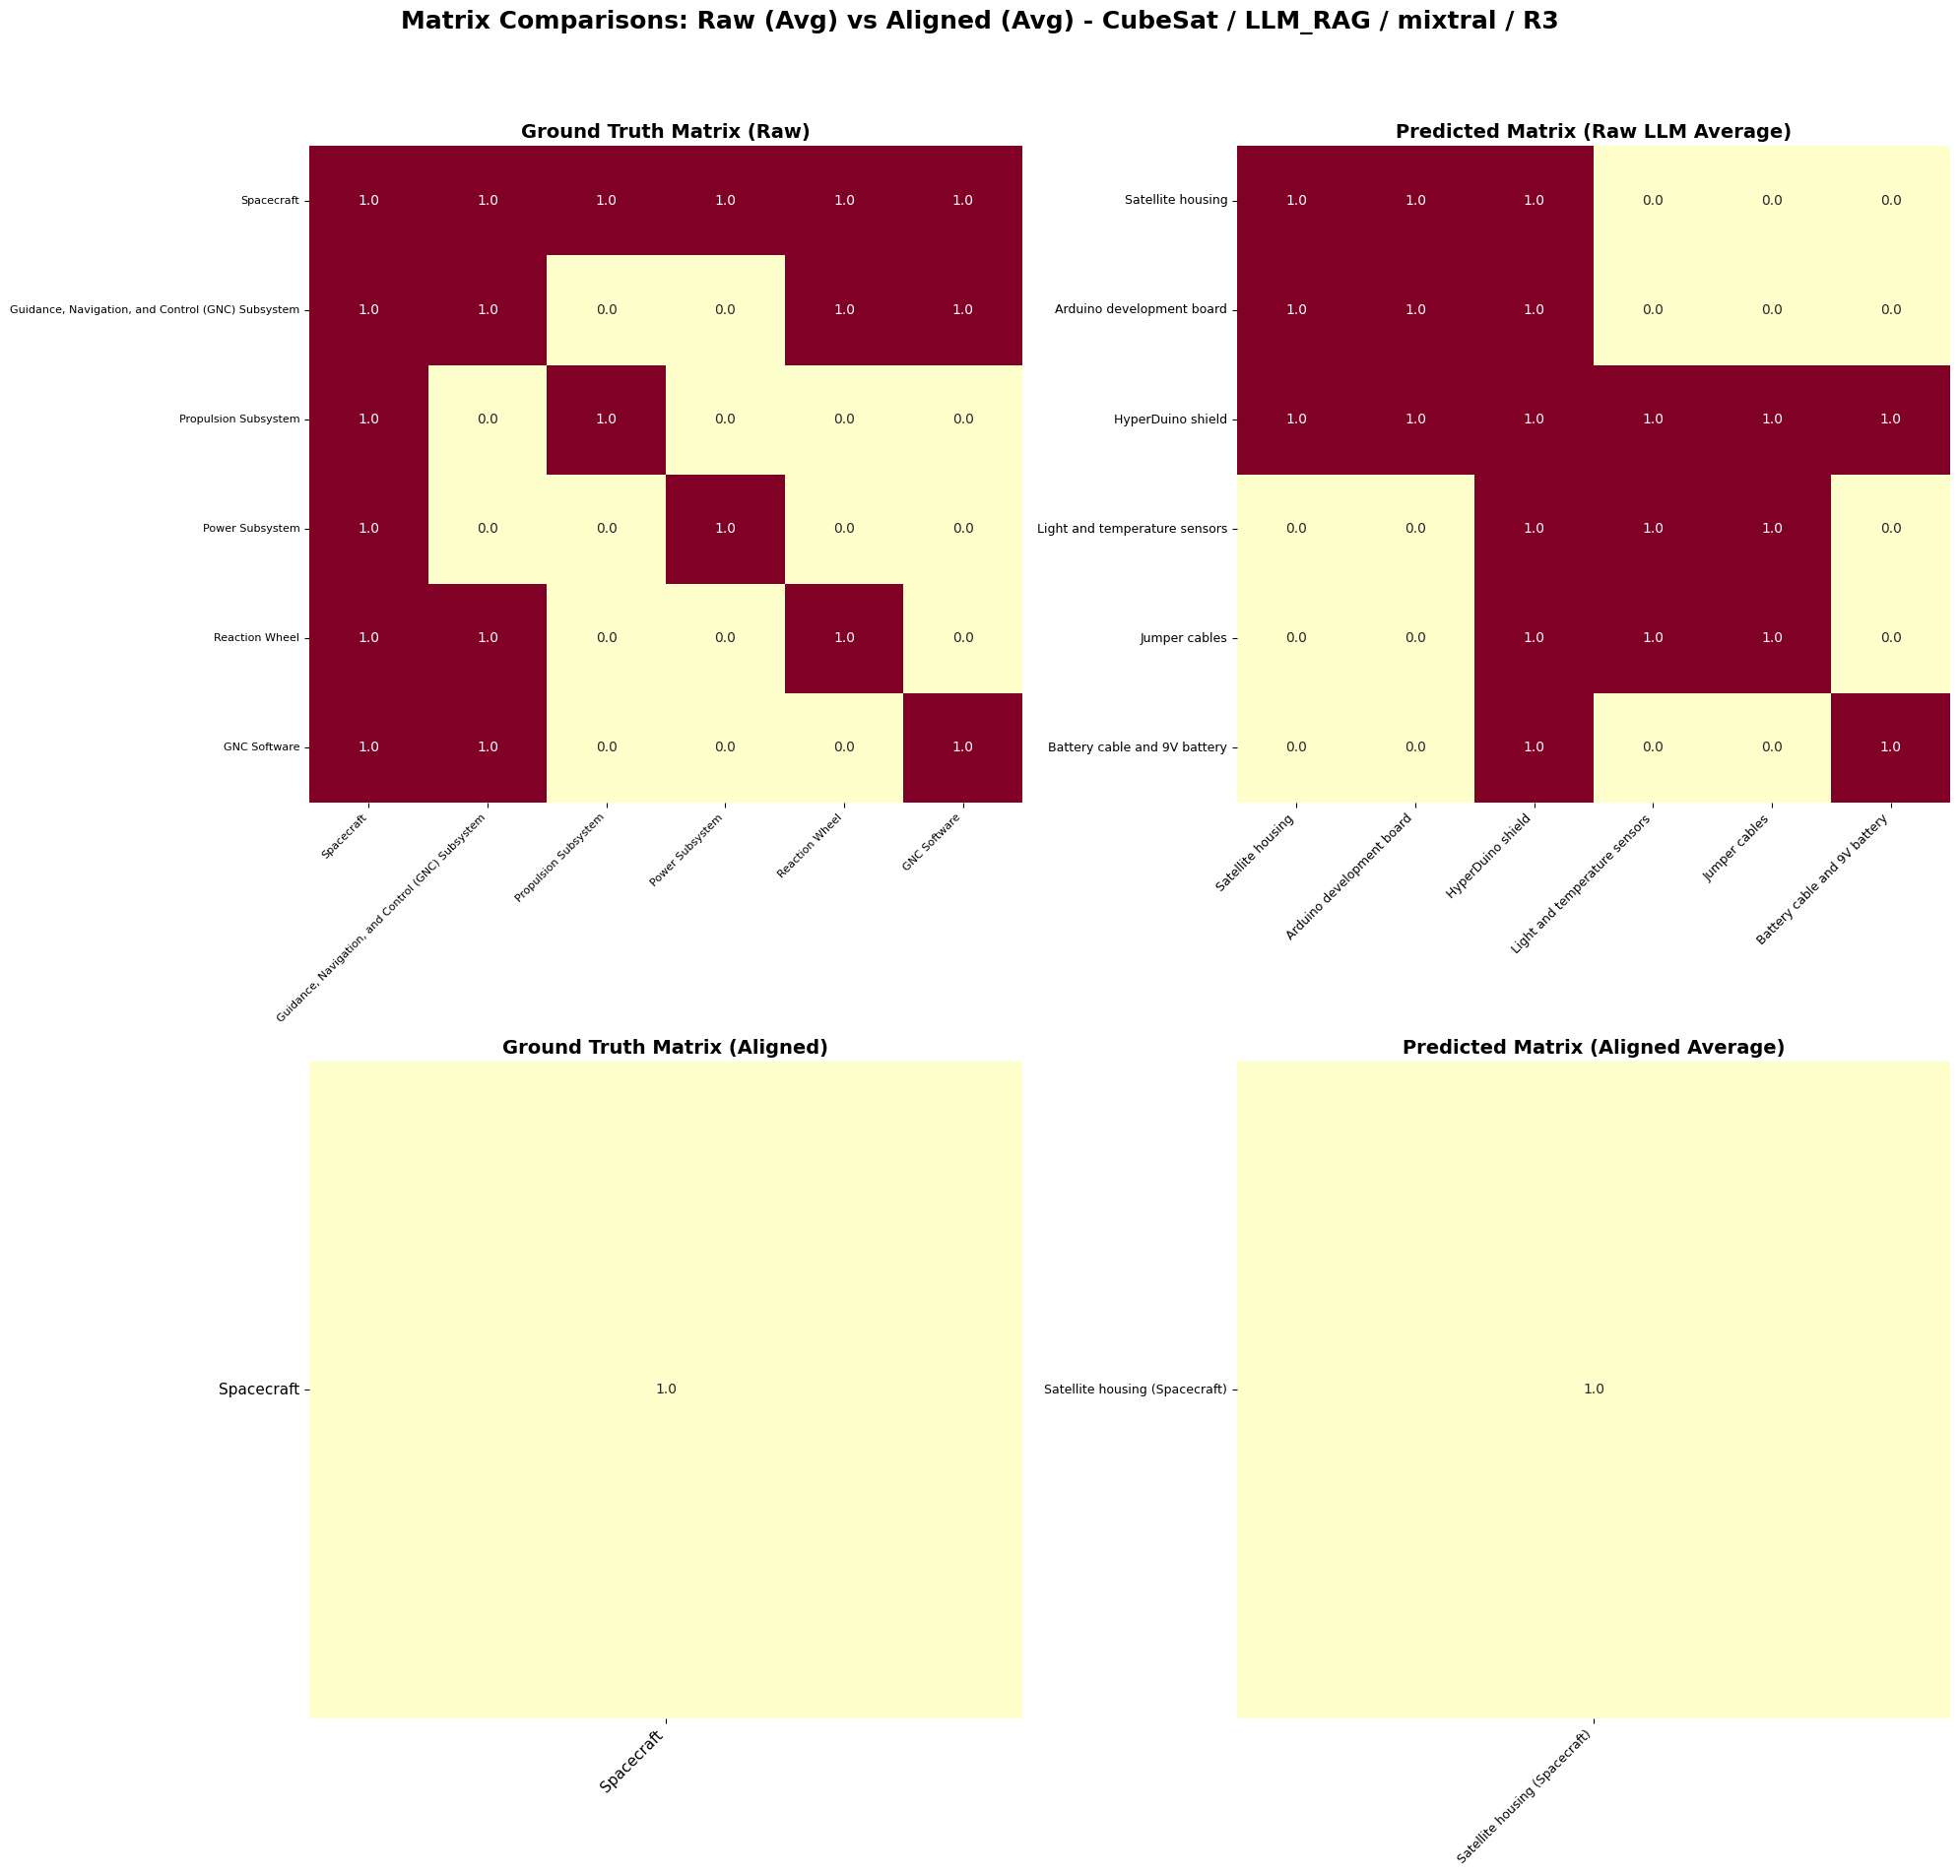

2025-04-12 23:25:10,788 - DSM_None_None_ - INFO - Plots generated and saved.
2025-04-12 23:25:10,789 - DSM_None_None_ - INFO - 
--- Results Summary for ollama:mixtral:8x22b-6k (R3) ---
2025-04-12 23:25:10,790 - DSM_None_None_ - INFO - 
Raw Metrics (Mean ± StdDev):
2025-04-12 23:25:10,790 - DSM_None_None_ - INFO -   accuracy: 0.4444 ± 0.0000
2025-04-12 23:25:10,791 - DSM_None_None_ - INFO -   precision: 0.5000 ± 0.0000
2025-04-12 23:25:10,791 - DSM_None_None_ - INFO -   recall: 0.5000 ± 0.0000
2025-04-12 23:25:10,792 - DSM_None_None_ - INFO -   f1_score: 0.5000 ± 0.0000
2025-04-12 23:25:10,794 - DSM_None_None_ - INFO -   edit_distance: 20.0000 ± 0.0000
2025-04-12 23:25:10,795 - DSM_None_None_ - INFO -   spectral_distance: 1.1819 ± 0.0000
2025-04-12 23:25:10,796 - DSM_None_None_ - INFO - 
Aligned Metrics (Mean ± StdDev):
2025-04-12 23:25:10,797 - DSM_None_None_ - INFO -   accuracy: 1.0000 ± 0.0000
2025-04-12 23:25:10,797 - DSM_None_None_ - INFO -   precision: 1.0000 ± 0.0000
2025-04-12 2

Logger closed for ollama:mixtral:8x22b-6k (R3).

---> [FIND_LATEST] Processing: CubeSat / ollama:mixtral:8x22b-6k / R1_R2
---> [FIND_LATEST] CSV Path Template: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_{timestamp}/llm_rag_refs_R1_R2/average_matrix_{timestamp}.csv
---> [FIND_LATEST] Searching Exp Dirs: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_*
---> [FIND_LATEST] Checking if parent directory exists: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG
---> [FIND_LATEST] Parent directory exists!
---> [FIND_LATEST] Found Exp Dirs (sorted): ['xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636']
---> [FIND_LATEST] Latest Exp Dir: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636
---> [FIND_LATEST] Ref Dir Path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_olla

2025-04-12 23:25:32,520 - DSM_None_None_ - INFO - Running Analysis For:
2025-04-12 23:25:32,521 - DSM_None_None_ - INFO -   Product: CubeSat
2025-04-12 23:25:32,522 - DSM_None_None_ - INFO -   Model: ollama:mixtral:8x22b-6k
2025-04-12 23:25:32,523 - DSM_None_None_ - INFO -   Type: LLM_RAG
2025-04-12 23:25:32,524 - DSM_None_None_ - INFO -   Reference: R1_R2
2025-04-12 23:25:32,525 - DSM_None_None_ - INFO -   Relationship: spatial proximity
2025-04-12 23:25:32,526 - DSM_None_None_ - INFO -   Ground Truth Path: xLM_DSM_wip/logs/Process/gt_cubesat.csv
2025-04-12 23:25:32,527 - DSM_None_None_ - INFO -   Avg Pred Path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1_R2/average_matrix_20250223-150636.csv
2025-04-12 23:25:32,528 - DSM_None_None_ - INFO -   Indiv JSON Path: Not Found
2025-04-12 23:25:32,534 - DSM_None_None_ - WARNING - Individual matrices JSON file not found/specified.
2025-04-12 23:25:32,534 - DSM_None

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 36
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 36
Shape of y_true_filtered: (36,)
Shape of y_pred_filtered: (36,)
First 36 y_true_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0.
 1. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1.]
First 36 y_pred_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[4, 12], [0, 20]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (4, 12, 0, 20)
Manual Check - TP: 20, FP: 12, FN: 0, TN: 4
Calculated Accuracy: 0.6667  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.6250 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 1.0000    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.7692  [Formula: 2

2025-04-12 23:25:33,789 - DSM_None_None_ - INFO - Attempting Component Mapping based on Average Matrix...
2025-04-12 23:25:33,790 - DSM_None_None_ - INFO - Starting get_best_component_matches function
2025-04-12 23:25:33,791 - DSM_None_None_ - INFO - Extracting model from path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1_R2/average_matrix_20250223-150636.csv
2025-04-12 23:25:33,791 - DSM_None_None_ - INFO - Extracted model: mixtral:8x22b-6k
2025-04-12 23:25:33,800 - DSM_None_None_ - INFO - Automatic high-similarity match: Power Subsystem -> Power system (similarity: 0.778)
2025-04-12 23:25:33,812 - DSM_None_None_ - INFO - Prompt: 
You are an expert matching engine for cubesat systems. Your task is to determine the optimal one-to-one mapping between remaining ground truth and predicted major components.

Remaining Ground Truth Components:
['Spacecraft', 'Guidance, Navigation, and Control (GNC) Subsystem', 'P

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 16
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 16
Shape of y_true_filtered: (16,)
Shape of y_pred_filtered: (16,)
First 16 y_true_filtered: [1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1.]
First 16 y_pred_filtered: [1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[0, 4], [2, 10]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (0, 4, 2, 10)
Manual Check - TP: 10, FP: 4, FN: 2, TN: 0
Calculated Accuracy: 0.6250  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.7143 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.8333    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.7692  [Formula: 2*(Prec*Rec)/(Prec+Rec)]
--- End Debugging ---


2025-04-12 23:26:35,158 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1_R2/plots/performance_metrics_with_stddev.png


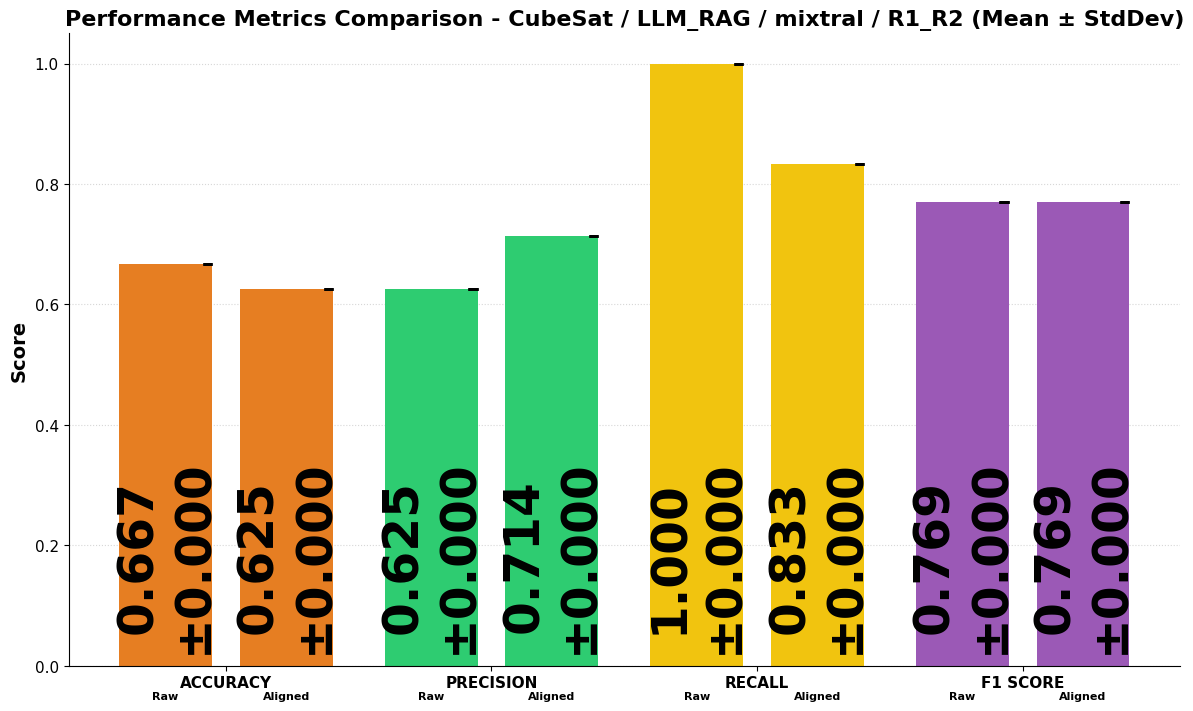

2025-04-12 23:26:35,278 - DSM_None_None_ - INFO - Plotting distance metrics...
2025-04-12 23:26:35,749 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1_R2/plots/distance_metrics_with_stddev.png


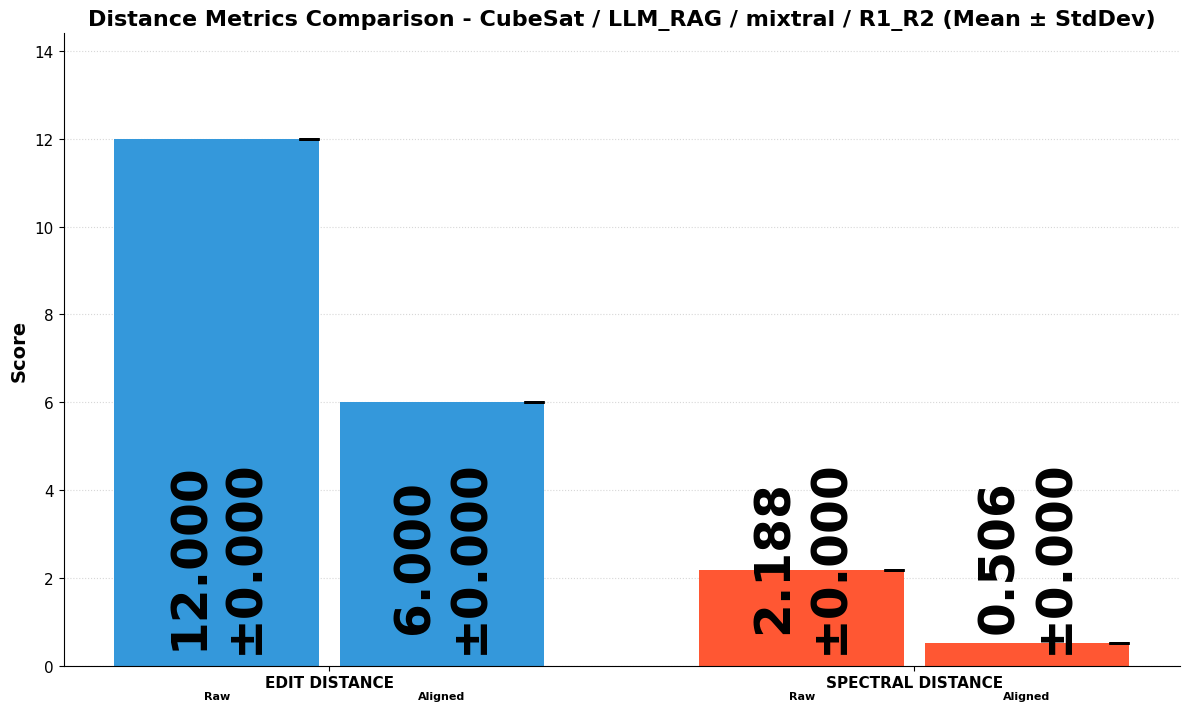

2025-04-12 23:26:35,852 - DSM_None_None_ - INFO - Plotting matrix comparison...
2025-04-12 23:26:38,017 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1_R2/plots/matrices_comparison_avg.png


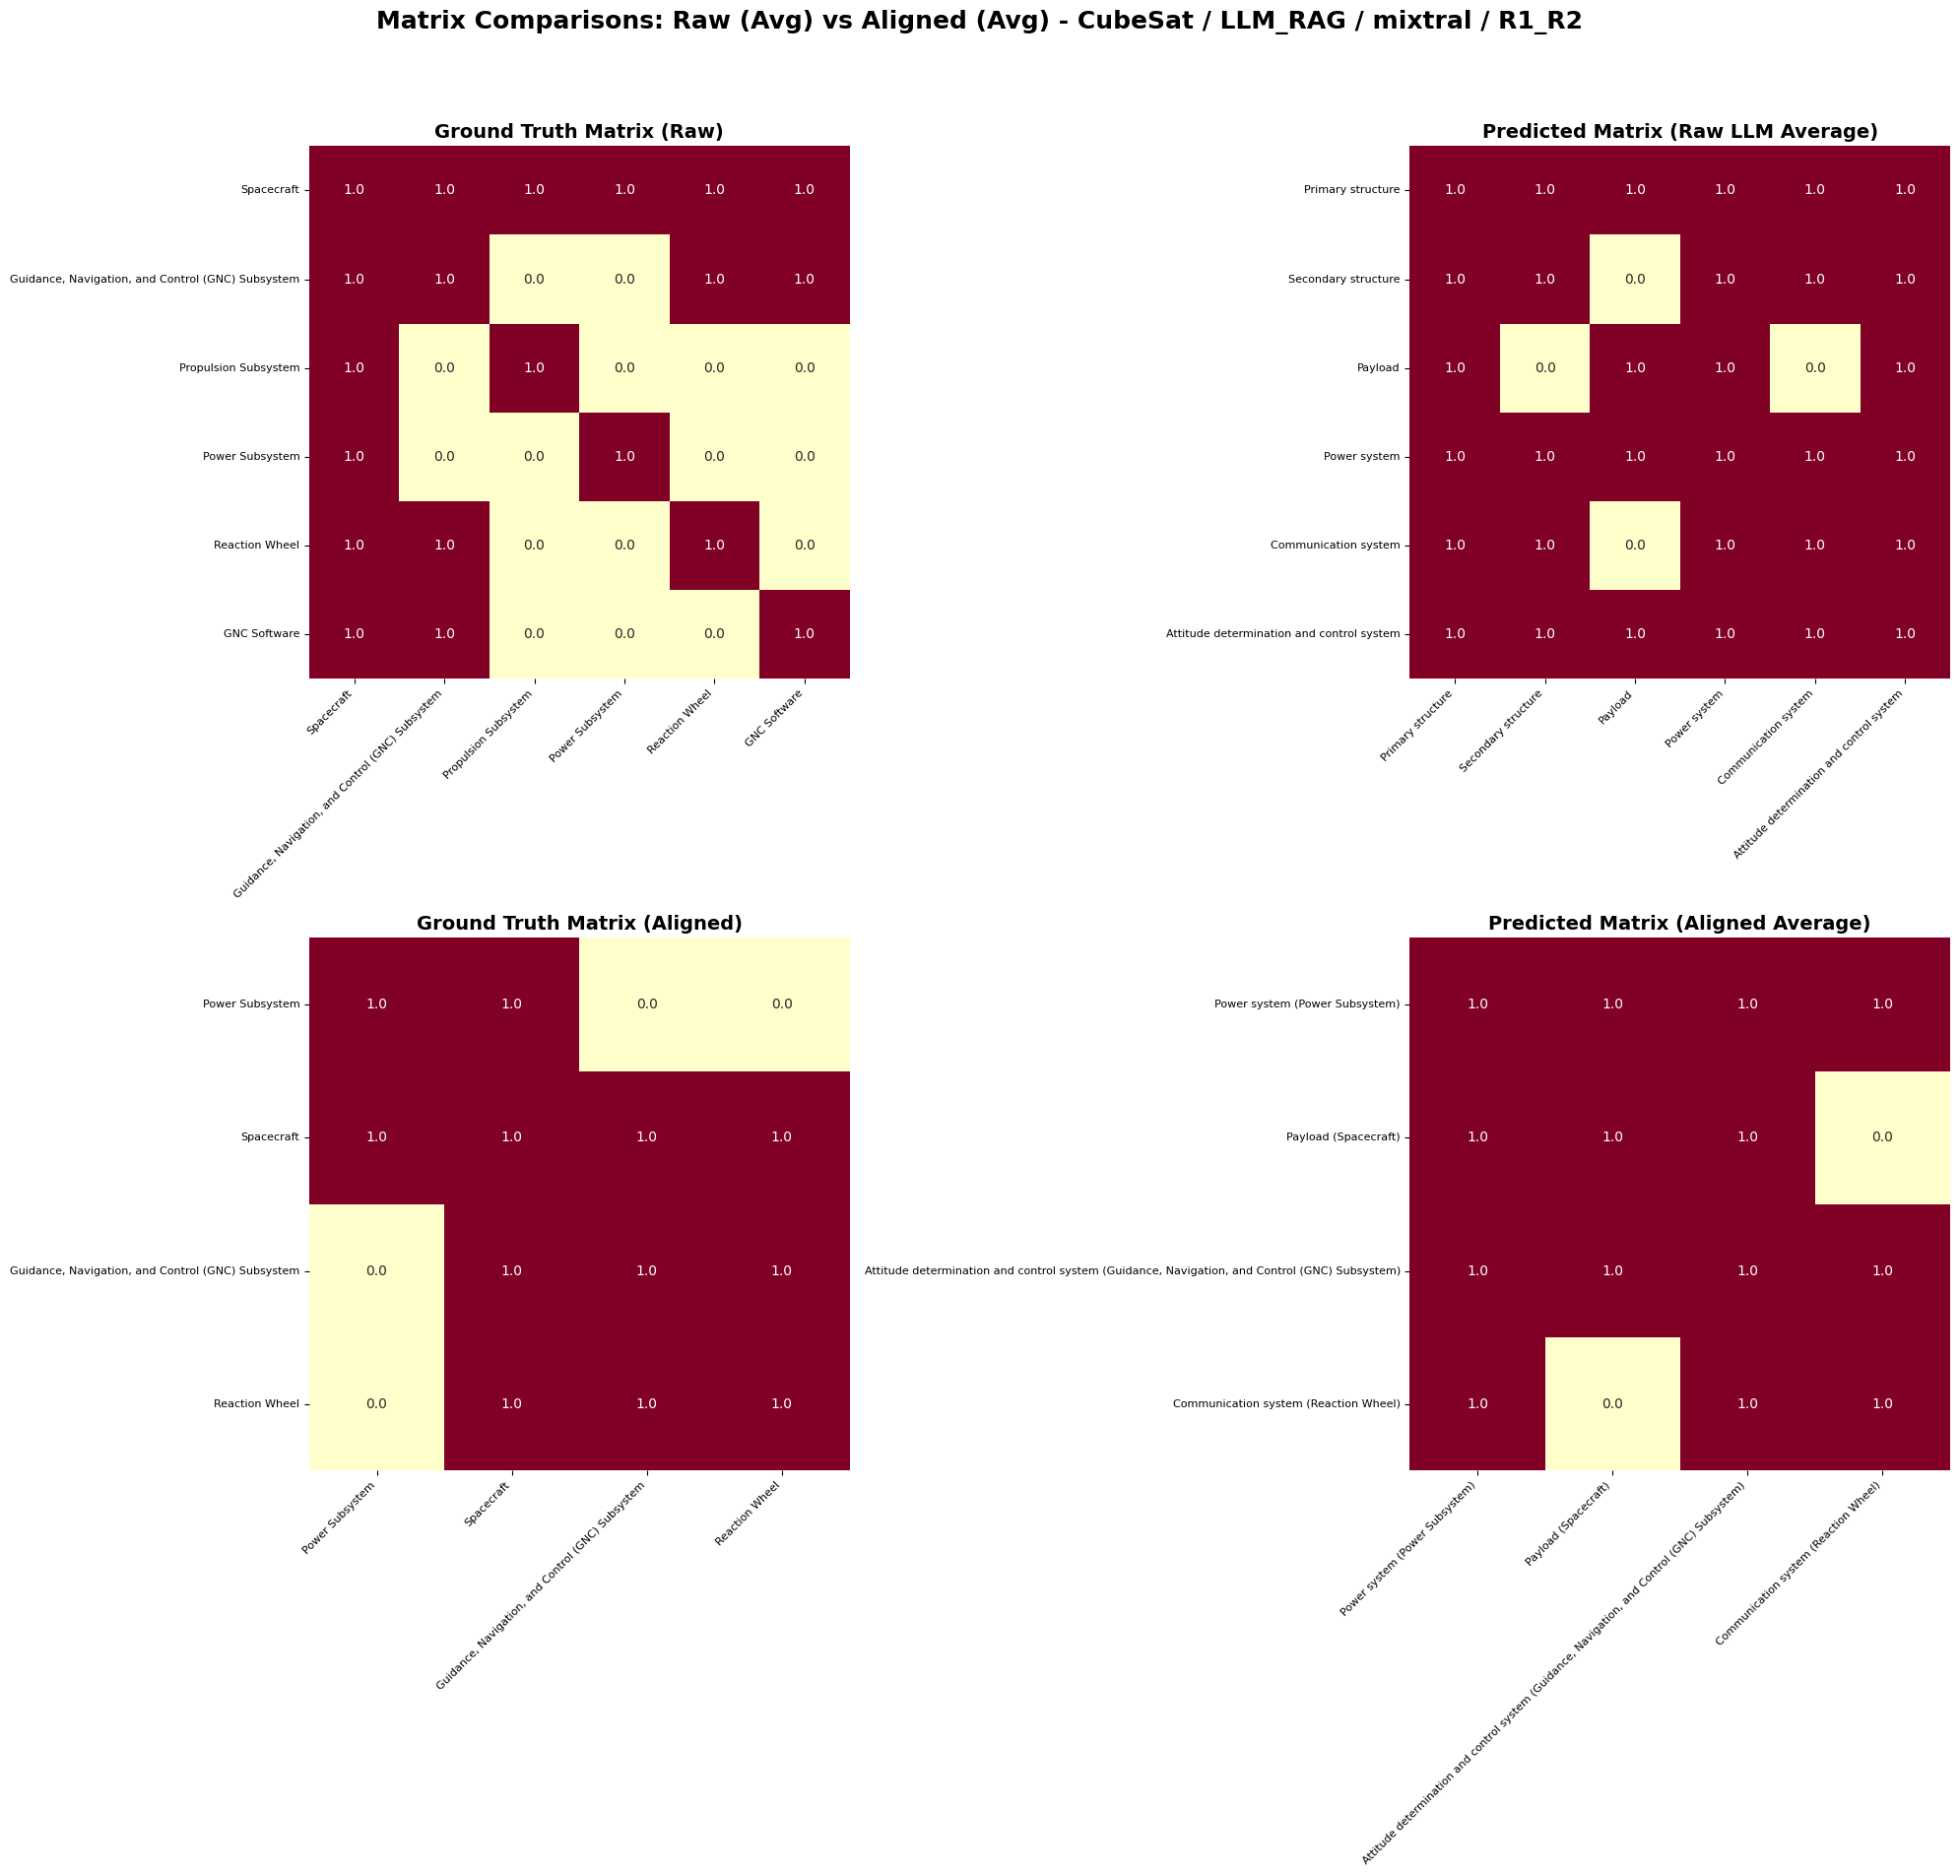

2025-04-12 23:26:38,414 - DSM_None_None_ - INFO - Plots generated and saved.
2025-04-12 23:26:38,415 - DSM_None_None_ - INFO - 
--- Results Summary for ollama:mixtral:8x22b-6k (R1_R2) ---
2025-04-12 23:26:38,416 - DSM_None_None_ - INFO - 
Raw Metrics (Mean ± StdDev):
2025-04-12 23:26:38,417 - DSM_None_None_ - INFO -   accuracy: 0.6667 ± 0.0000
2025-04-12 23:26:38,418 - DSM_None_None_ - INFO -   precision: 0.6250 ± 0.0000
2025-04-12 23:26:38,418 - DSM_None_None_ - INFO -   recall: 1.0000 ± 0.0000
2025-04-12 23:26:38,419 - DSM_None_None_ - INFO -   f1_score: 0.7692 ± 0.0000
2025-04-12 23:26:38,420 - DSM_None_None_ - INFO -   edit_distance: 12.0000 ± 0.0000
2025-04-12 23:26:38,421 - DSM_None_None_ - INFO -   spectral_distance: 2.1876 ± 0.0000
2025-04-12 23:26:38,422 - DSM_None_None_ - INFO - 
Aligned Metrics (Mean ± StdDev):
2025-04-12 23:26:38,422 - DSM_None_None_ - INFO -   accuracy: 0.6250 ± 0.0000
2025-04-12 23:26:38,423 - DSM_None_None_ - INFO -   precision: 0.7143 ± 0.0000
2025-04-1

Logger closed for ollama:mixtral:8x22b-6k (R1_R2).

---> [FIND_LATEST] Processing: CubeSat / ollama:mixtral:8x22b-6k / R1_R3
---> [FIND_LATEST] CSV Path Template: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_{timestamp}/llm_rag_refs_R1_R3/average_matrix_{timestamp}.csv
---> [FIND_LATEST] Searching Exp Dirs: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_*
---> [FIND_LATEST] Checking if parent directory exists: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG
---> [FIND_LATEST] Parent directory exists!
---> [FIND_LATEST] Found Exp Dirs (sorted): ['xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636']
---> [FIND_LATEST] Latest Exp Dir: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636
---> [FIND_LATEST] Ref Dir Path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_o

2025-04-12 23:27:00,124 - DSM_None_None_ - INFO - Running Analysis For:
2025-04-12 23:27:00,125 - DSM_None_None_ - INFO -   Product: CubeSat
2025-04-12 23:27:00,126 - DSM_None_None_ - INFO -   Model: ollama:mixtral:8x22b-6k
2025-04-12 23:27:00,127 - DSM_None_None_ - INFO -   Type: LLM_RAG
2025-04-12 23:27:00,128 - DSM_None_None_ - INFO -   Reference: R1_R3
2025-04-12 23:27:00,128 - DSM_None_None_ - INFO -   Relationship: spatial proximity
2025-04-12 23:27:00,129 - DSM_None_None_ - INFO -   Ground Truth Path: xLM_DSM_wip/logs/Process/gt_cubesat.csv
2025-04-12 23:27:00,130 - DSM_None_None_ - INFO -   Avg Pred Path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1_R3/average_matrix_20250223-150636.csv
2025-04-12 23:27:00,131 - DSM_None_None_ - INFO -   Indiv JSON Path: Not Found
2025-04-12 23:27:00,138 - DSM_None_None_ - WARNING - Individual matrices JSON file not found/specified.
2025-04-12 23:27:00,139 - DSM_None

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 36
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 36
Shape of y_true_filtered: (36,)
Shape of y_pred_filtered: (36,)
First 36 y_true_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0.
 1. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1.]
First 36 y_pred_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[2, 14], [0, 20]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (2, 14, 0, 20)
Manual Check - TP: 20, FP: 14, FN: 0, TN: 2
Calculated Accuracy: 0.6111  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.5882 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 1.0000    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.7407  [Formula: 2

2025-04-12 23:27:01,085 - DSM_None_None_ - INFO - Attempting Component Mapping based on Average Matrix...
2025-04-12 23:27:01,086 - DSM_None_None_ - INFO - Starting get_best_component_matches function
2025-04-12 23:27:01,087 - DSM_None_None_ - INFO - Extracting model from path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1_R3/average_matrix_20250223-150636.csv
2025-04-12 23:27:01,087 - DSM_None_None_ - INFO - Extracted model: mixtral:8x22b-6k
2025-04-12 23:27:01,094 - DSM_None_None_ - INFO - Automatic high-similarity match: Power Subsystem -> Power System (similarity: 0.786)
2025-04-12 23:27:01,107 - DSM_None_None_ - INFO - Prompt: 
You are an expert matching engine for cubesat systems. Your task is to determine the optimal one-to-one mapping between remaining ground truth and predicted major components.

Remaining Ground Truth Components:
['Spacecraft', 'Guidance, Navigation, and Control (GNC) Subsystem', 'P

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 16
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 16
Shape of y_true_filtered: (16,)
Shape of y_pred_filtered: (16,)
First 16 y_true_filtered: [1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1.]
First 16 y_pred_filtered: [1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[2, 4], [0, 10]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (2, 4, 0, 10)
Manual Check - TP: 10, FP: 4, FN: 0, TN: 2
Calculated Accuracy: 0.7500  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.7143 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 1.0000    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.8333  [Formula: 2*(Prec*Rec)/(Prec+Rec)]
--- End Debugging ---


2025-04-12 23:27:59,152 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1_R3/plots/performance_metrics_with_stddev.png


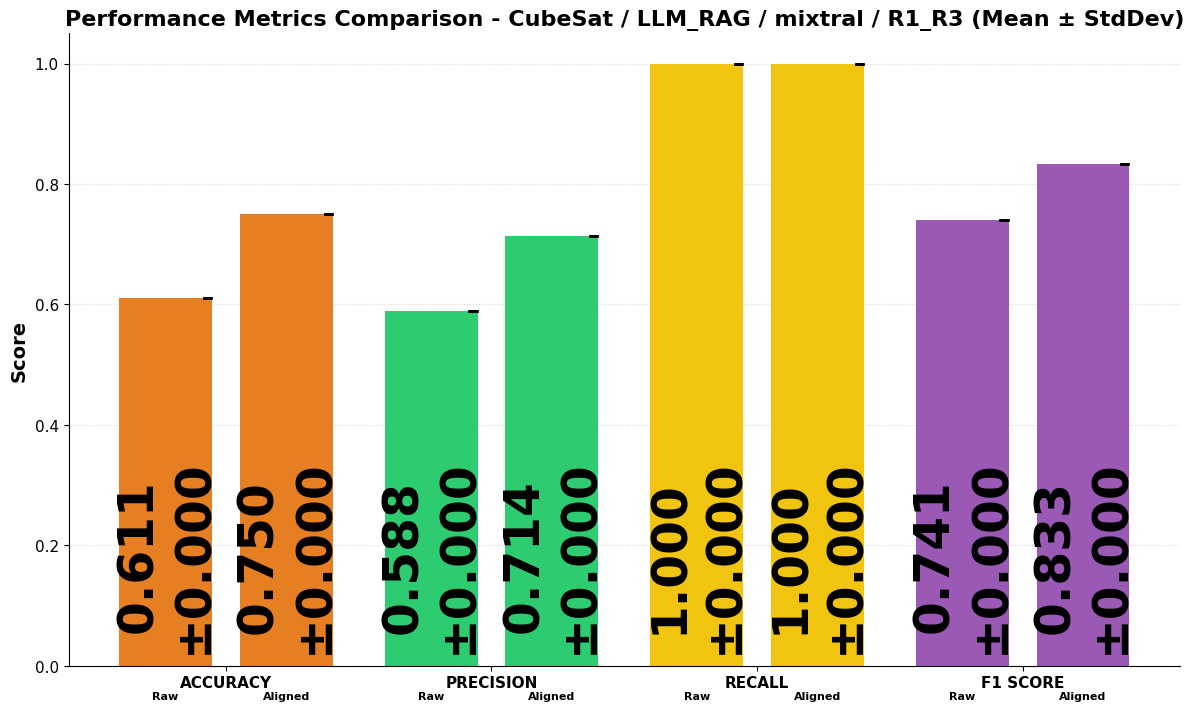

2025-04-12 23:27:59,269 - DSM_None_None_ - INFO - Plotting distance metrics...
2025-04-12 23:27:59,718 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1_R3/plots/distance_metrics_with_stddev.png


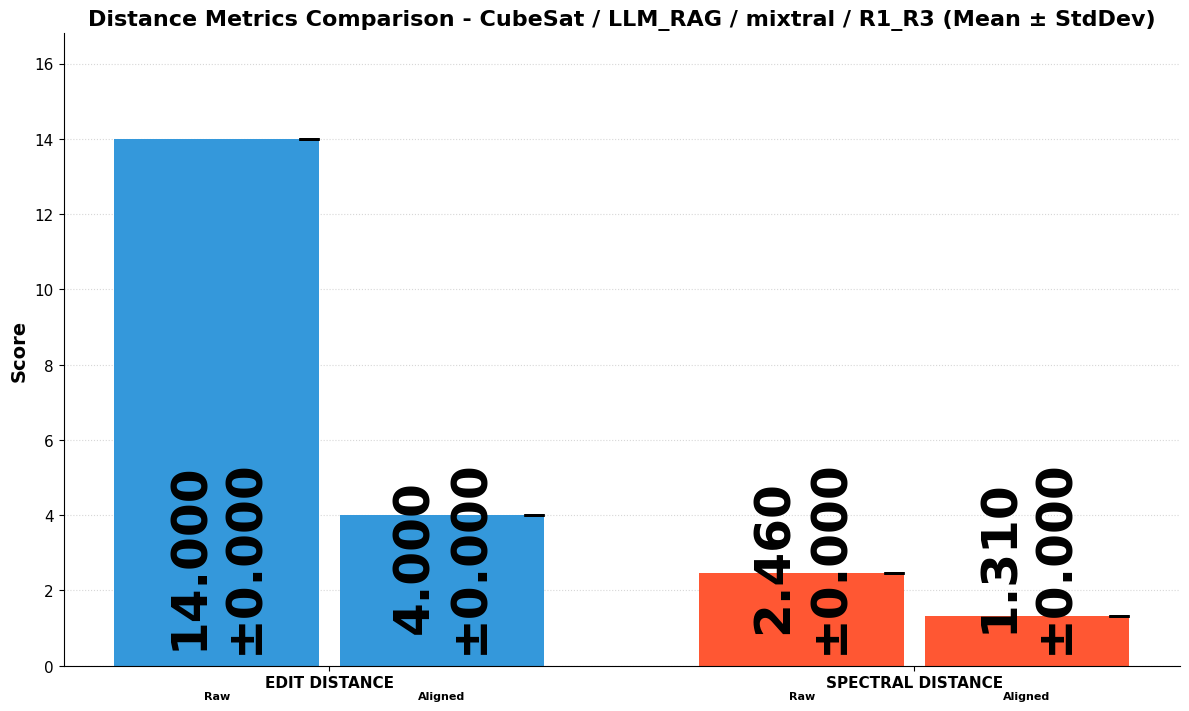

2025-04-12 23:27:59,832 - DSM_None_None_ - INFO - Plotting matrix comparison...
2025-04-12 23:28:02,182 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1_R3/plots/matrices_comparison_avg.png


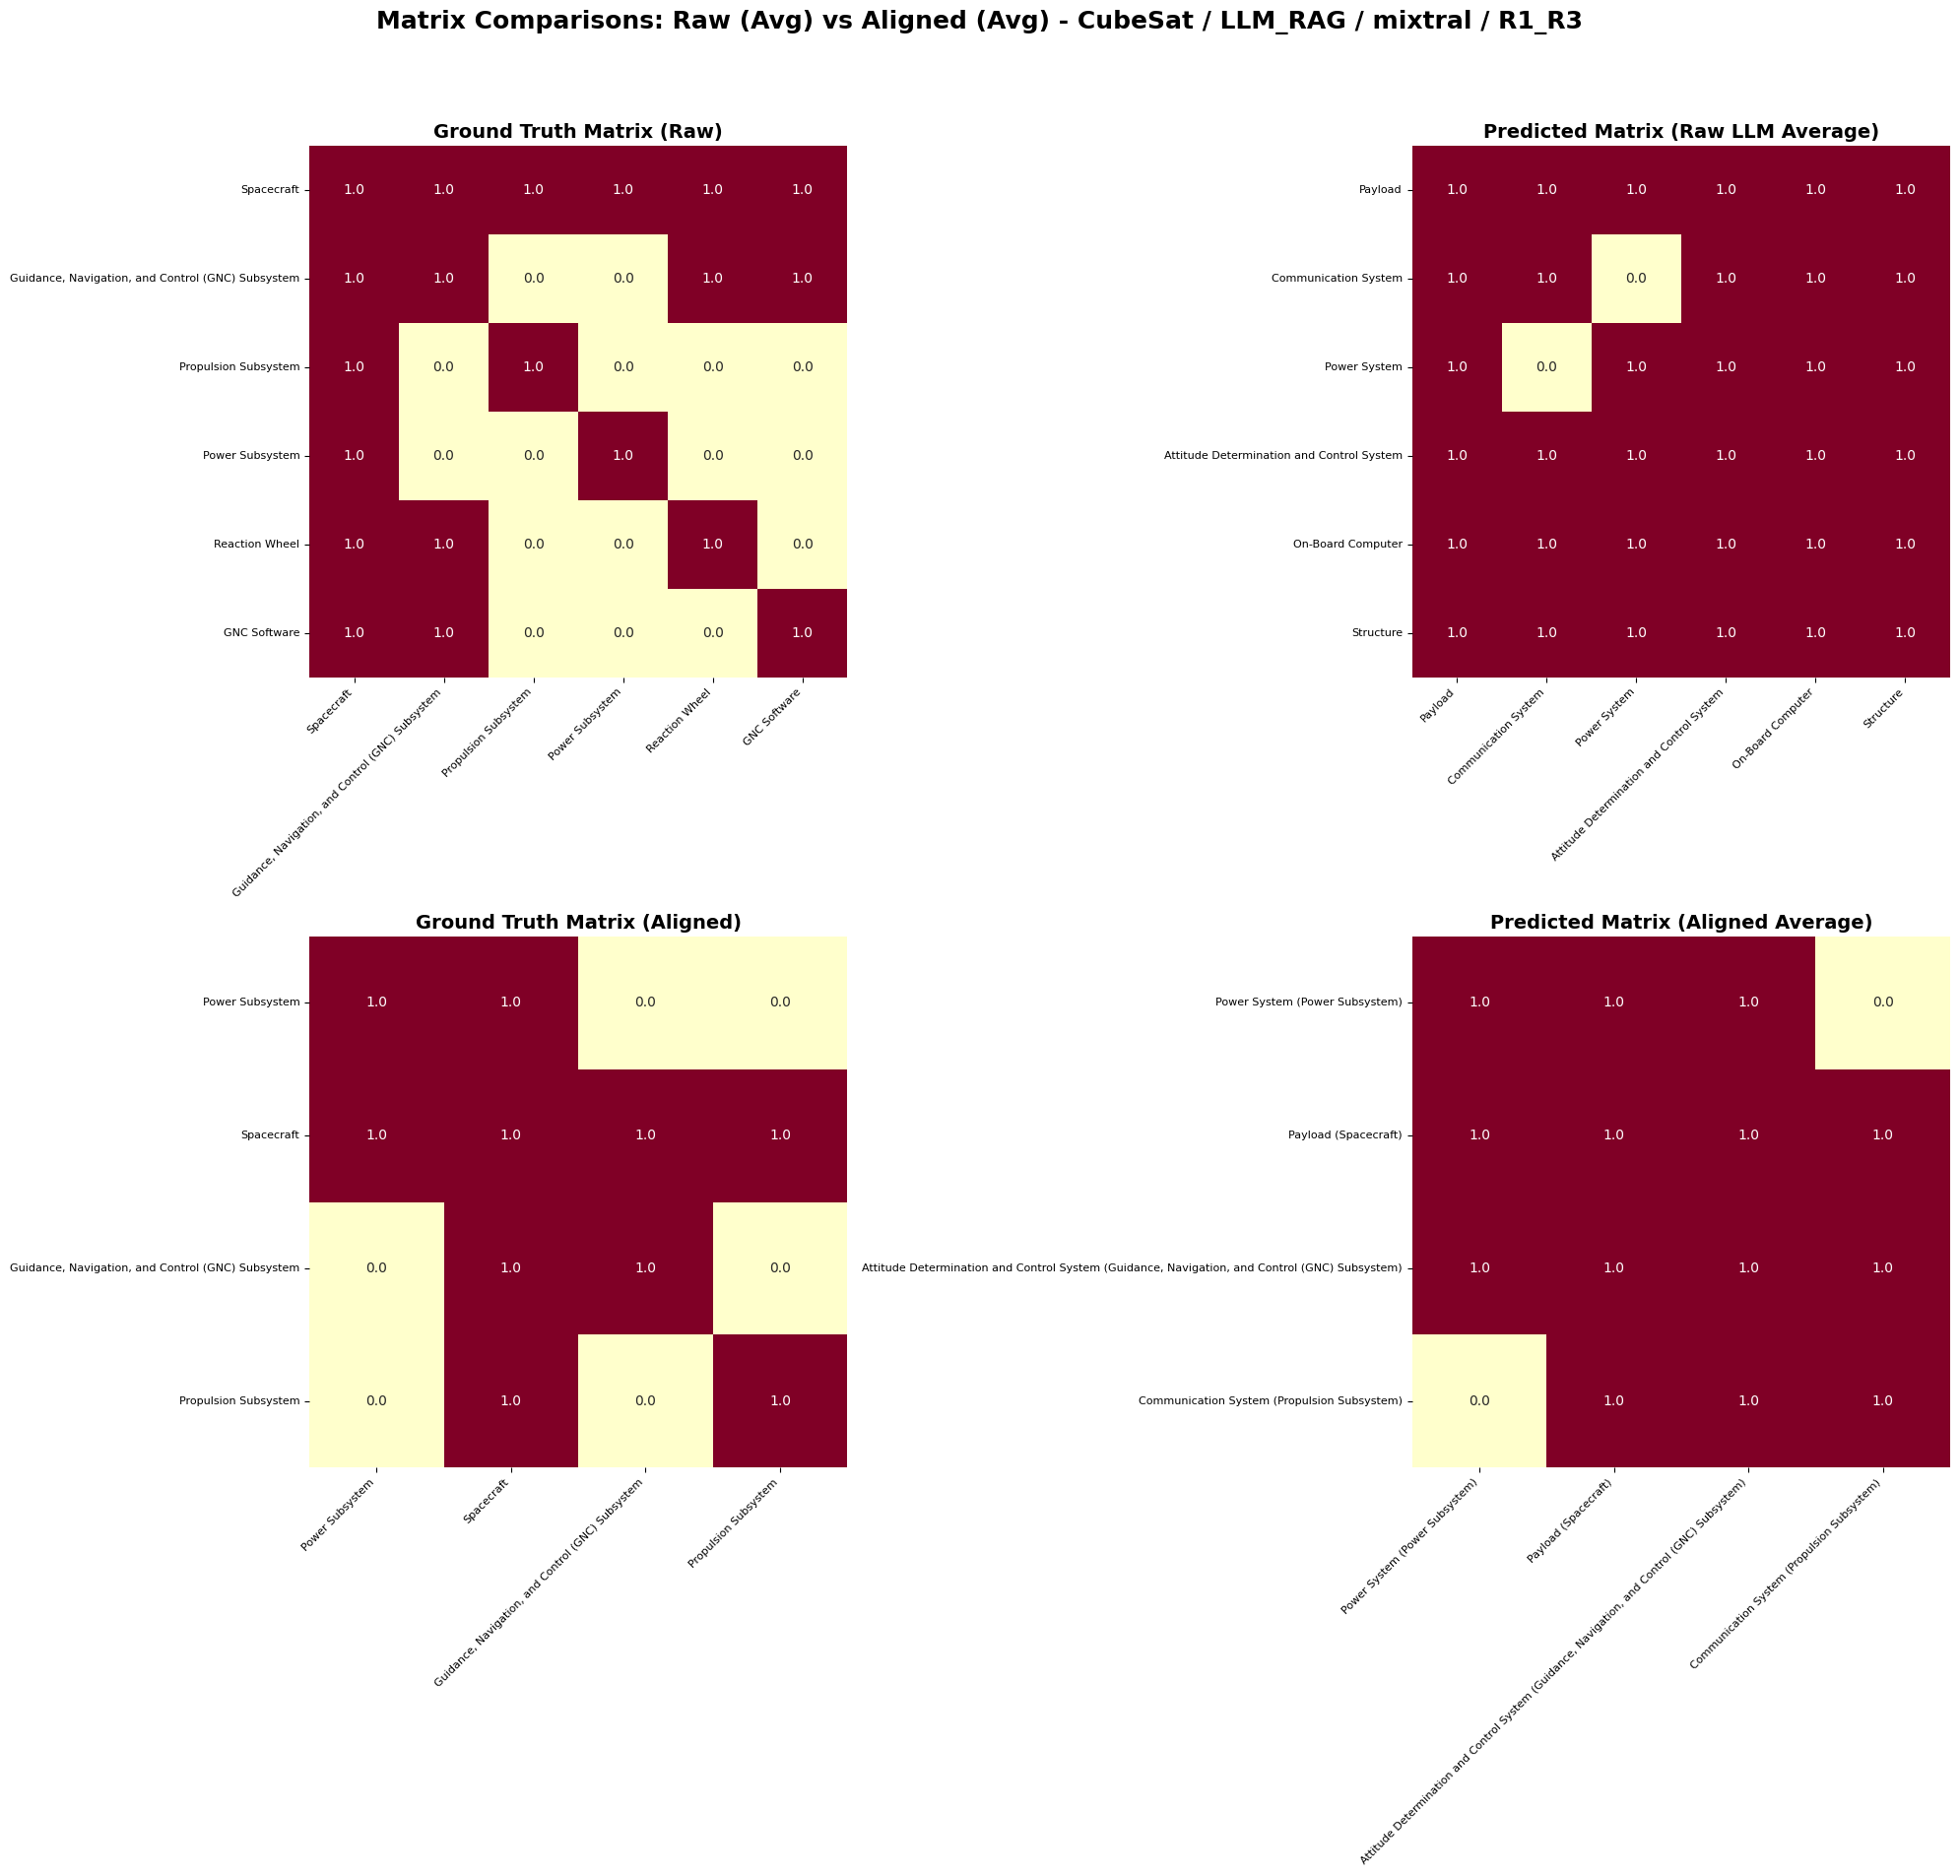

2025-04-12 23:28:02,554 - DSM_None_None_ - INFO - Plots generated and saved.
2025-04-12 23:28:02,555 - DSM_None_None_ - INFO - 
--- Results Summary for ollama:mixtral:8x22b-6k (R1_R3) ---
2025-04-12 23:28:02,556 - DSM_None_None_ - INFO - 
Raw Metrics (Mean ± StdDev):
2025-04-12 23:28:02,556 - DSM_None_None_ - INFO -   accuracy: 0.6111 ± 0.0000
2025-04-12 23:28:02,557 - DSM_None_None_ - INFO -   precision: 0.5882 ± 0.0000
2025-04-12 23:28:02,558 - DSM_None_None_ - INFO -   recall: 1.0000 ± 0.0000
2025-04-12 23:28:02,559 - DSM_None_None_ - INFO -   f1_score: 0.7407 ± 0.0000
2025-04-12 23:28:02,559 - DSM_None_None_ - INFO -   edit_distance: 14.0000 ± 0.0000
2025-04-12 23:28:02,560 - DSM_None_None_ - INFO -   spectral_distance: 2.4599 ± 0.0000
2025-04-12 23:28:02,560 - DSM_None_None_ - INFO - 
Aligned Metrics (Mean ± StdDev):
2025-04-12 23:28:02,561 - DSM_None_None_ - INFO -   accuracy: 0.7500 ± 0.0000
2025-04-12 23:28:02,563 - DSM_None_None_ - INFO -   precision: 0.7143 ± 0.0000
2025-04-1

Logger closed for ollama:mixtral:8x22b-6k (R1_R3).

---> [FIND_LATEST] Processing: CubeSat / ollama:mixtral:8x22b-6k / R2_R3
---> [FIND_LATEST] CSV Path Template: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_{timestamp}/llm_rag_refs_R2_R3/average_matrix_{timestamp}.csv
---> [FIND_LATEST] Searching Exp Dirs: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_*
---> [FIND_LATEST] Checking if parent directory exists: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG
---> [FIND_LATEST] Parent directory exists!
---> [FIND_LATEST] Found Exp Dirs (sorted): ['xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636']
---> [FIND_LATEST] Latest Exp Dir: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636
---> [FIND_LATEST] Ref Dir Path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_o

2025-04-12 23:28:24,373 - DSM_None_None_ - INFO - Running Analysis For:
2025-04-12 23:28:24,375 - DSM_None_None_ - INFO -   Product: CubeSat
2025-04-12 23:28:24,375 - DSM_None_None_ - INFO -   Model: ollama:mixtral:8x22b-6k
2025-04-12 23:28:24,376 - DSM_None_None_ - INFO -   Type: LLM_RAG
2025-04-12 23:28:24,377 - DSM_None_None_ - INFO -   Reference: R2_R3
2025-04-12 23:28:24,379 - DSM_None_None_ - INFO -   Relationship: spatial proximity
2025-04-12 23:28:24,379 - DSM_None_None_ - INFO -   Ground Truth Path: xLM_DSM_wip/logs/Process/gt_cubesat.csv
2025-04-12 23:28:24,381 - DSM_None_None_ - INFO -   Avg Pred Path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R2_R3/average_matrix_20250223-150636.csv
2025-04-12 23:28:24,382 - DSM_None_None_ - INFO -   Indiv JSON Path: Not Found
2025-04-12 23:28:24,387 - DSM_None_None_ - WARNING - Individual matrices JSON file not found/specified.
2025-04-12 23:28:24,388 - DSM_None

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 36
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 36
Shape of y_true_filtered: (36,)
Shape of y_pred_filtered: (36,)
First 36 y_true_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0.
 1. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1.]
First 36 y_pred_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[4, 12], [0, 20]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (4, 12, 0, 20)
Manual Check - TP: 20, FP: 12, FN: 0, TN: 4
Calculated Accuracy: 0.6667  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.6250 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 1.0000    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.7692  [Formula: 2

2025-04-12 23:28:25,145 - DSM_None_None_ - INFO - Attempting Component Mapping based on Average Matrix...
2025-04-12 23:28:25,145 - DSM_None_None_ - INFO - Starting get_best_component_matches function
2025-04-12 23:28:25,146 - DSM_None_None_ - INFO - Extracting model from path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R2_R3/average_matrix_20250223-150636.csv
2025-04-12 23:28:25,147 - DSM_None_None_ - INFO - Extracted model: mixtral:8x22b-6k
2025-04-12 23:28:25,155 - DSM_None_None_ - INFO - Automatic high-similarity match: Power Subsystem -> Power system (similarity: 0.778)
2025-04-12 23:28:25,167 - DSM_None_None_ - INFO - Prompt: 
You are an expert matching engine for cubesat systems. Your task is to determine the optimal one-to-one mapping between remaining ground truth and predicted major components.

Remaining Ground Truth Components:
['Spacecraft', 'Guidance, Navigation, and Control (GNC) Subsystem', 'P

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 16
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 16
Shape of y_true_filtered: (16,)
Shape of y_pred_filtered: (16,)
First 16 y_true_filtered: [1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1.]
First 16 y_pred_filtered: [1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[0, 4], [2, 10]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (0, 4, 2, 10)
Manual Check - TP: 10, FP: 4, FN: 2, TN: 0
Calculated Accuracy: 0.6250  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.7143 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.8333    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.7692  [Formula: 2*(Prec*Rec)/(Prec+Rec)]
--- End Debugging ---


2025-04-12 23:29:20,857 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R2_R3/plots/performance_metrics_with_stddev.png


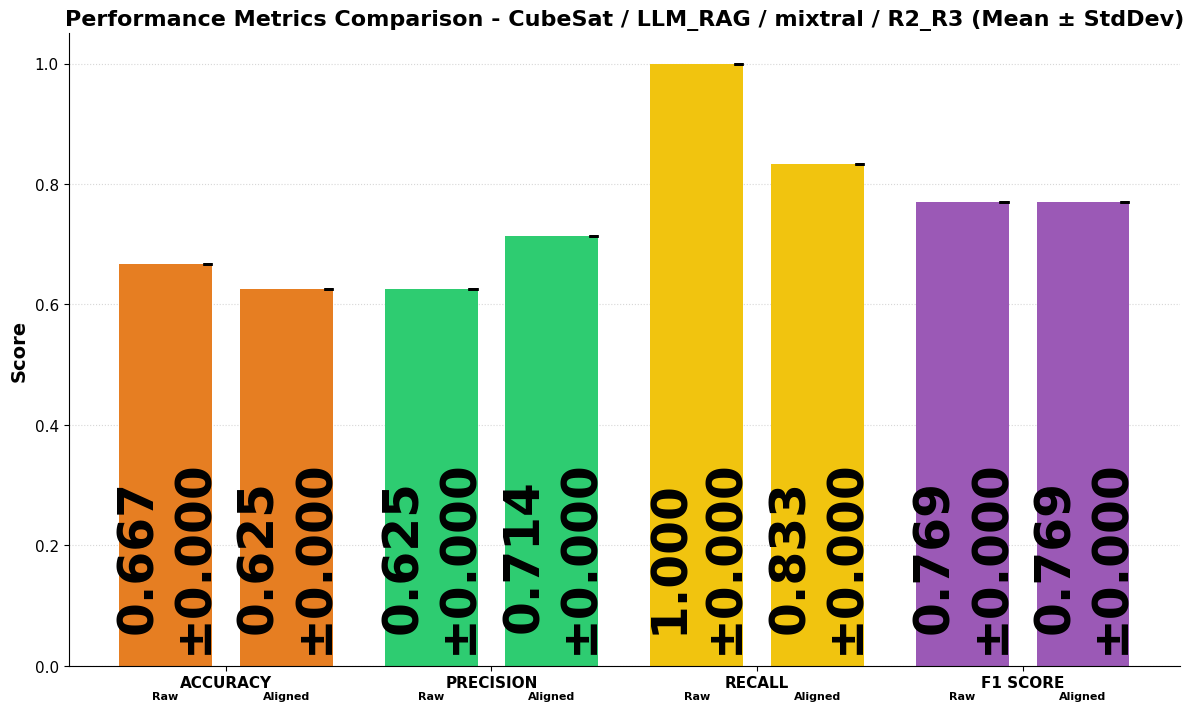

2025-04-12 23:29:20,974 - DSM_None_None_ - INFO - Plotting distance metrics...
2025-04-12 23:29:21,409 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R2_R3/plots/distance_metrics_with_stddev.png


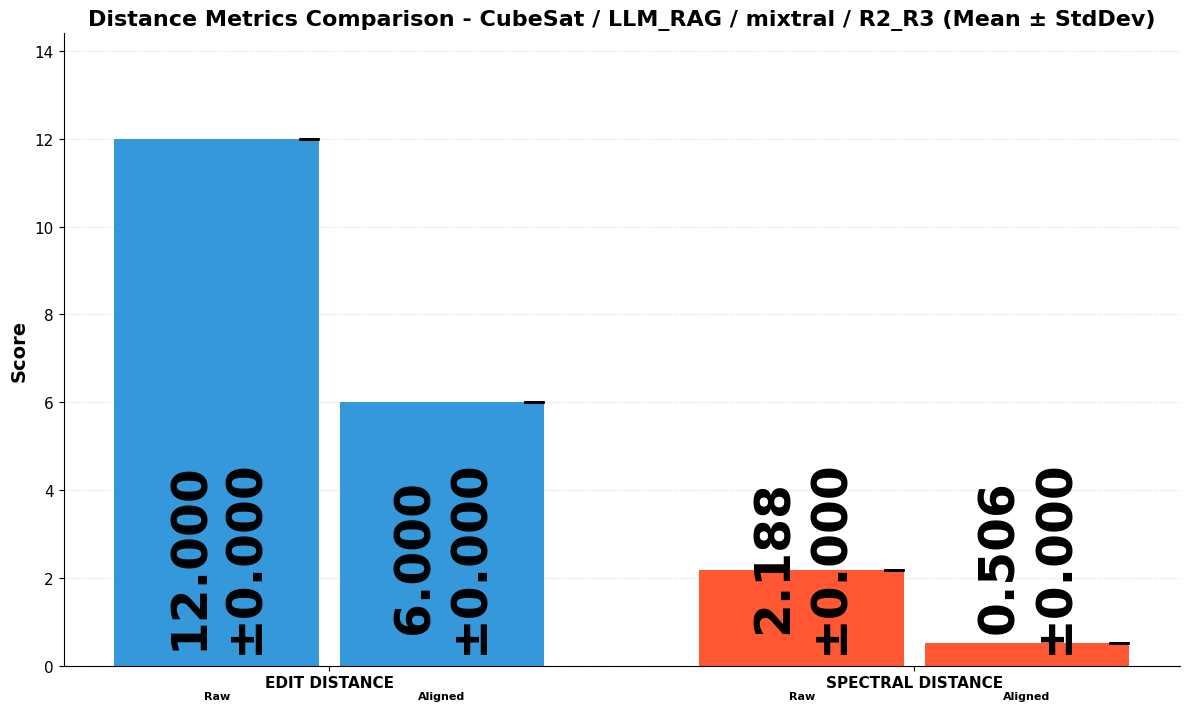

2025-04-12 23:29:21,511 - DSM_None_None_ - INFO - Plotting matrix comparison...
2025-04-12 23:29:23,618 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R2_R3/plots/matrices_comparison_avg.png


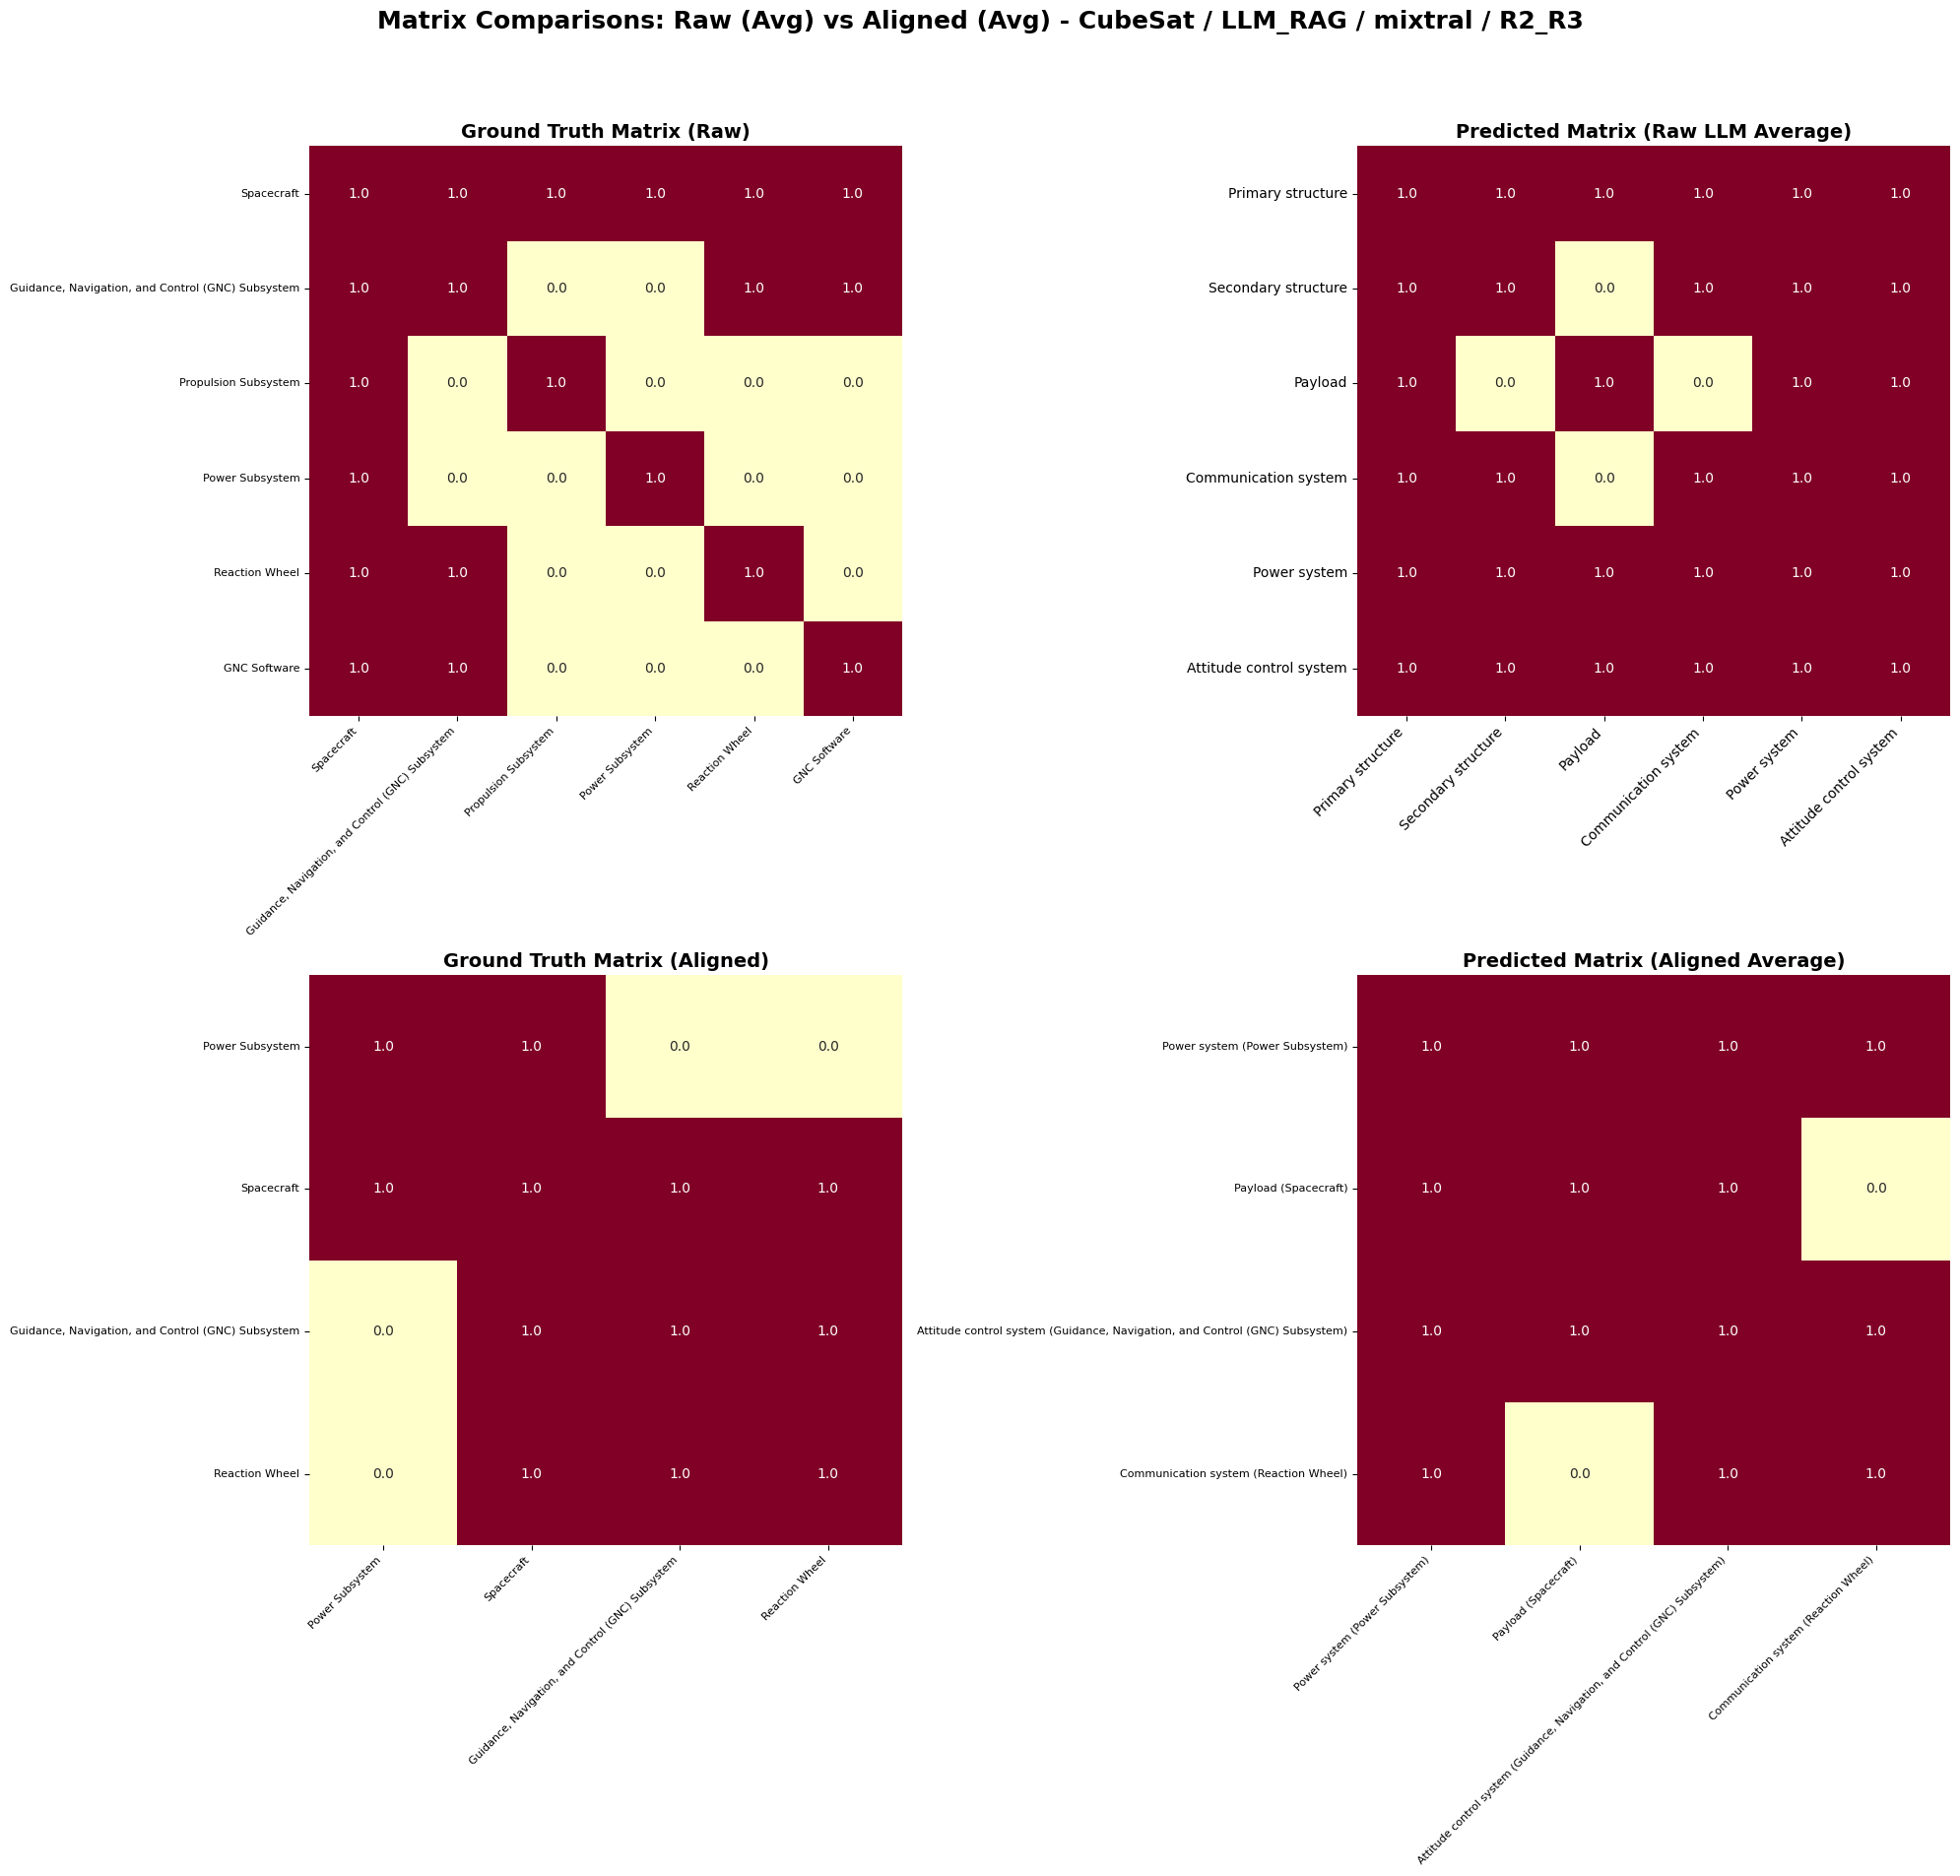

2025-04-12 23:29:23,990 - DSM_None_None_ - INFO - Plots generated and saved.
2025-04-12 23:29:23,991 - DSM_None_None_ - INFO - 
--- Results Summary for ollama:mixtral:8x22b-6k (R2_R3) ---
2025-04-12 23:29:23,992 - DSM_None_None_ - INFO - 
Raw Metrics (Mean ± StdDev):
2025-04-12 23:29:23,992 - DSM_None_None_ - INFO -   accuracy: 0.6667 ± 0.0000
2025-04-12 23:29:23,993 - DSM_None_None_ - INFO -   precision: 0.6250 ± 0.0000
2025-04-12 23:29:23,994 - DSM_None_None_ - INFO -   recall: 1.0000 ± 0.0000
2025-04-12 23:29:23,994 - DSM_None_None_ - INFO -   f1_score: 0.7692 ± 0.0000
2025-04-12 23:29:23,995 - DSM_None_None_ - INFO -   edit_distance: 12.0000 ± 0.0000
2025-04-12 23:29:23,996 - DSM_None_None_ - INFO -   spectral_distance: 2.1876 ± 0.0000
2025-04-12 23:29:23,996 - DSM_None_None_ - INFO - 
Aligned Metrics (Mean ± StdDev):
2025-04-12 23:29:23,997 - DSM_None_None_ - INFO -   accuracy: 0.6250 ± 0.0000
2025-04-12 23:29:23,997 - DSM_None_None_ - INFO -   precision: 0.7143 ± 0.0000
2025-04-1

Logger closed for ollama:mixtral:8x22b-6k (R2_R3).

---> [FIND_LATEST] Processing: CubeSat / ollama:mixtral:8x22b-6k / R1_R2_R3
---> [FIND_LATEST] CSV Path Template: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_{timestamp}/llm_rag_refs_R1_R2_R3/average_matrix_{timestamp}.csv
---> [FIND_LATEST] Searching Exp Dirs: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_*
---> [FIND_LATEST] Checking if parent directory exists: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG
---> [FIND_LATEST] Parent directory exists!
---> [FIND_LATEST] Found Exp Dirs (sorted): ['xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636']
---> [FIND_LATEST] Latest Exp Dir: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636
---> [FIND_LATEST] Ref Dir Path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm

2025-04-12 23:29:45,808 - DSM_None_None_ - INFO - Running Analysis For:
2025-04-12 23:29:45,809 - DSM_None_None_ - INFO -   Product: CubeSat
2025-04-12 23:29:45,810 - DSM_None_None_ - INFO -   Model: ollama:mixtral:8x22b-6k
2025-04-12 23:29:45,811 - DSM_None_None_ - INFO -   Type: LLM_RAG
2025-04-12 23:29:45,812 - DSM_None_None_ - INFO -   Reference: R1_R2_R3
2025-04-12 23:29:45,812 - DSM_None_None_ - INFO -   Relationship: spatial proximity
2025-04-12 23:29:45,813 - DSM_None_None_ - INFO -   Ground Truth Path: xLM_DSM_wip/logs/Process/gt_cubesat.csv
2025-04-12 23:29:45,814 - DSM_None_None_ - INFO -   Avg Pred Path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1_R2_R3/average_matrix_20250223-150636.csv
2025-04-12 23:29:45,815 - DSM_None_None_ - INFO -   Indiv JSON Path: Not Found
2025-04-12 23:29:45,821 - DSM_None_None_ - WARNING - Individual matrices JSON file not found/specified.
2025-04-12 23:29:45,822 - DS

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 36
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 36
Shape of y_true_filtered: (36,)
Shape of y_pred_filtered: (36,)
First 36 y_true_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0.
 1. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1.]
First 36 y_pred_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[4, 12], [0, 20]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (4, 12, 0, 20)
Manual Check - TP: 20, FP: 12, FN: 0, TN: 4
Calculated Accuracy: 0.6667  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.6250 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 1.0000    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.7692  [Formula: 2

2025-04-12 23:29:47,398 - DSM_None_None_ - INFO - Attempting Component Mapping based on Average Matrix...
2025-04-12 23:29:47,399 - DSM_None_None_ - INFO - Starting get_best_component_matches function
2025-04-12 23:29:47,400 - DSM_None_None_ - INFO - Extracting model from path: xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1_R2_R3/average_matrix_20250223-150636.csv
2025-04-12 23:29:47,401 - DSM_None_None_ - INFO - Extracted model: mixtral:8x22b-6k
2025-04-12 23:29:47,408 - DSM_None_None_ - INFO - Automatic high-similarity match: Power Subsystem -> Power system (similarity: 0.778)
2025-04-12 23:29:47,420 - DSM_None_None_ - INFO - Prompt: 
You are an expert matching engine for cubesat systems. Your task is to determine the optimal one-to-one mapping between remaining ground truth and predicted major components.

Remaining Ground Truth Components:
['Spacecraft', 'Guidance, Navigation, and Control (GNC) Subsystem',

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 9
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 9
Shape of y_true_filtered: (9,)
Shape of y_pred_filtered: (9,)
First 9 y_true_filtered: [1. 1. 0. 1. 1. 1. 0. 1. 1.]
First 9 y_pred_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[0, 2], [0, 7]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (0, 2, 0, 7)
Manual Check - TP: 7, FP: 2, FN: 0, TN: 0
Calculated Accuracy: 0.7778  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.7778 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 1.0000    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.8750  [Formula: 2*(Prec*Rec)/(Prec+Rec)]
--- End Debugging ---


2025-04-12 23:30:39,874 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1_R2_R3/plots/performance_metrics_with_stddev.png


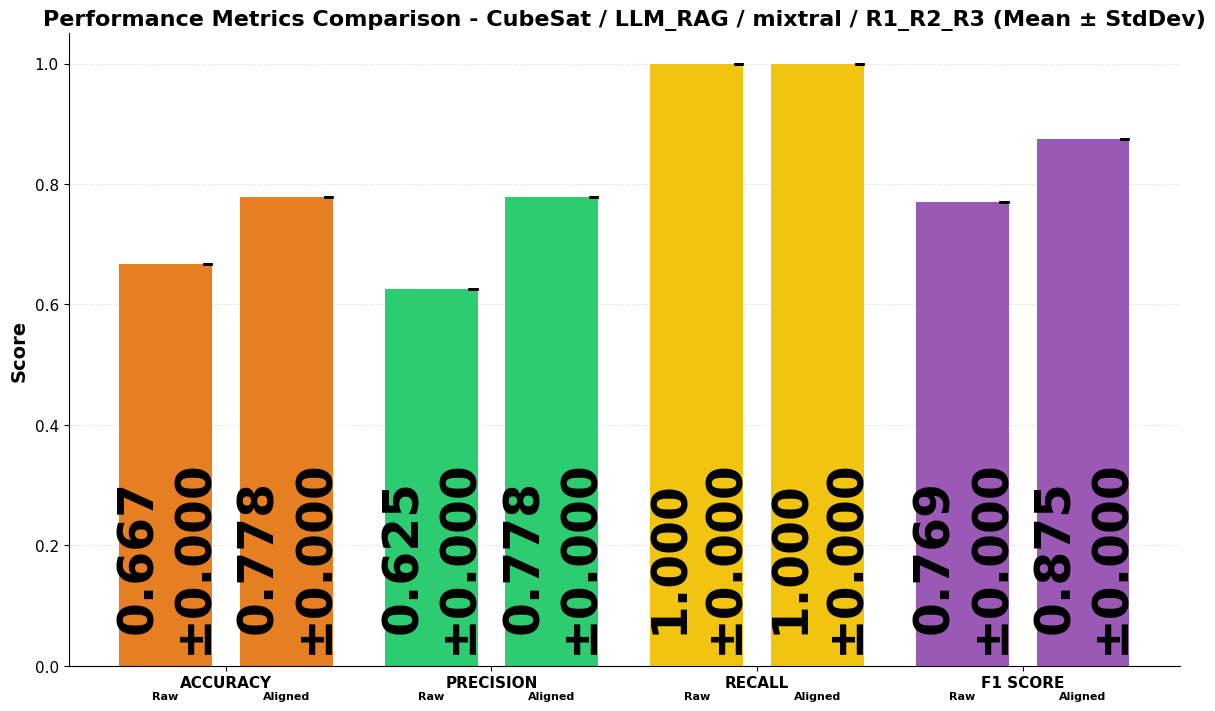

2025-04-12 23:30:39,991 - DSM_None_None_ - INFO - Plotting distance metrics...
2025-04-12 23:30:40,424 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1_R2_R3/plots/distance_metrics_with_stddev.png


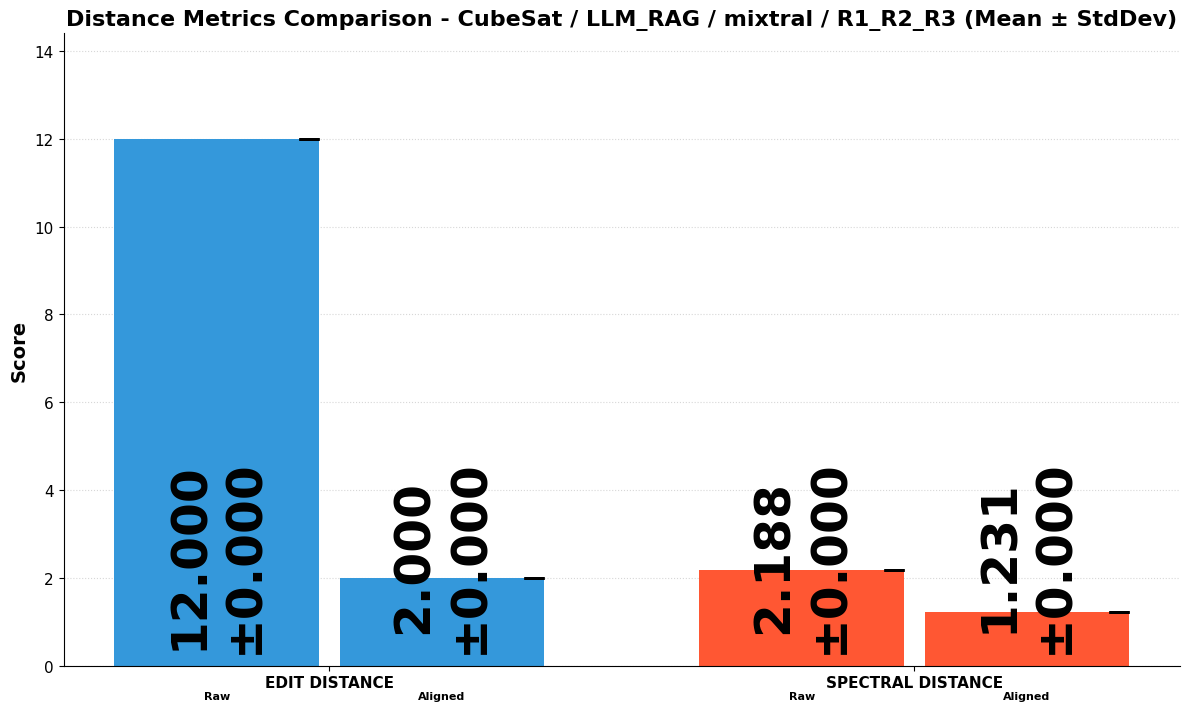

2025-04-12 23:30:40,527 - DSM_None_None_ - INFO - Plotting matrix comparison...
2025-04-12 23:30:42,605 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/CubeSat/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250223-150636/llm_rag_refs_R1_R2_R3/plots/matrices_comparison_avg.png


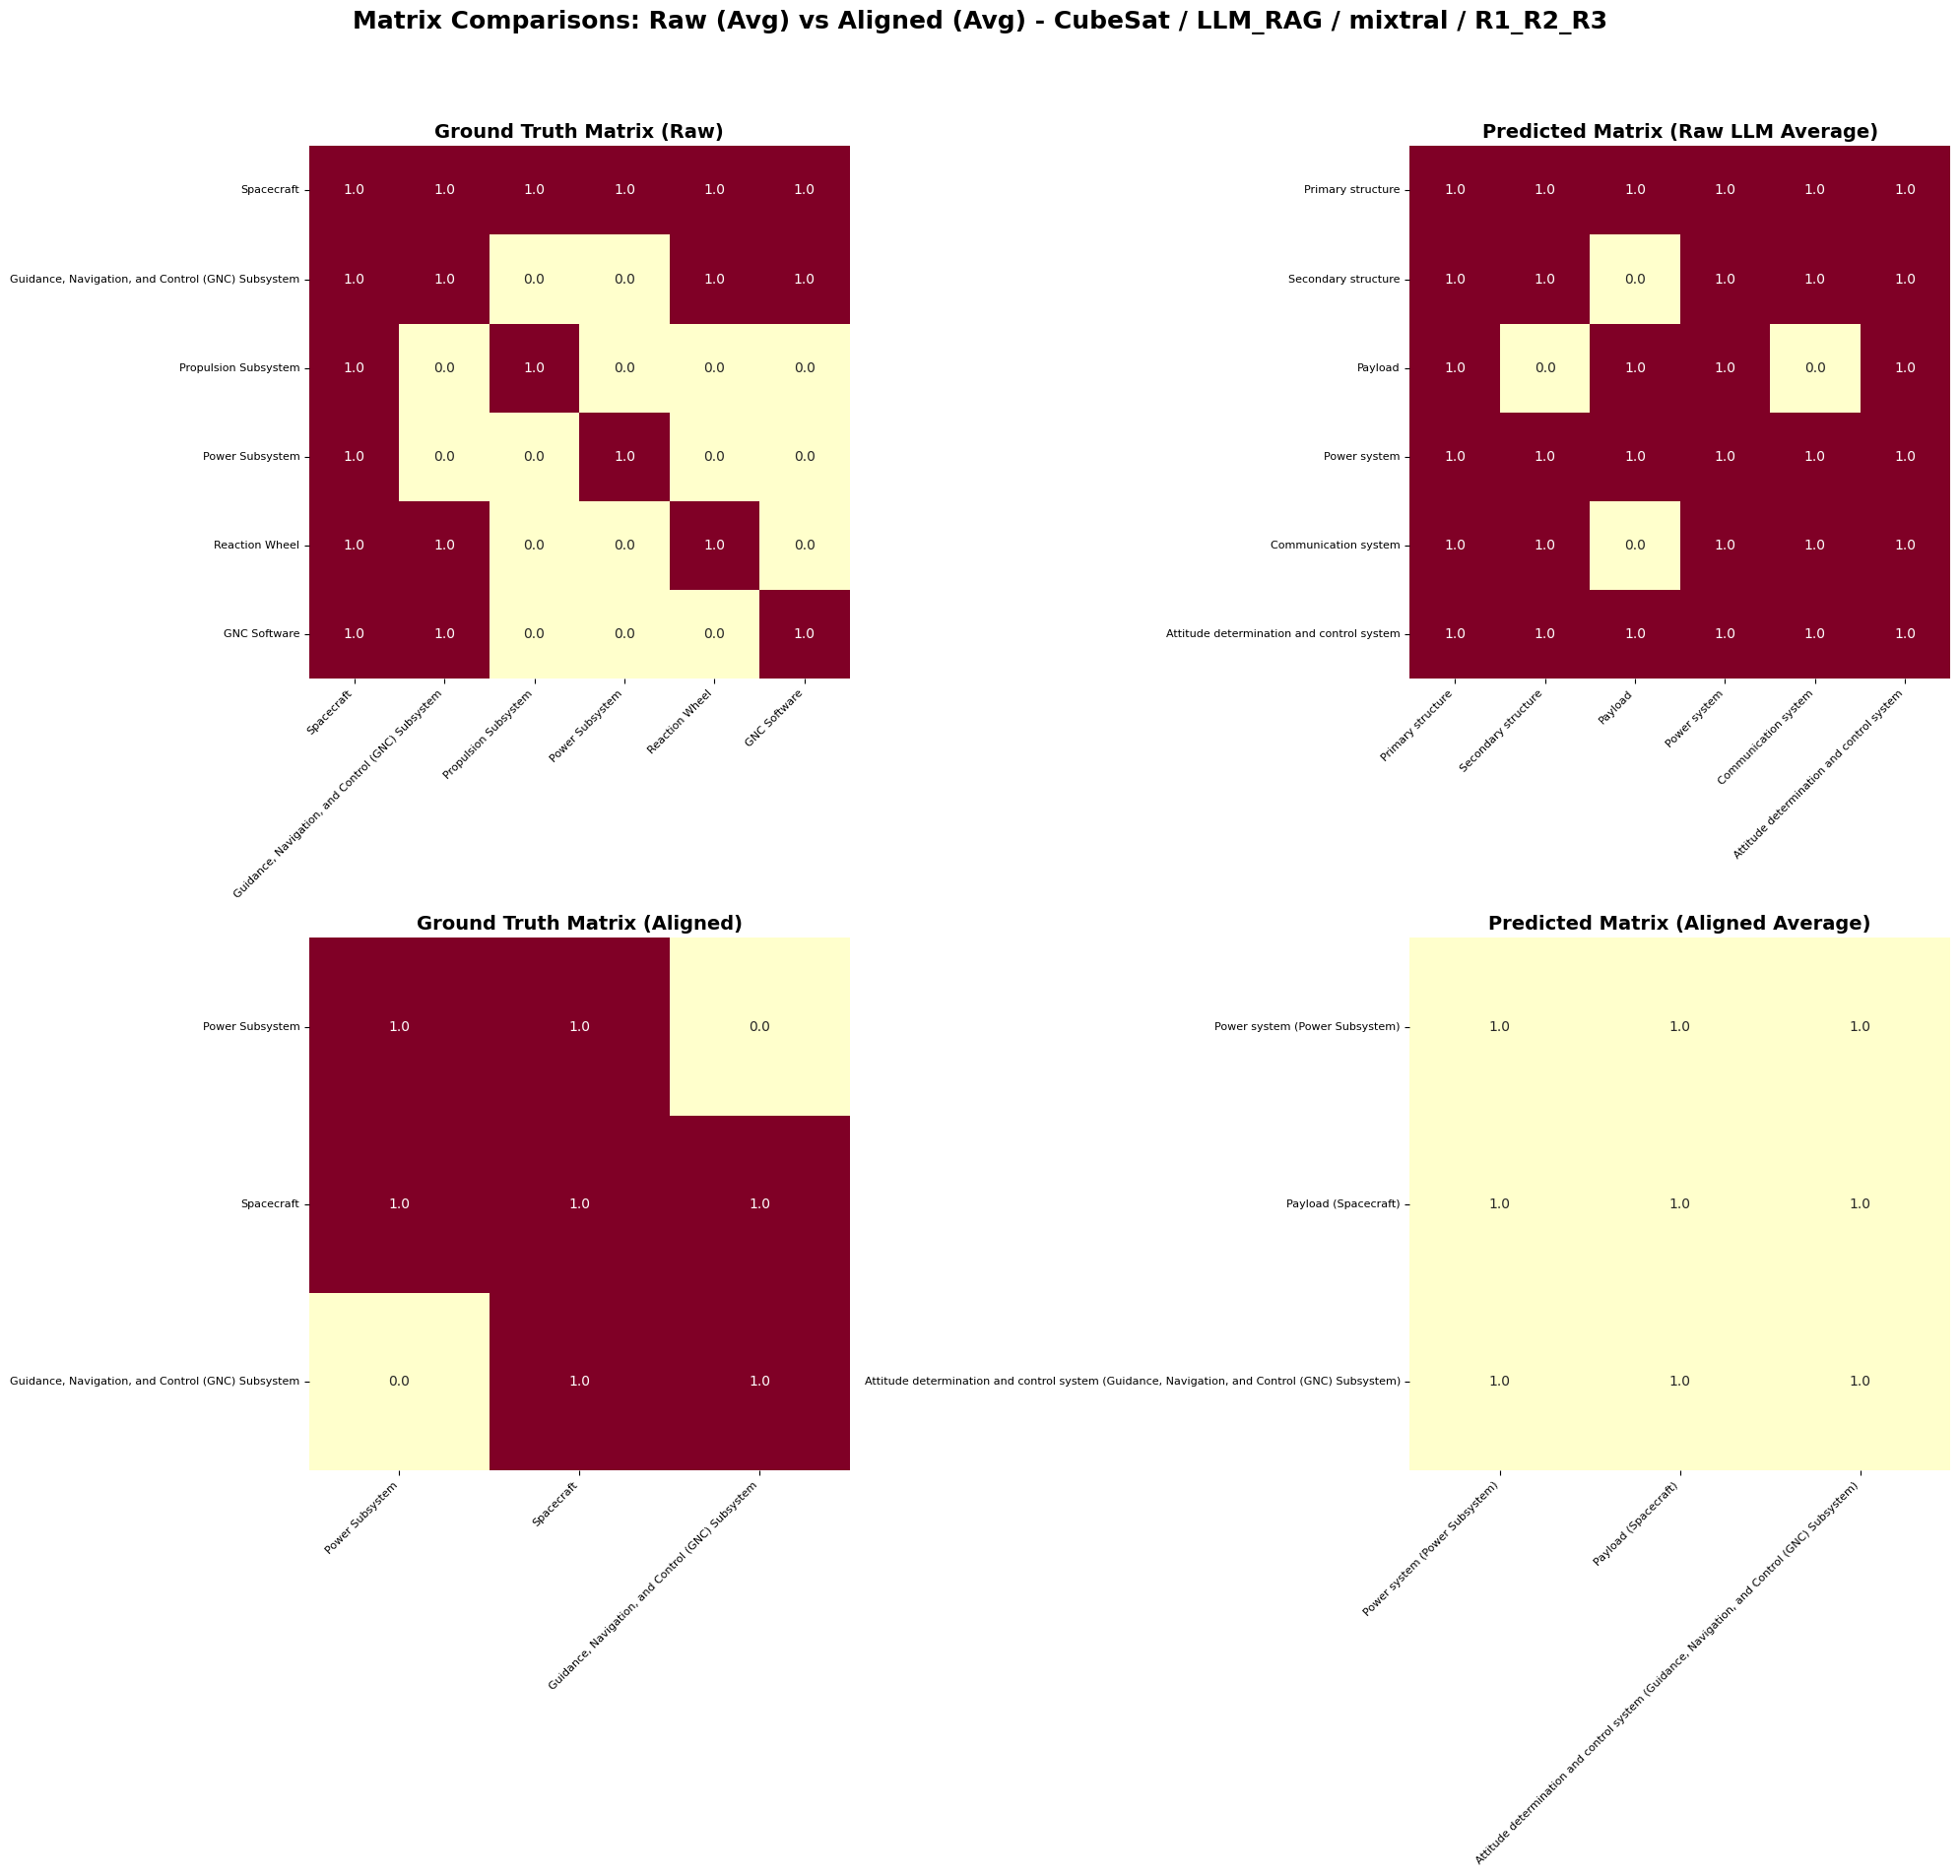

2025-04-12 23:30:42,959 - DSM_None_None_ - INFO - Plots generated and saved.
2025-04-12 23:30:42,961 - DSM_None_None_ - INFO - 
--- Results Summary for ollama:mixtral:8x22b-6k (R1_R2_R3) ---
2025-04-12 23:30:42,962 - DSM_None_None_ - INFO - 
Raw Metrics (Mean ± StdDev):
2025-04-12 23:30:42,962 - DSM_None_None_ - INFO -   accuracy: 0.6667 ± 0.0000
2025-04-12 23:30:42,963 - DSM_None_None_ - INFO -   precision: 0.6250 ± 0.0000
2025-04-12 23:30:42,964 - DSM_None_None_ - INFO -   recall: 1.0000 ± 0.0000
2025-04-12 23:30:42,965 - DSM_None_None_ - INFO -   f1_score: 0.7692 ± 0.0000
2025-04-12 23:30:42,965 - DSM_None_None_ - INFO -   edit_distance: 12.0000 ± 0.0000
2025-04-12 23:30:42,966 - DSM_None_None_ - INFO -   spectral_distance: 2.1876 ± 0.0000
2025-04-12 23:30:42,967 - DSM_None_None_ - INFO - 
Aligned Metrics (Mean ± StdDev):
2025-04-12 23:30:42,968 - DSM_None_None_ - INFO -   accuracy: 0.7778 ± 0.0000
2025-04-12 23:30:42,968 - DSM_None_None_ - INFO -   precision: 0.7778 ± 0.0000
2025-0

Logger closed for ollama:mixtral:8x22b-6k (R1_R2_R3).

---> [FIND_LATEST] Processing: powerscrewdriver / ollama:mixtral:8x22b-6k / R1
---> [FIND_LATEST] CSV Path Template: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_{timestamp}/llm_rag_refs_R1/average_matrix_{timestamp}.csv
---> [FIND_LATEST] Searching Exp Dirs: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_*
---> [FIND_LATEST] Checking if parent directory exists: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG
---> [FIND_LATEST] Parent directory exists!
---> [FIND_LATEST] Found Exp Dirs (sorted): ['xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356', 'xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250219-014540']
---> [FIND_LATEST] Latest Exp Dir: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3

2025-04-12 23:31:04,592 - DSM_None_None_ - INFO - Running Analysis For:
2025-04-12 23:31:04,593 - DSM_None_None_ - INFO -   Product: powerscrewdriver
2025-04-12 23:31:04,593 - DSM_None_None_ - INFO -   Model: ollama:mixtral:8x22b-6k
2025-04-12 23:31:04,594 - DSM_None_None_ - INFO -   Type: LLM_RAG
2025-04-12 23:31:04,595 - DSM_None_None_ - INFO -   Reference: R1
2025-04-12 23:31:04,596 - DSM_None_None_ - INFO -   Relationship: whole-part
2025-04-12 23:31:04,598 - DSM_None_None_ - INFO -   Ground Truth Path: xLM_DSM_wip/logs/Process/gt_powerscrewdriver.csv
2025-04-12 23:31:04,599 - DSM_None_None_ - INFO -   Avg Pred Path: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1/average_matrix_20250220-065356.csv
2025-04-12 23:31:04,600 - DSM_None_None_ - INFO -   Indiv JSON Path: Not Found
2025-04-12 23:31:04,605 - DSM_None_None_ - WARNING - Individual matrices JSON file not found/specified.
2025-04-12 23:31:04,

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 49
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 49
Shape of y_true_filtered: (49,)
Shape of y_pred_filtered: (49,)
First 49 y_true_filtered: [1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1.
 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1.
 1.]
First 49 y_pred_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 1.
 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0.
 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[4, 11], [16, 18]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (4, 11, 16, 18)
Manual Check - TP: 18, FP: 11, FN: 16, TN: 4
Calculated Accuracy: 0.4490  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.6207 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.5294    [Formula: TP/(

2025-04-12 23:31:05,330 - DSM_None_None_ - INFO - Attempting Component Mapping based on Average Matrix...
2025-04-12 23:31:05,330 - DSM_None_None_ - INFO - Starting get_best_component_matches function
2025-04-12 23:31:05,331 - DSM_None_None_ - INFO - Extracting model from path: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1/average_matrix_20250220-065356.csv
2025-04-12 23:31:05,332 - DSM_None_None_ - INFO - Extracted model: mixtral:8x22b-6k
2025-04-12 23:31:05,338 - DSM_None_None_ - INFO - Automatic high-similarity match: Motor -> Motor (similarity: 1.000)
2025-04-12 23:31:05,344 - DSM_None_None_ - INFO - Automatic high-similarity match: Housing -> Housing (similarity: 1.000)
2025-04-12 23:31:05,356 - DSM_None_None_ - INFO - Prompt: 
You are an expert matching engine for cyber-physical system systems. Your task is to determine the optimal one-to-one mapping between remaining ground truth and predicted

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 25
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 25
Shape of y_true_filtered: (25,)
Shape of y_pred_filtered: (25,)
First 25 y_true_filtered: [1. 1. 0. 1. 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1.
 1.]
First 25 y_pred_filtered: [1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 0.
 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[4, 3], [2, 16]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (4, 3, 2, 16)
Manual Check - TP: 16, FP: 3, FN: 2, TN: 4
Calculated Accuracy: 0.8000  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.8421 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.8889    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.8649  [Formula: 2*(Prec*Rec)/(Prec+Rec)]
--- End Debugging ---


2025-04-12 23:32:05,351 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1/plots/performance_metrics_with_stddev.png


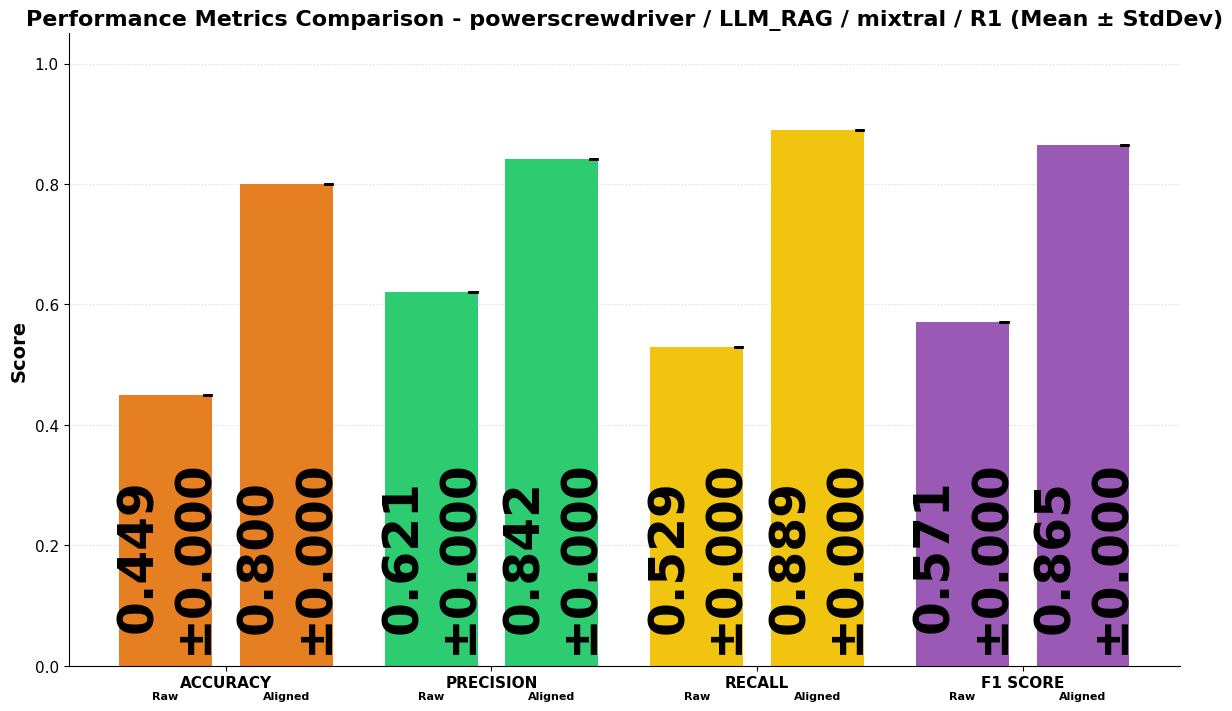

2025-04-12 23:32:05,474 - DSM_None_None_ - INFO - Plotting distance metrics...
2025-04-12 23:32:05,929 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1/plots/distance_metrics_with_stddev.png


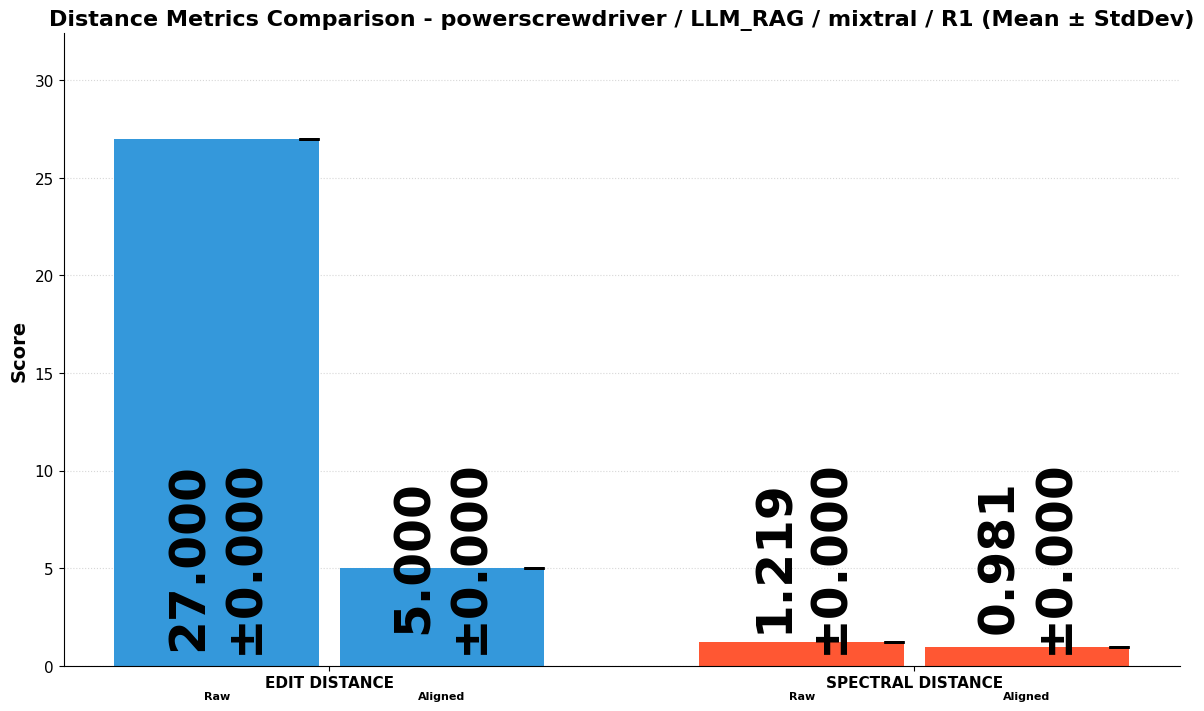

2025-04-12 23:32:06,030 - DSM_None_None_ - INFO - Plotting matrix comparison...
2025-04-12 23:32:08,162 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1/plots/matrices_comparison_avg.png


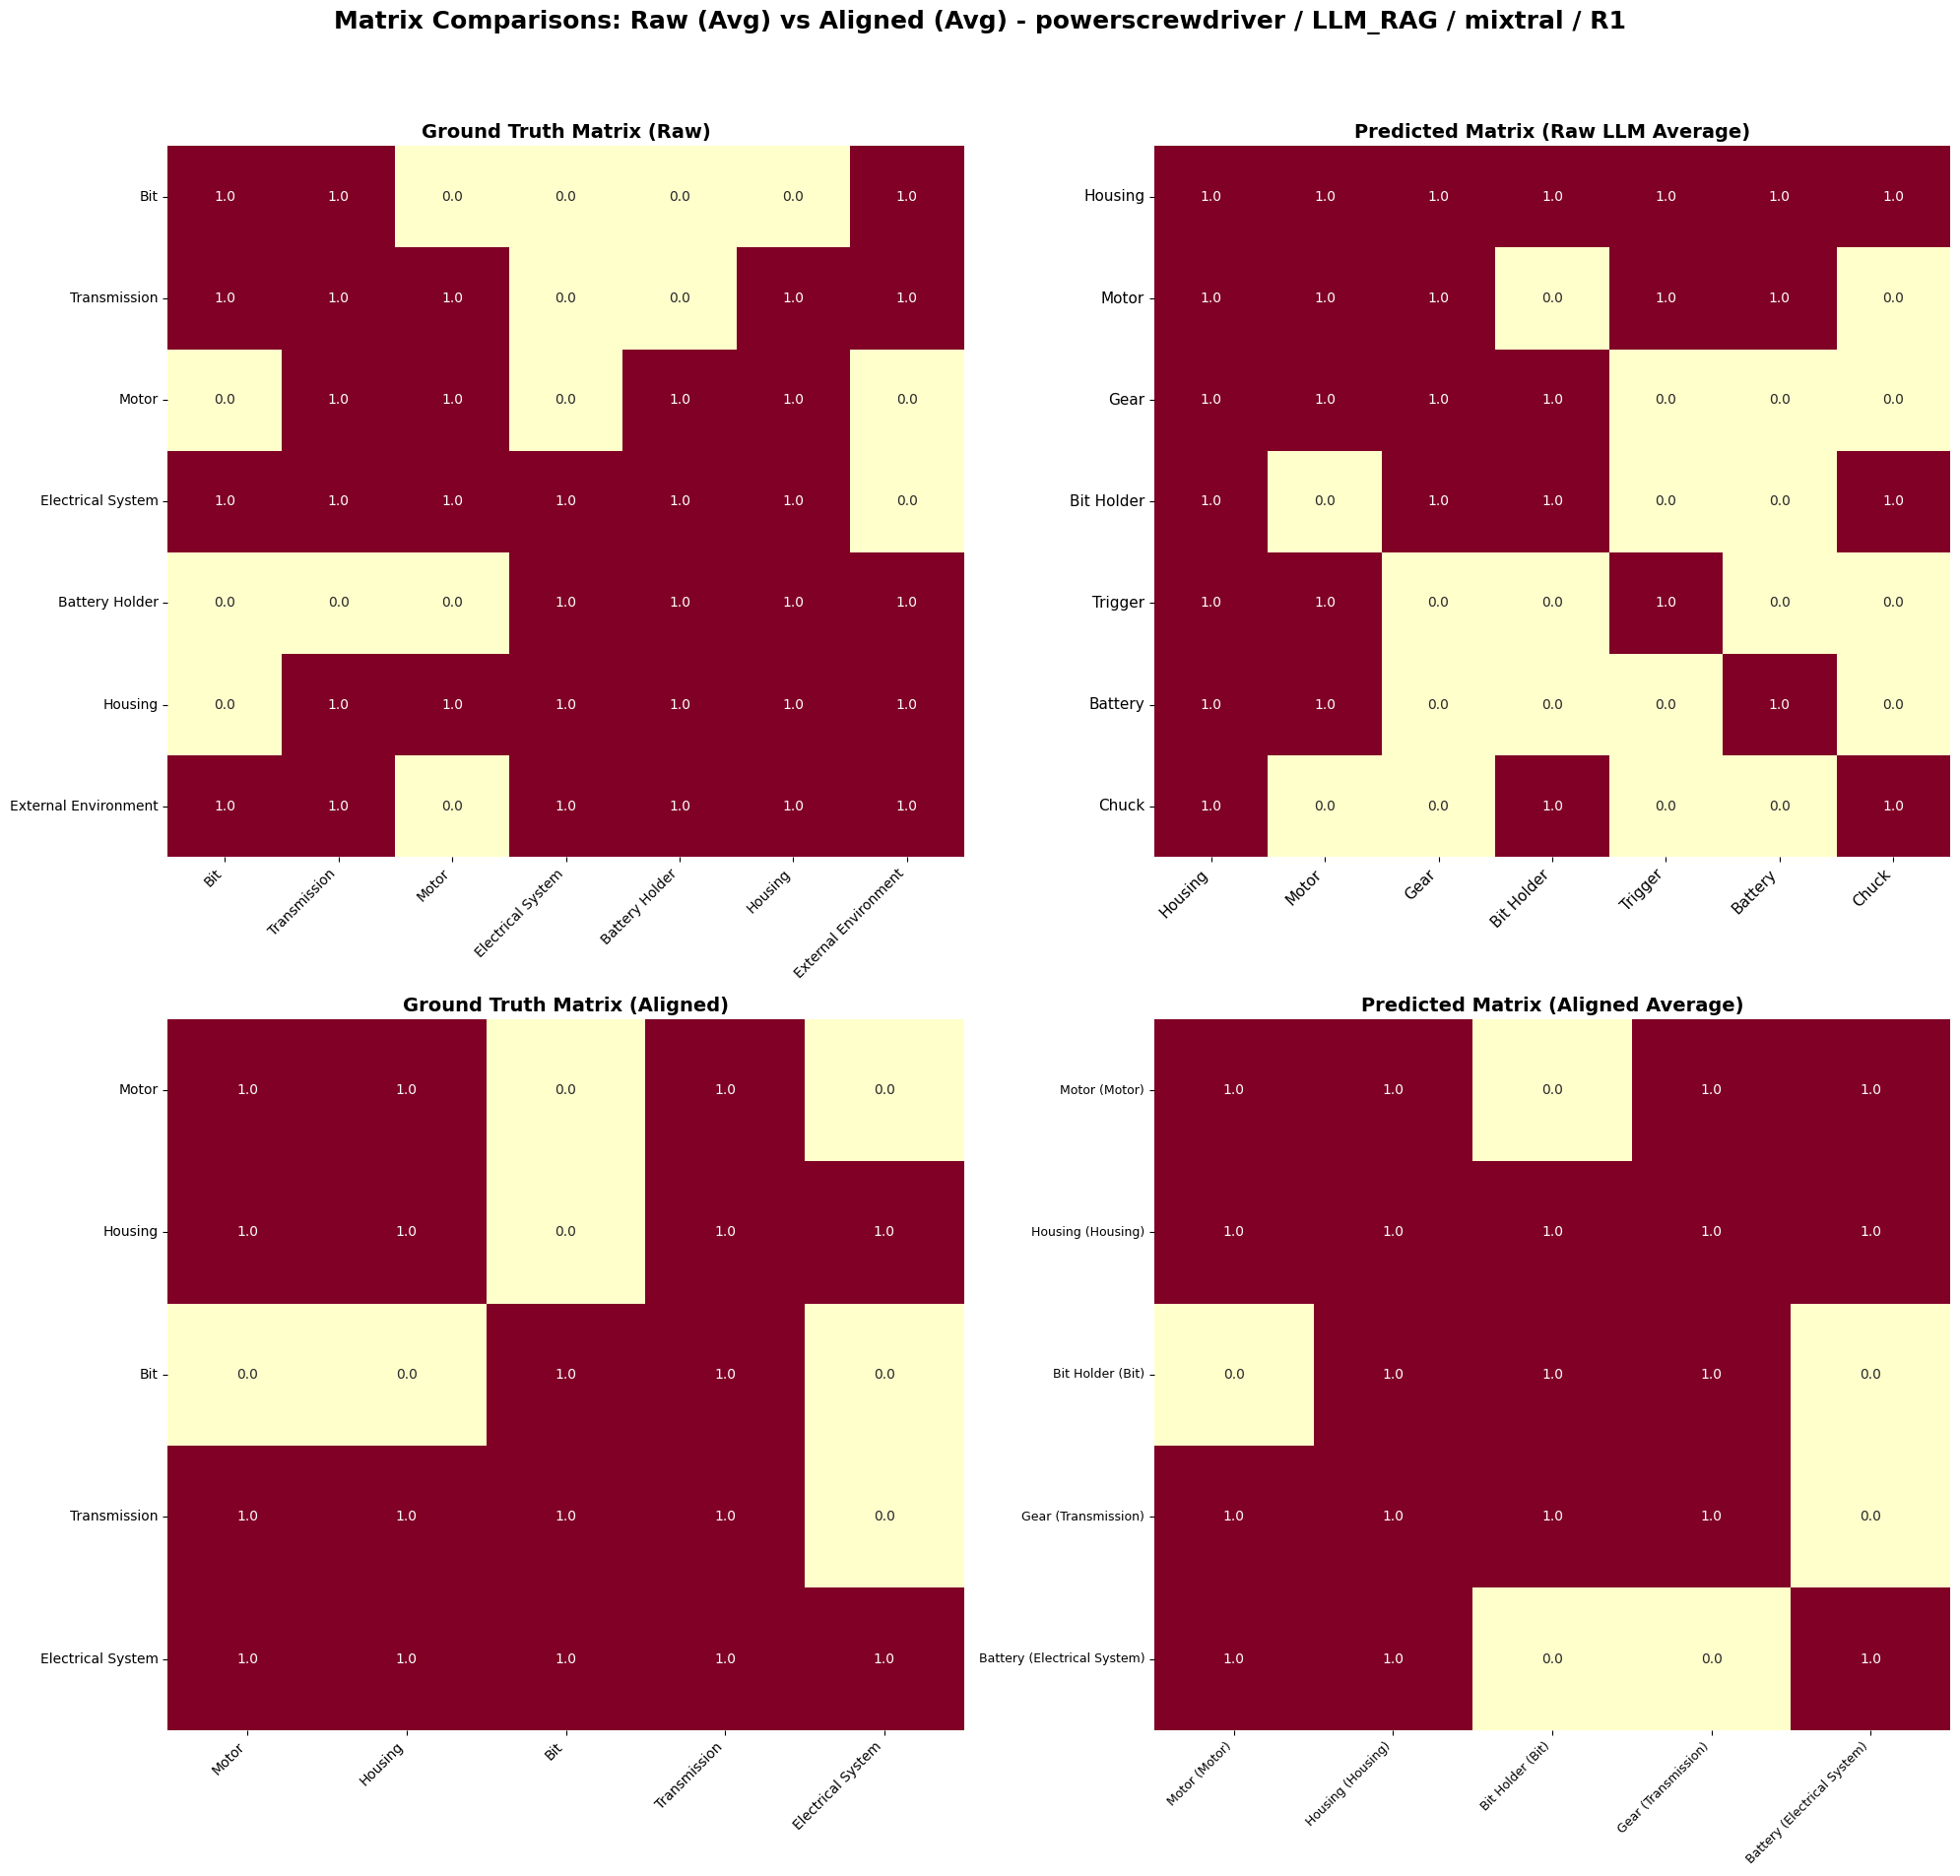

2025-04-12 23:32:08,571 - DSM_None_None_ - INFO - Plots generated and saved.
2025-04-12 23:32:08,572 - DSM_None_None_ - INFO - 
--- Results Summary for ollama:mixtral:8x22b-6k (R1) ---
2025-04-12 23:32:08,572 - DSM_None_None_ - INFO - 
Raw Metrics (Mean ± StdDev):
2025-04-12 23:32:08,573 - DSM_None_None_ - INFO -   accuracy: 0.4490 ± 0.0000
2025-04-12 23:32:08,574 - DSM_None_None_ - INFO -   precision: 0.6207 ± 0.0000
2025-04-12 23:32:08,574 - DSM_None_None_ - INFO -   recall: 0.5294 ± 0.0000
2025-04-12 23:32:08,576 - DSM_None_None_ - INFO -   f1_score: 0.5714 ± 0.0000
2025-04-12 23:32:08,576 - DSM_None_None_ - INFO -   edit_distance: 27.0000 ± 0.0000
2025-04-12 23:32:08,577 - DSM_None_None_ - INFO -   spectral_distance: 1.2193 ± 0.0000
2025-04-12 23:32:08,578 - DSM_None_None_ - INFO - 
Aligned Metrics (Mean ± StdDev):
2025-04-12 23:32:08,578 - DSM_None_None_ - INFO -   accuracy: 0.8000 ± 0.0000
2025-04-12 23:32:08,579 - DSM_None_None_ - INFO -   precision: 0.8421 ± 0.0000
2025-04-12 2

Logger closed for ollama:mixtral:8x22b-6k (R1).

---> [FIND_LATEST] Processing: powerscrewdriver / ollama:mixtral:8x22b-6k / R2
---> [FIND_LATEST] CSV Path Template: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_{timestamp}/llm_rag_refs_R2/average_matrix_{timestamp}.csv
---> [FIND_LATEST] Searching Exp Dirs: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_*
---> [FIND_LATEST] Checking if parent directory exists: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG
---> [FIND_LATEST] Parent directory exists!
---> [FIND_LATEST] Found Exp Dirs (sorted): ['xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356', 'xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250219-014540']
---> [FIND_LATEST] Latest Exp Dir: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_

2025-04-12 23:32:30,305 - DSM_None_None_ - INFO - Running Analysis For:
2025-04-12 23:32:30,306 - DSM_None_None_ - INFO -   Product: powerscrewdriver
2025-04-12 23:32:30,307 - DSM_None_None_ - INFO -   Model: ollama:mixtral:8x22b-6k
2025-04-12 23:32:30,308 - DSM_None_None_ - INFO -   Type: LLM_RAG
2025-04-12 23:32:30,309 - DSM_None_None_ - INFO -   Reference: R2
2025-04-12 23:32:30,310 - DSM_None_None_ - INFO -   Relationship: whole-part
2025-04-12 23:32:30,311 - DSM_None_None_ - INFO -   Ground Truth Path: xLM_DSM_wip/logs/Process/gt_powerscrewdriver.csv
2025-04-12 23:32:30,312 - DSM_None_None_ - INFO -   Avg Pred Path: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R2/average_matrix_20250220-065356.csv
2025-04-12 23:32:30,313 - DSM_None_None_ - INFO -   Indiv JSON Path: Not Found
2025-04-12 23:32:30,319 - DSM_None_None_ - WARNING - Individual matrices JSON file not found/specified.
2025-04-12 23:32:30,

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 49
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 49
Shape of y_true_filtered: (49,)
Shape of y_pred_filtered: (49,)
First 49 y_true_filtered: [1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1.
 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1.
 1.]
First 49 y_pred_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1.
 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0.
 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[1, 14], [15, 19]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (1, 14, 15, 19)
Manual Check - TP: 19, FP: 14, FN: 15, TN: 1
Calculated Accuracy: 0.4082  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.5758 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.5588    [Formula: TP/(

2025-04-12 23:32:31,611 - DSM_None_None_ - INFO - Attempting Component Mapping based on Average Matrix...
2025-04-12 23:32:31,612 - DSM_None_None_ - INFO - Starting get_best_component_matches function
2025-04-12 23:32:31,613 - DSM_None_None_ - INFO - Extracting model from path: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R2/average_matrix_20250220-065356.csv
2025-04-12 23:32:31,613 - DSM_None_None_ - INFO - Extracted model: mixtral:8x22b-6k
2025-04-12 23:32:31,619 - DSM_None_None_ - INFO - Automatic high-similarity match: Motor -> Motor (similarity: 1.000)
2025-04-12 23:32:31,626 - DSM_None_None_ - INFO - Automatic high-similarity match: Housing -> Housing (similarity: 1.000)
2025-04-12 23:32:31,638 - DSM_None_None_ - INFO - Prompt: 
You are an expert matching engine for cyber-physical system systems. Your task is to determine the optimal one-to-one mapping between remaining ground truth and predicted

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 25
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 25
Shape of y_true_filtered: (25,)
Shape of y_pred_filtered: (25,)
First 25 y_true_filtered: [1. 1. 0. 1. 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1.
 1.]
First 25 y_pred_filtered: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 0.
 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[2, 5], [2, 16]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (2, 5, 2, 16)
Manual Check - TP: 16, FP: 5, FN: 2, TN: 2
Calculated Accuracy: 0.7200  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.7619 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.8889    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.8205  [Formula: 2*(Prec*Rec)/(Prec+Rec)]
--- End Debugging ---


2025-04-12 23:33:45,119 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R2/plots/performance_metrics_with_stddev.png


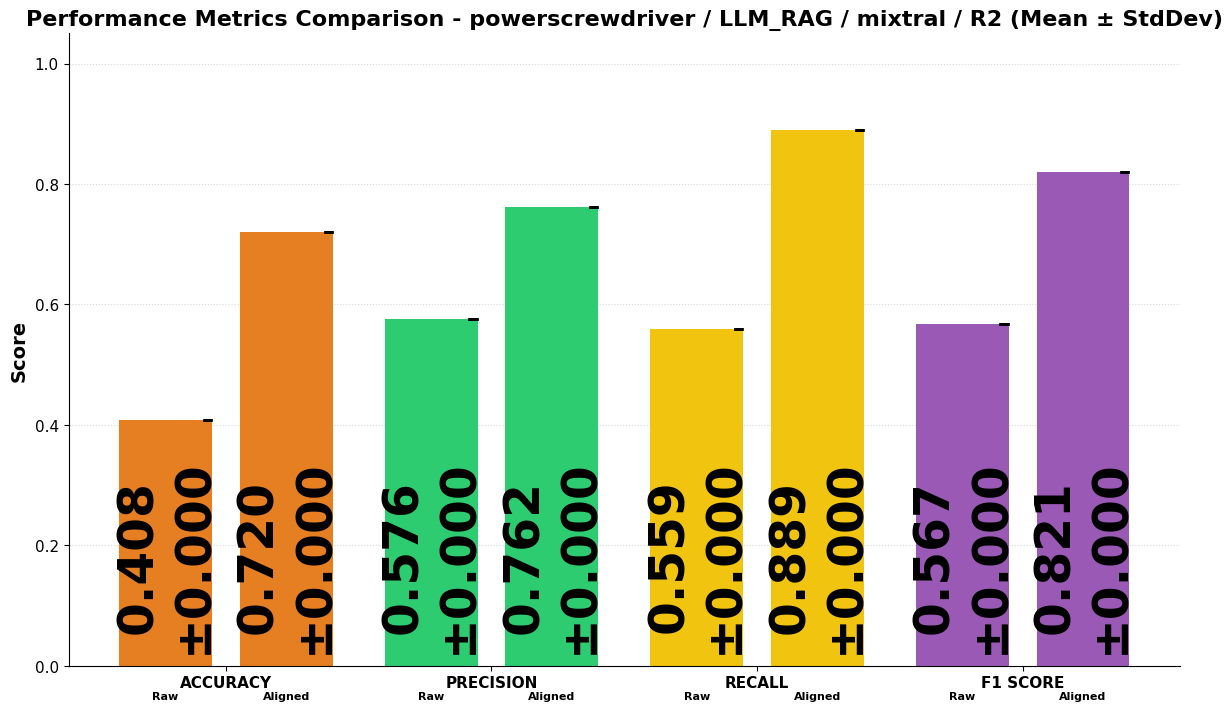

2025-04-12 23:33:45,239 - DSM_None_None_ - INFO - Plotting distance metrics...
2025-04-12 23:33:45,682 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R2/plots/distance_metrics_with_stddev.png


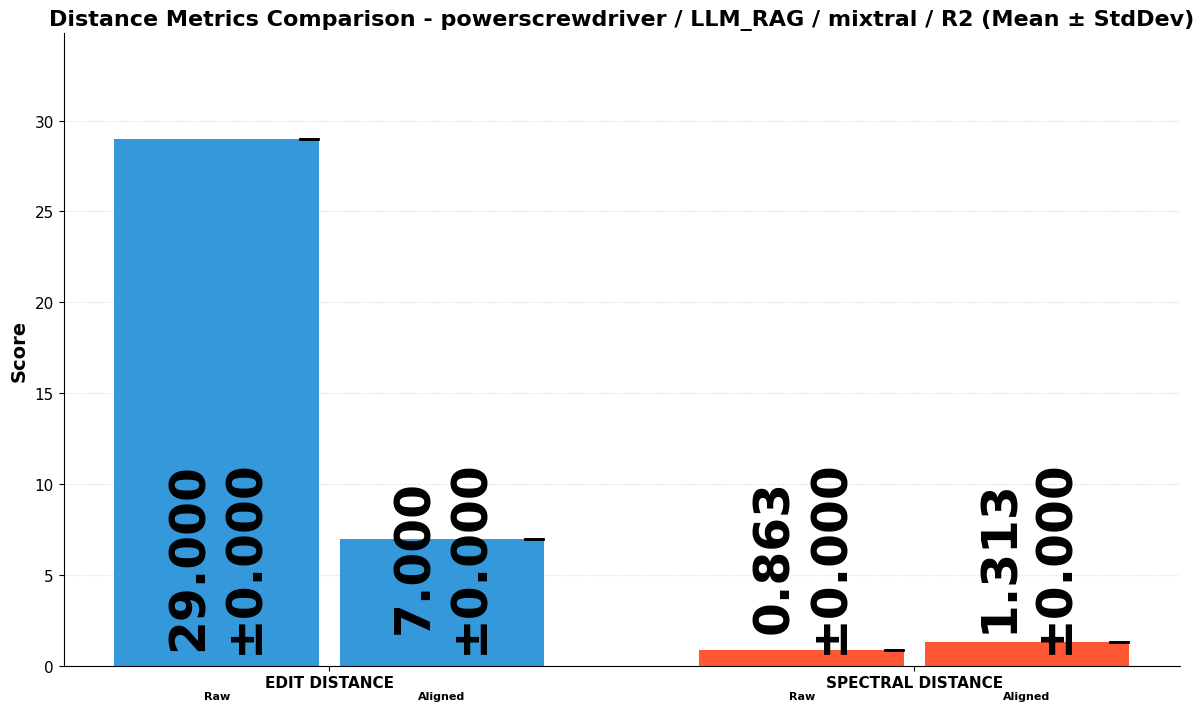

2025-04-12 23:33:45,792 - DSM_None_None_ - INFO - Plotting matrix comparison...
2025-04-12 23:33:48,109 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R2/plots/matrices_comparison_avg.png


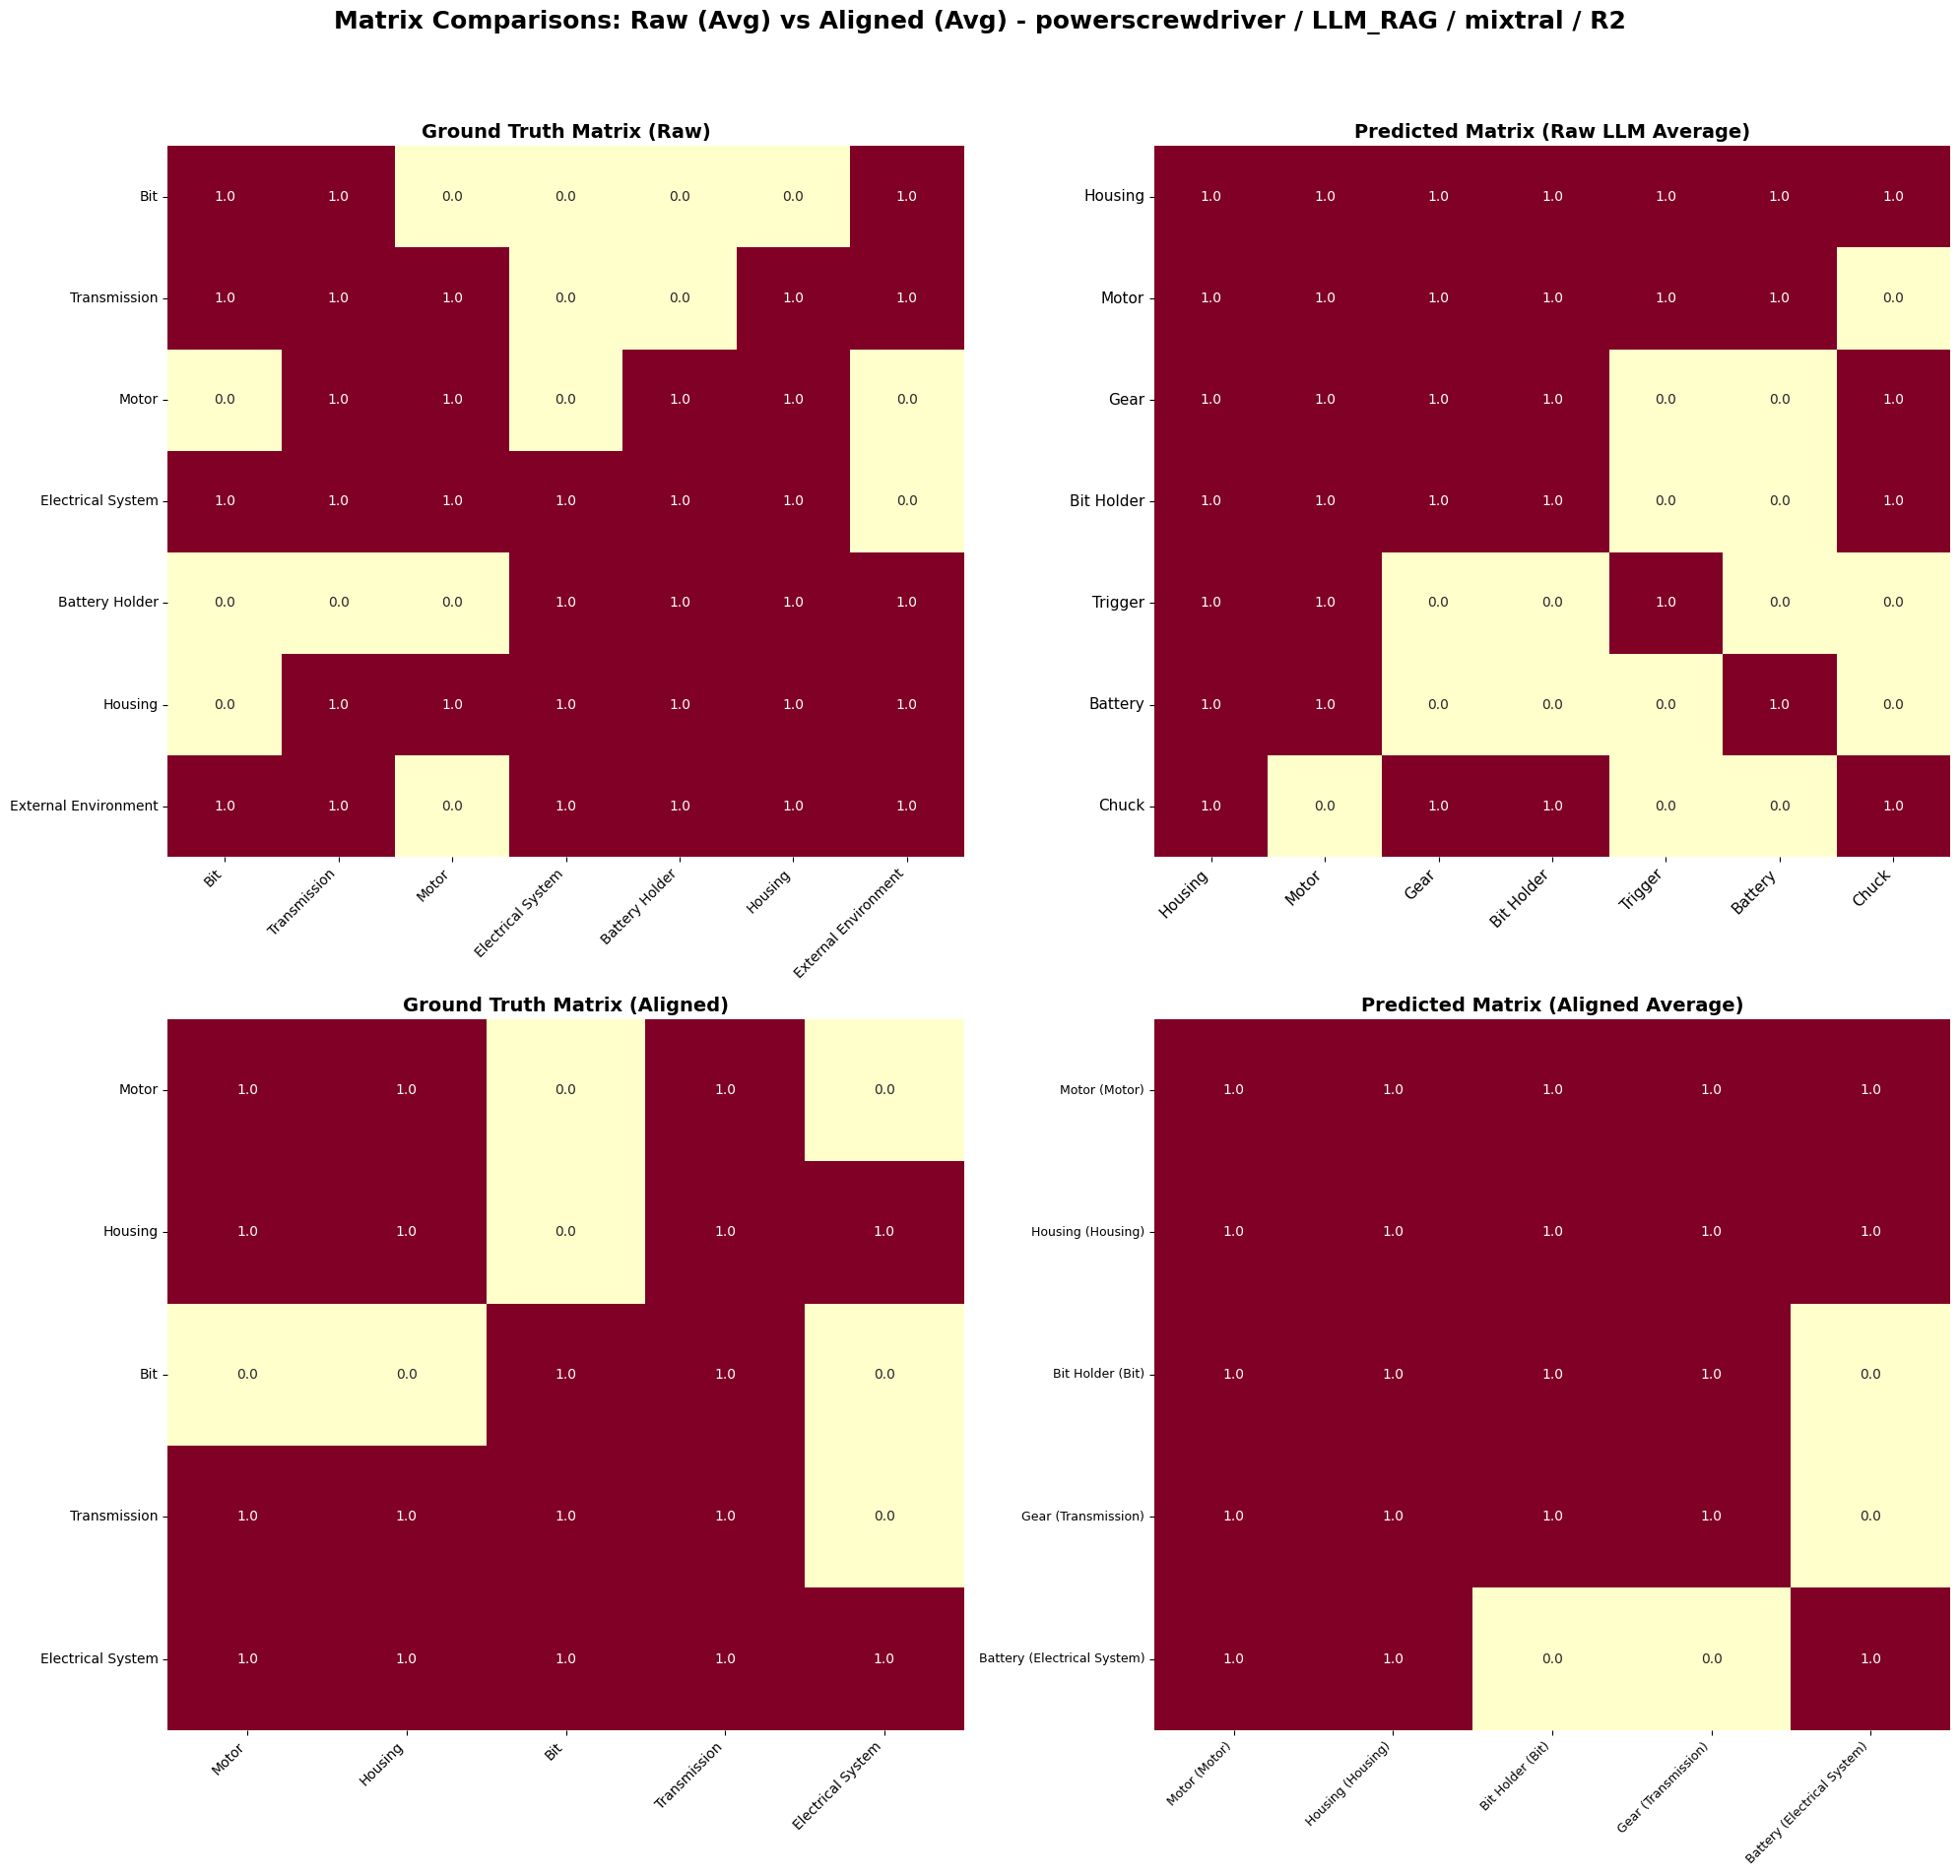

2025-04-12 23:33:48,499 - DSM_None_None_ - INFO - Plots generated and saved.
2025-04-12 23:33:48,500 - DSM_None_None_ - INFO - 
--- Results Summary for ollama:mixtral:8x22b-6k (R2) ---
2025-04-12 23:33:48,501 - DSM_None_None_ - INFO - 
Raw Metrics (Mean ± StdDev):
2025-04-12 23:33:48,501 - DSM_None_None_ - INFO -   accuracy: 0.4082 ± 0.0000
2025-04-12 23:33:48,502 - DSM_None_None_ - INFO -   precision: 0.5758 ± 0.0000
2025-04-12 23:33:48,503 - DSM_None_None_ - INFO -   recall: 0.5588 ± 0.0000
2025-04-12 23:33:48,503 - DSM_None_None_ - INFO -   f1_score: 0.5672 ± 0.0000
2025-04-12 23:33:48,504 - DSM_None_None_ - INFO -   edit_distance: 29.0000 ± 0.0000
2025-04-12 23:33:48,504 - DSM_None_None_ - INFO -   spectral_distance: 0.8632 ± 0.0000
2025-04-12 23:33:48,505 - DSM_None_None_ - INFO - 
Aligned Metrics (Mean ± StdDev):
2025-04-12 23:33:48,506 - DSM_None_None_ - INFO -   accuracy: 0.7200 ± 0.0000
2025-04-12 23:33:48,506 - DSM_None_None_ - INFO -   precision: 0.7619 ± 0.0000
2025-04-12 2

Logger closed for ollama:mixtral:8x22b-6k (R2).

---> [FIND_LATEST] Processing: powerscrewdriver / ollama:mixtral:8x22b-6k / R3
---> [FIND_LATEST] CSV Path Template: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_{timestamp}/llm_rag_refs_R3/average_matrix_{timestamp}.csv
---> [FIND_LATEST] Searching Exp Dirs: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_*
---> [FIND_LATEST] Checking if parent directory exists: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG
---> [FIND_LATEST] Parent directory exists!
---> [FIND_LATEST] Found Exp Dirs (sorted): ['xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356', 'xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250219-014540']
---> [FIND_LATEST] Latest Exp Dir: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_

2025-04-12 23:34:10,209 - DSM_None_None_ - INFO - Running Analysis For:
2025-04-12 23:34:10,210 - DSM_None_None_ - INFO -   Product: powerscrewdriver
2025-04-12 23:34:10,211 - DSM_None_None_ - INFO -   Model: ollama:mixtral:8x22b-6k
2025-04-12 23:34:10,211 - DSM_None_None_ - INFO -   Type: LLM_RAG
2025-04-12 23:34:10,212 - DSM_None_None_ - INFO -   Reference: R3
2025-04-12 23:34:10,213 - DSM_None_None_ - INFO -   Relationship: whole-part
2025-04-12 23:34:10,214 - DSM_None_None_ - INFO -   Ground Truth Path: xLM_DSM_wip/logs/Process/gt_powerscrewdriver.csv
2025-04-12 23:34:10,215 - DSM_None_None_ - INFO -   Avg Pred Path: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R3/average_matrix_20250220-065356.csv
2025-04-12 23:34:10,215 - DSM_None_None_ - INFO -   Indiv JSON Path: Not Found
2025-04-12 23:34:10,222 - DSM_None_None_ - WARNING - Individual matrices JSON file not found/specified.
2025-04-12 23:34:10,

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 49
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 49
Shape of y_true_filtered: (49,)
Shape of y_pred_filtered: (49,)
First 49 y_true_filtered: [1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1.
 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1.
 1.]
First 49 y_pred_filtered: [1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0.
 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0.
 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[10, 5], [18, 16]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (10, 5, 18, 16)
Manual Check - TP: 16, FP: 5, FN: 18, TN: 10
Calculated Accuracy: 0.5306  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.7619 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.4706    [Formula: TP/(

2025-04-12 23:34:10,933 - DSM_None_None_ - INFO - Attempting Component Mapping based on Average Matrix...
2025-04-12 23:34:10,934 - DSM_None_None_ - INFO - Starting get_best_component_matches function
2025-04-12 23:34:10,935 - DSM_None_None_ - INFO - Extracting model from path: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R3/average_matrix_20250220-065356.csv
2025-04-12 23:34:10,935 - DSM_None_None_ - INFO - Extracted model: mixtral:8x22b-6k
2025-04-12 23:34:10,940 - DSM_None_None_ - INFO - Automatic high-similarity match: Motor -> Motor (similarity: 1.000)
2025-04-12 23:34:10,961 - DSM_None_None_ - INFO - Prompt: 
You are an expert matching engine for cyber-physical system systems. Your task is to determine the optimal one-to-one mapping between remaining ground truth and predicted major components.

Remaining Ground Truth Components:
['Bit', 'Transmission', 'Electrical System', 'Battery Holder', 'Hou

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 16
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 16
Shape of y_true_filtered: (16,)
Shape of y_pred_filtered: (16,)
First 16 y_true_filtered: [1. 0. 1. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1.]
First 16 y_pred_filtered: [1. 1. 1. 1. 1. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[2, 3], [4, 7]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (2, 3, 4, 7)
Manual Check - TP: 7, FP: 3, FN: 4, TN: 2
Calculated Accuracy: 0.5625  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.7000 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.6364    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.6667  [Formula: 2*(Prec*Rec)/(Prec+Rec)]
--- End Debugging ---


2025-04-12 23:35:05,248 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R3/plots/performance_metrics_with_stddev.png


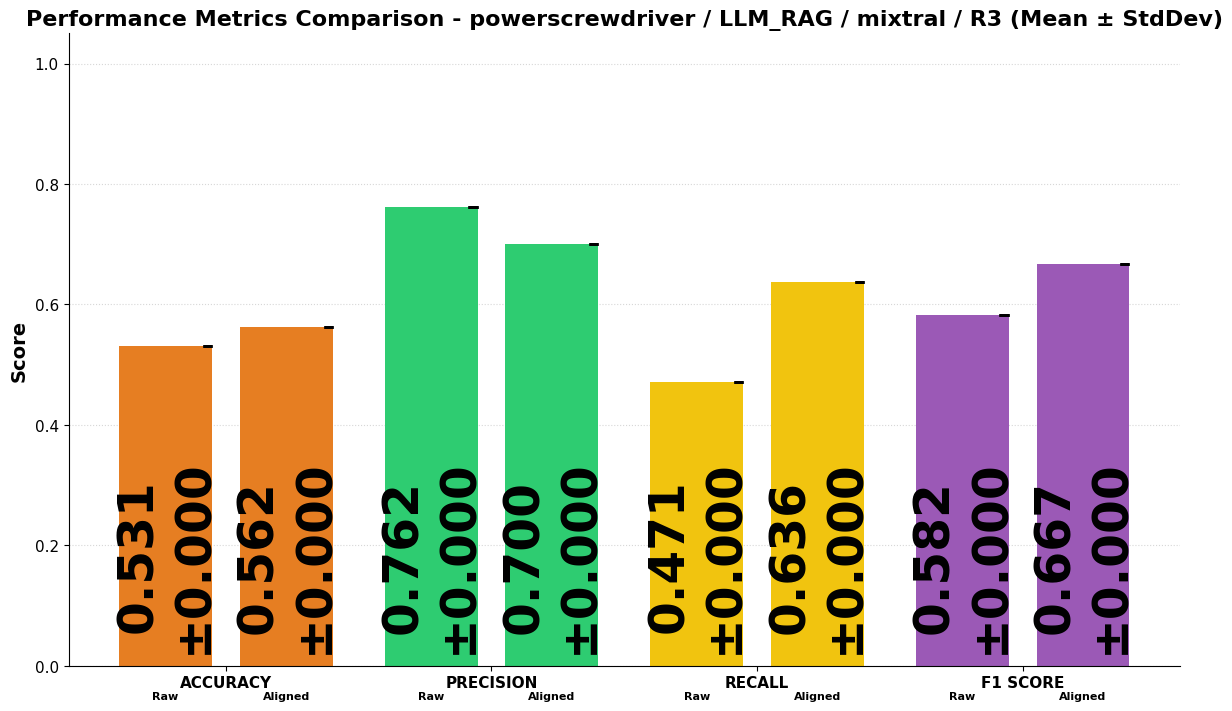

2025-04-12 23:35:05,374 - DSM_None_None_ - INFO - Plotting distance metrics...
2025-04-12 23:35:05,805 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R3/plots/distance_metrics_with_stddev.png


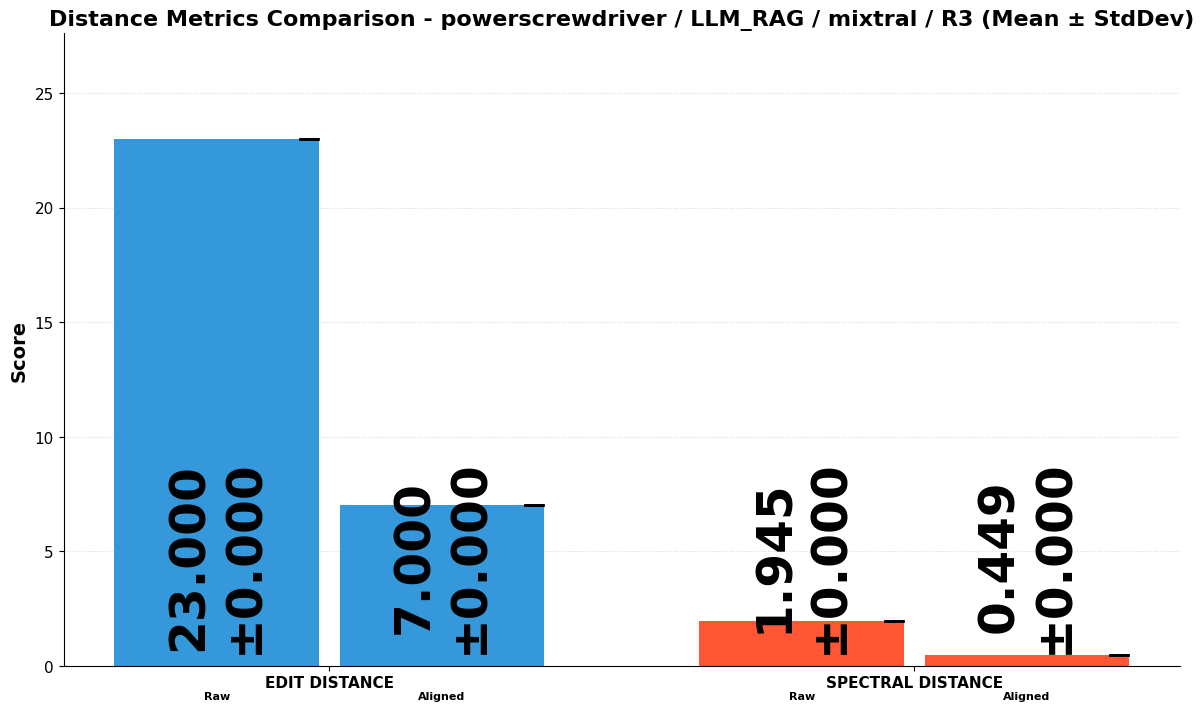

2025-04-12 23:35:05,904 - DSM_None_None_ - INFO - Plotting matrix comparison...
2025-04-12 23:35:08,003 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R3/plots/matrices_comparison_avg.png


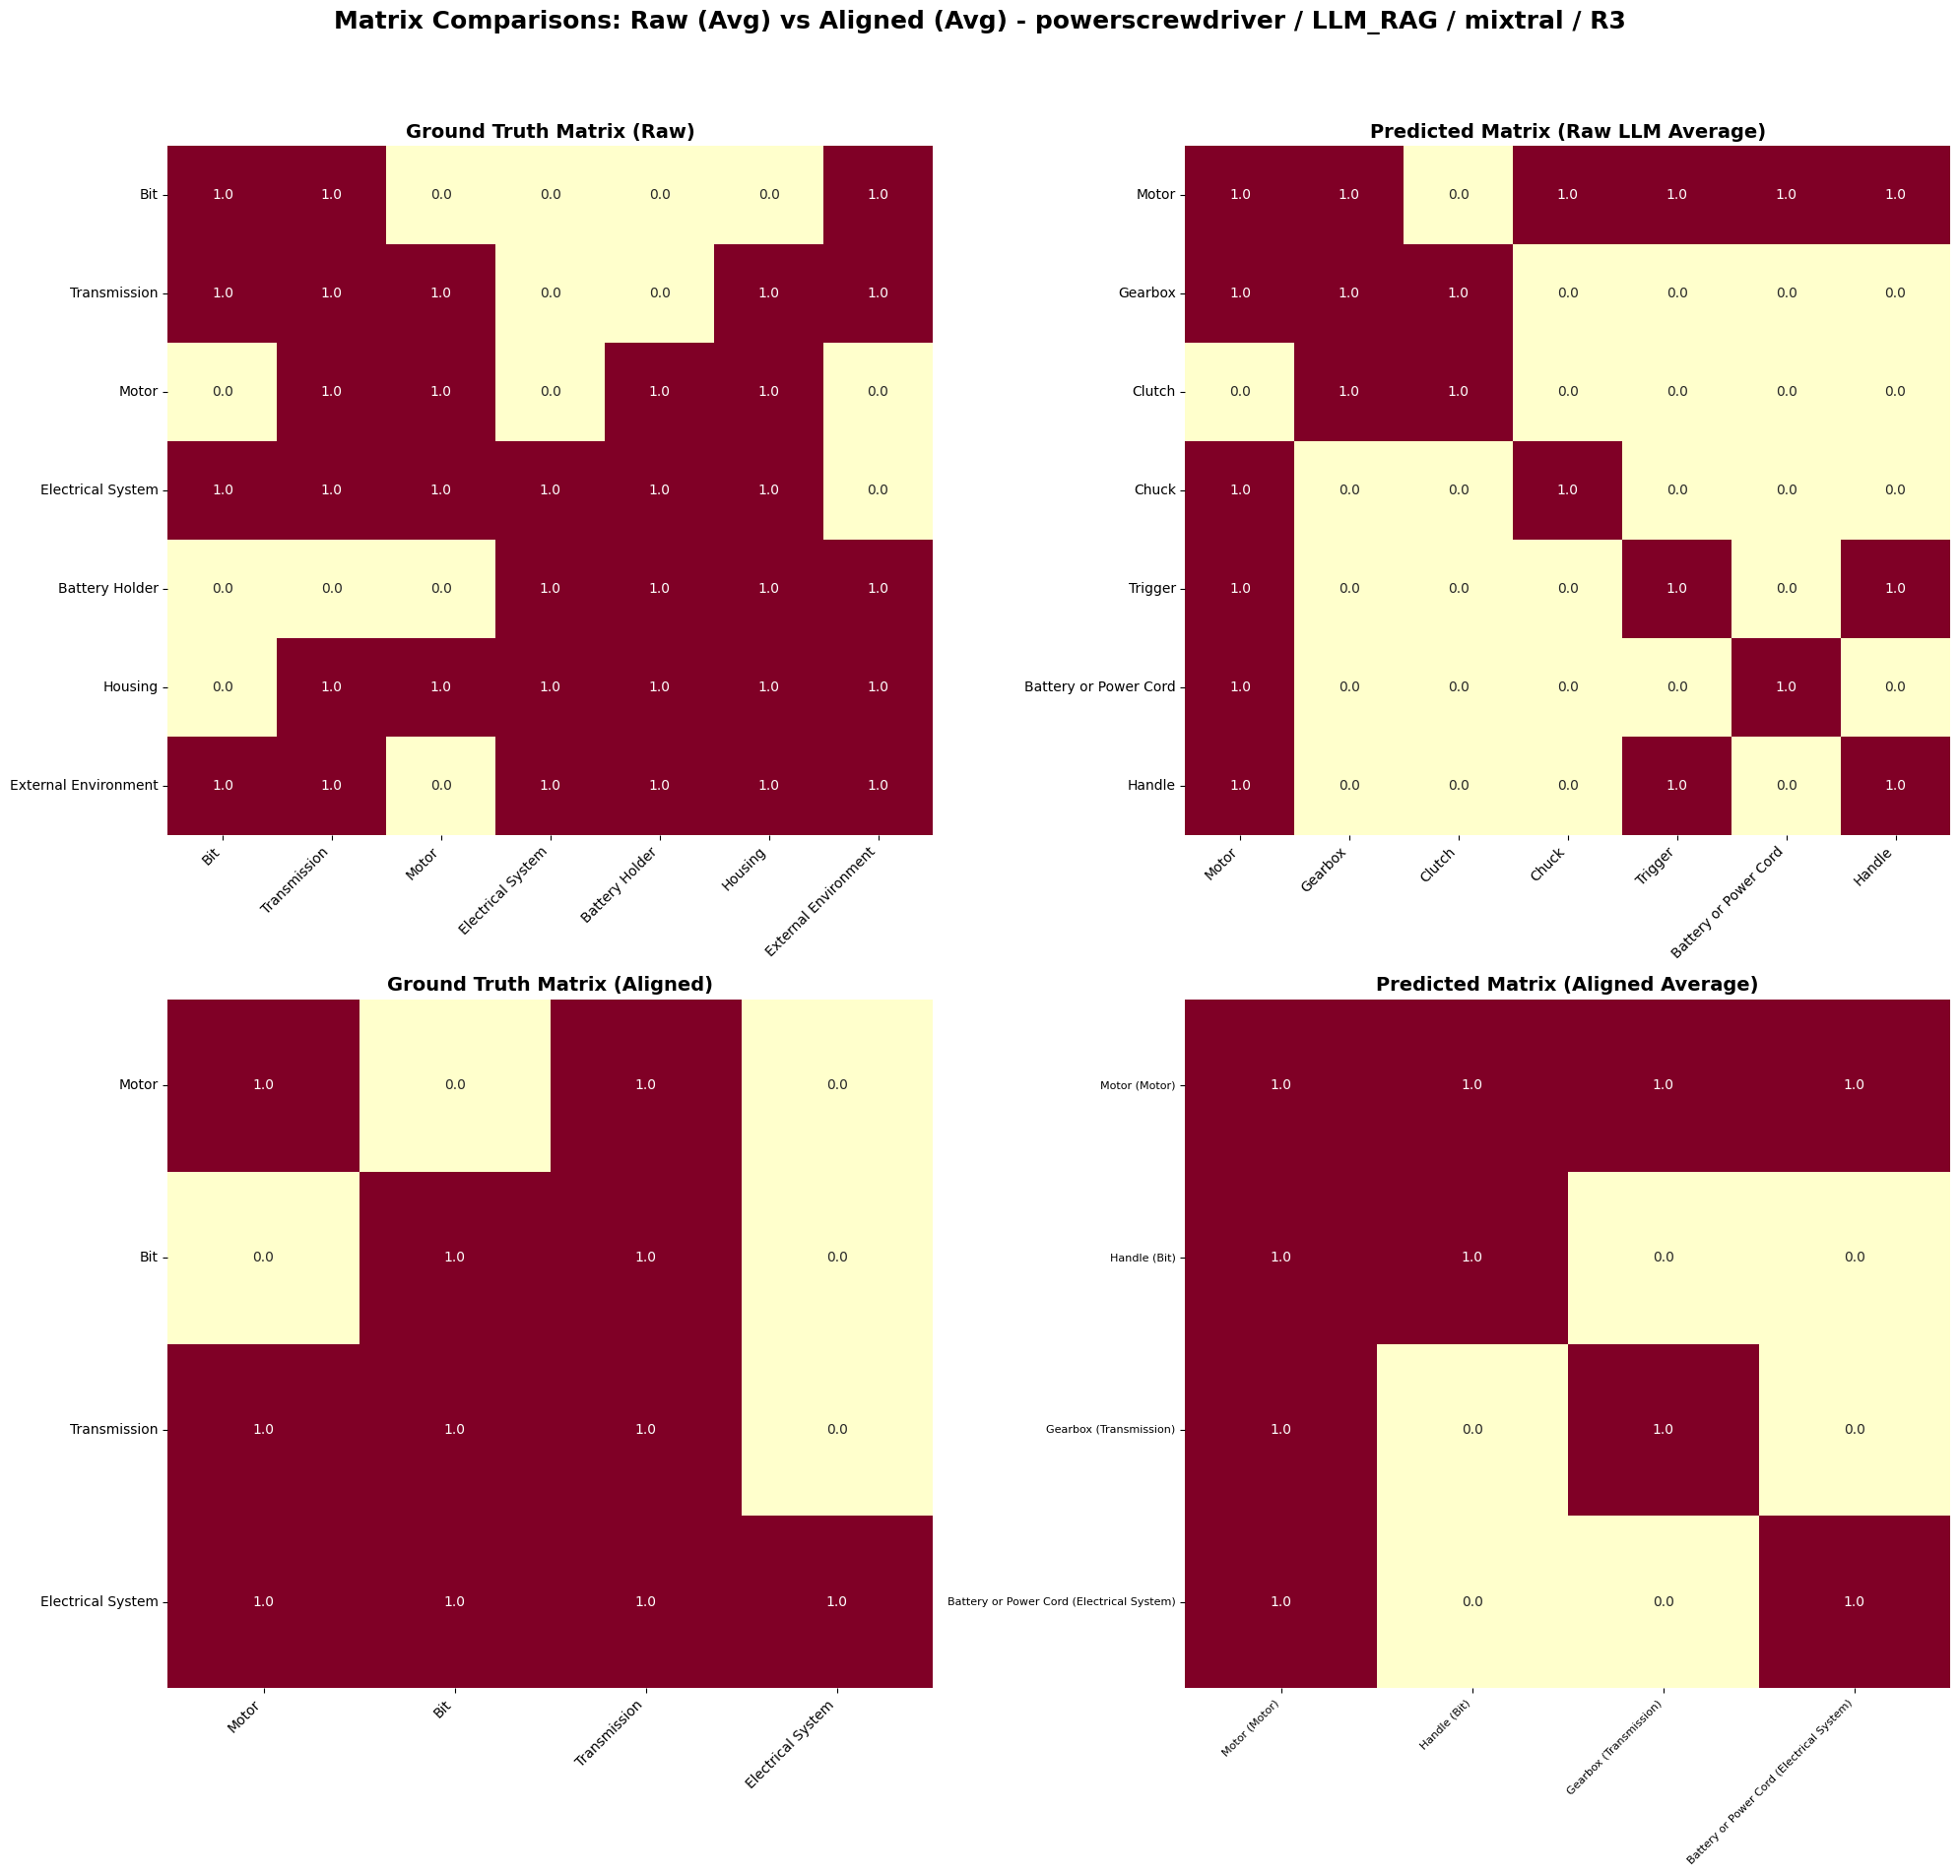

2025-04-12 23:35:08,376 - DSM_None_None_ - INFO - Plots generated and saved.
2025-04-12 23:35:08,377 - DSM_None_None_ - INFO - 
--- Results Summary for ollama:mixtral:8x22b-6k (R3) ---
2025-04-12 23:35:08,378 - DSM_None_None_ - INFO - 
Raw Metrics (Mean ± StdDev):
2025-04-12 23:35:08,379 - DSM_None_None_ - INFO -   accuracy: 0.5306 ± 0.0000
2025-04-12 23:35:08,379 - DSM_None_None_ - INFO -   precision: 0.7619 ± 0.0000
2025-04-12 23:35:08,380 - DSM_None_None_ - INFO -   recall: 0.4706 ± 0.0000
2025-04-12 23:35:08,380 - DSM_None_None_ - INFO -   f1_score: 0.5818 ± 0.0000
2025-04-12 23:35:08,381 - DSM_None_None_ - INFO -   edit_distance: 23.0000 ± 0.0000
2025-04-12 23:35:08,382 - DSM_None_None_ - INFO -   spectral_distance: 1.9449 ± 0.0000
2025-04-12 23:35:08,382 - DSM_None_None_ - INFO - 
Aligned Metrics (Mean ± StdDev):
2025-04-12 23:35:08,383 - DSM_None_None_ - INFO -   accuracy: 0.5625 ± 0.0000
2025-04-12 23:35:08,383 - DSM_None_None_ - INFO -   precision: 0.7000 ± 0.0000
2025-04-12 2

Logger closed for ollama:mixtral:8x22b-6k (R3).

---> [FIND_LATEST] Processing: powerscrewdriver / ollama:mixtral:8x22b-6k / R1_R2
---> [FIND_LATEST] CSV Path Template: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_{timestamp}/llm_rag_refs_R1_R2/average_matrix_{timestamp}.csv
---> [FIND_LATEST] Searching Exp Dirs: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_*
---> [FIND_LATEST] Checking if parent directory exists: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG
---> [FIND_LATEST] Parent directory exists!
---> [FIND_LATEST] Found Exp Dirs (sorted): ['xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356', 'xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250219-014540']
---> [FIND_LATEST] Latest Exp Dir: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3

2025-04-12 23:35:30,034 - DSM_None_None_ - INFO - Running Analysis For:
2025-04-12 23:35:30,035 - DSM_None_None_ - INFO -   Product: powerscrewdriver
2025-04-12 23:35:30,036 - DSM_None_None_ - INFO -   Model: ollama:mixtral:8x22b-6k
2025-04-12 23:35:30,037 - DSM_None_None_ - INFO -   Type: LLM_RAG
2025-04-12 23:35:30,038 - DSM_None_None_ - INFO -   Reference: R1_R2
2025-04-12 23:35:30,039 - DSM_None_None_ - INFO -   Relationship: whole-part
2025-04-12 23:35:30,040 - DSM_None_None_ - INFO -   Ground Truth Path: xLM_DSM_wip/logs/Process/gt_powerscrewdriver.csv
2025-04-12 23:35:30,041 - DSM_None_None_ - INFO -   Avg Pred Path: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1_R2/average_matrix_20250220-065356.csv
2025-04-12 23:35:30,042 - DSM_None_None_ - INFO -   Indiv JSON Path: Not Found
2025-04-12 23:35:30,048 - DSM_None_None_ - WARNING - Individual matrices JSON file not found/specified.
2025-04-12 23:

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 49
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 49
Shape of y_true_filtered: (49,)
Shape of y_pred_filtered: (49,)
First 49 y_true_filtered: [1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1.
 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1.
 1.]
First 49 y_pred_filtered: [1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1.
 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1.
 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[10, 5], [18, 16]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (10, 5, 18, 16)
Manual Check - TP: 16, FP: 5, FN: 18, TN: 10
Calculated Accuracy: 0.5306  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.7619 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.4706    [Formula: TP/(

2025-04-12 23:35:34,928 - DSM_None_None_ - INFO - Attempting Component Mapping based on Average Matrix...
2025-04-12 23:35:34,929 - DSM_None_None_ - INFO - Starting get_best_component_matches function
2025-04-12 23:35:34,930 - DSM_None_None_ - INFO - Extracting model from path: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1_R2/average_matrix_20250220-065356.csv
2025-04-12 23:35:34,931 - DSM_None_None_ - INFO - Extracted model: mixtral:8x22b-6k
2025-04-12 23:35:34,937 - DSM_None_None_ - INFO - Automatic high-similarity match: Motor -> Motor (similarity: 1.000)
2025-04-12 23:35:34,958 - DSM_None_None_ - INFO - Prompt: 
You are an expert matching engine for cyber-physical system systems. Your task is to determine the optimal one-to-one mapping between remaining ground truth and predicted major components.

Remaining Ground Truth Components:
['Bit', 'Transmission', 'Electrical System', 'Battery Holder', '

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 16
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 16
Shape of y_true_filtered: (16,)
Shape of y_pred_filtered: (16,)
First 16 y_true_filtered: [1. 0. 1. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1.]
First 16 y_pred_filtered: [1. 0. 1. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[4, 1], [4, 7]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (4, 1, 4, 7)
Manual Check - TP: 7, FP: 1, FN: 4, TN: 4
Calculated Accuracy: 0.6875  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.8750 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.6364    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.7368  [Formula: 2*(Prec*Rec)/(Prec+Rec)]
--- End Debugging ---


2025-04-12 23:36:22,462 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1_R2/plots/performance_metrics_with_stddev.png


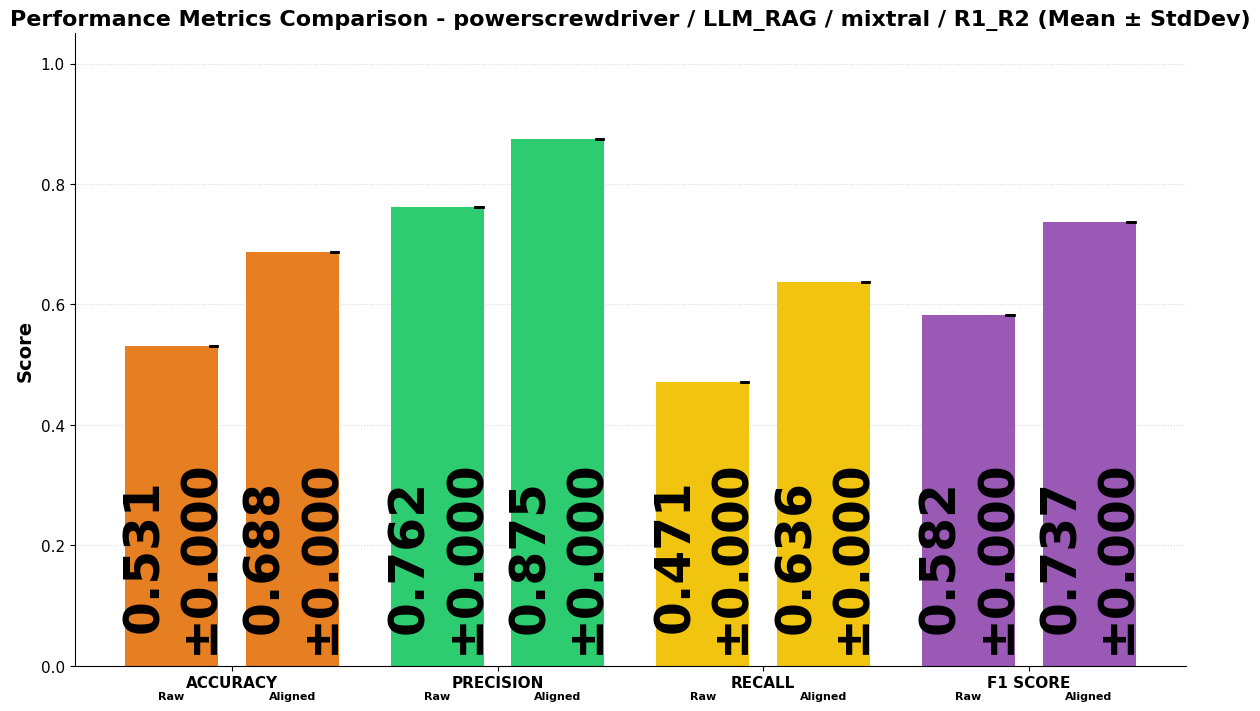

2025-04-12 23:36:22,585 - DSM_None_None_ - INFO - Plotting distance metrics...
2025-04-12 23:36:23,051 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1_R2/plots/distance_metrics_with_stddev.png


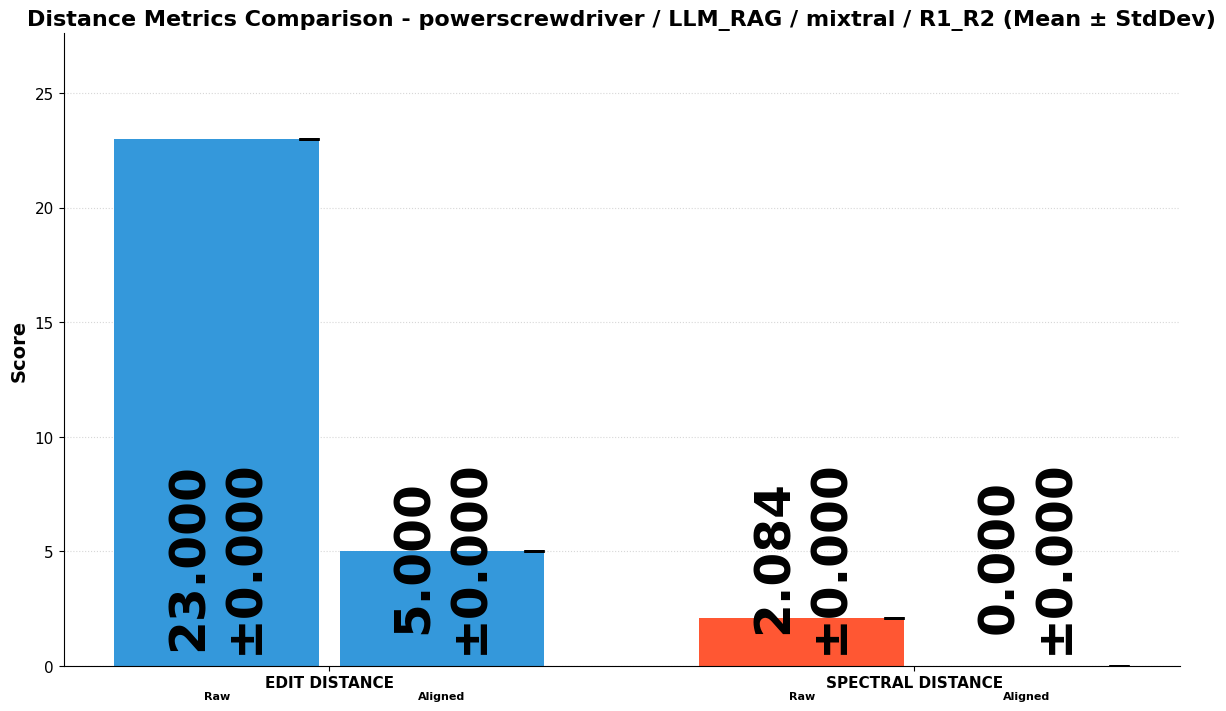

2025-04-12 23:36:23,150 - DSM_None_None_ - INFO - Plotting matrix comparison...
2025-04-12 23:36:25,241 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1_R2/plots/matrices_comparison_avg.png


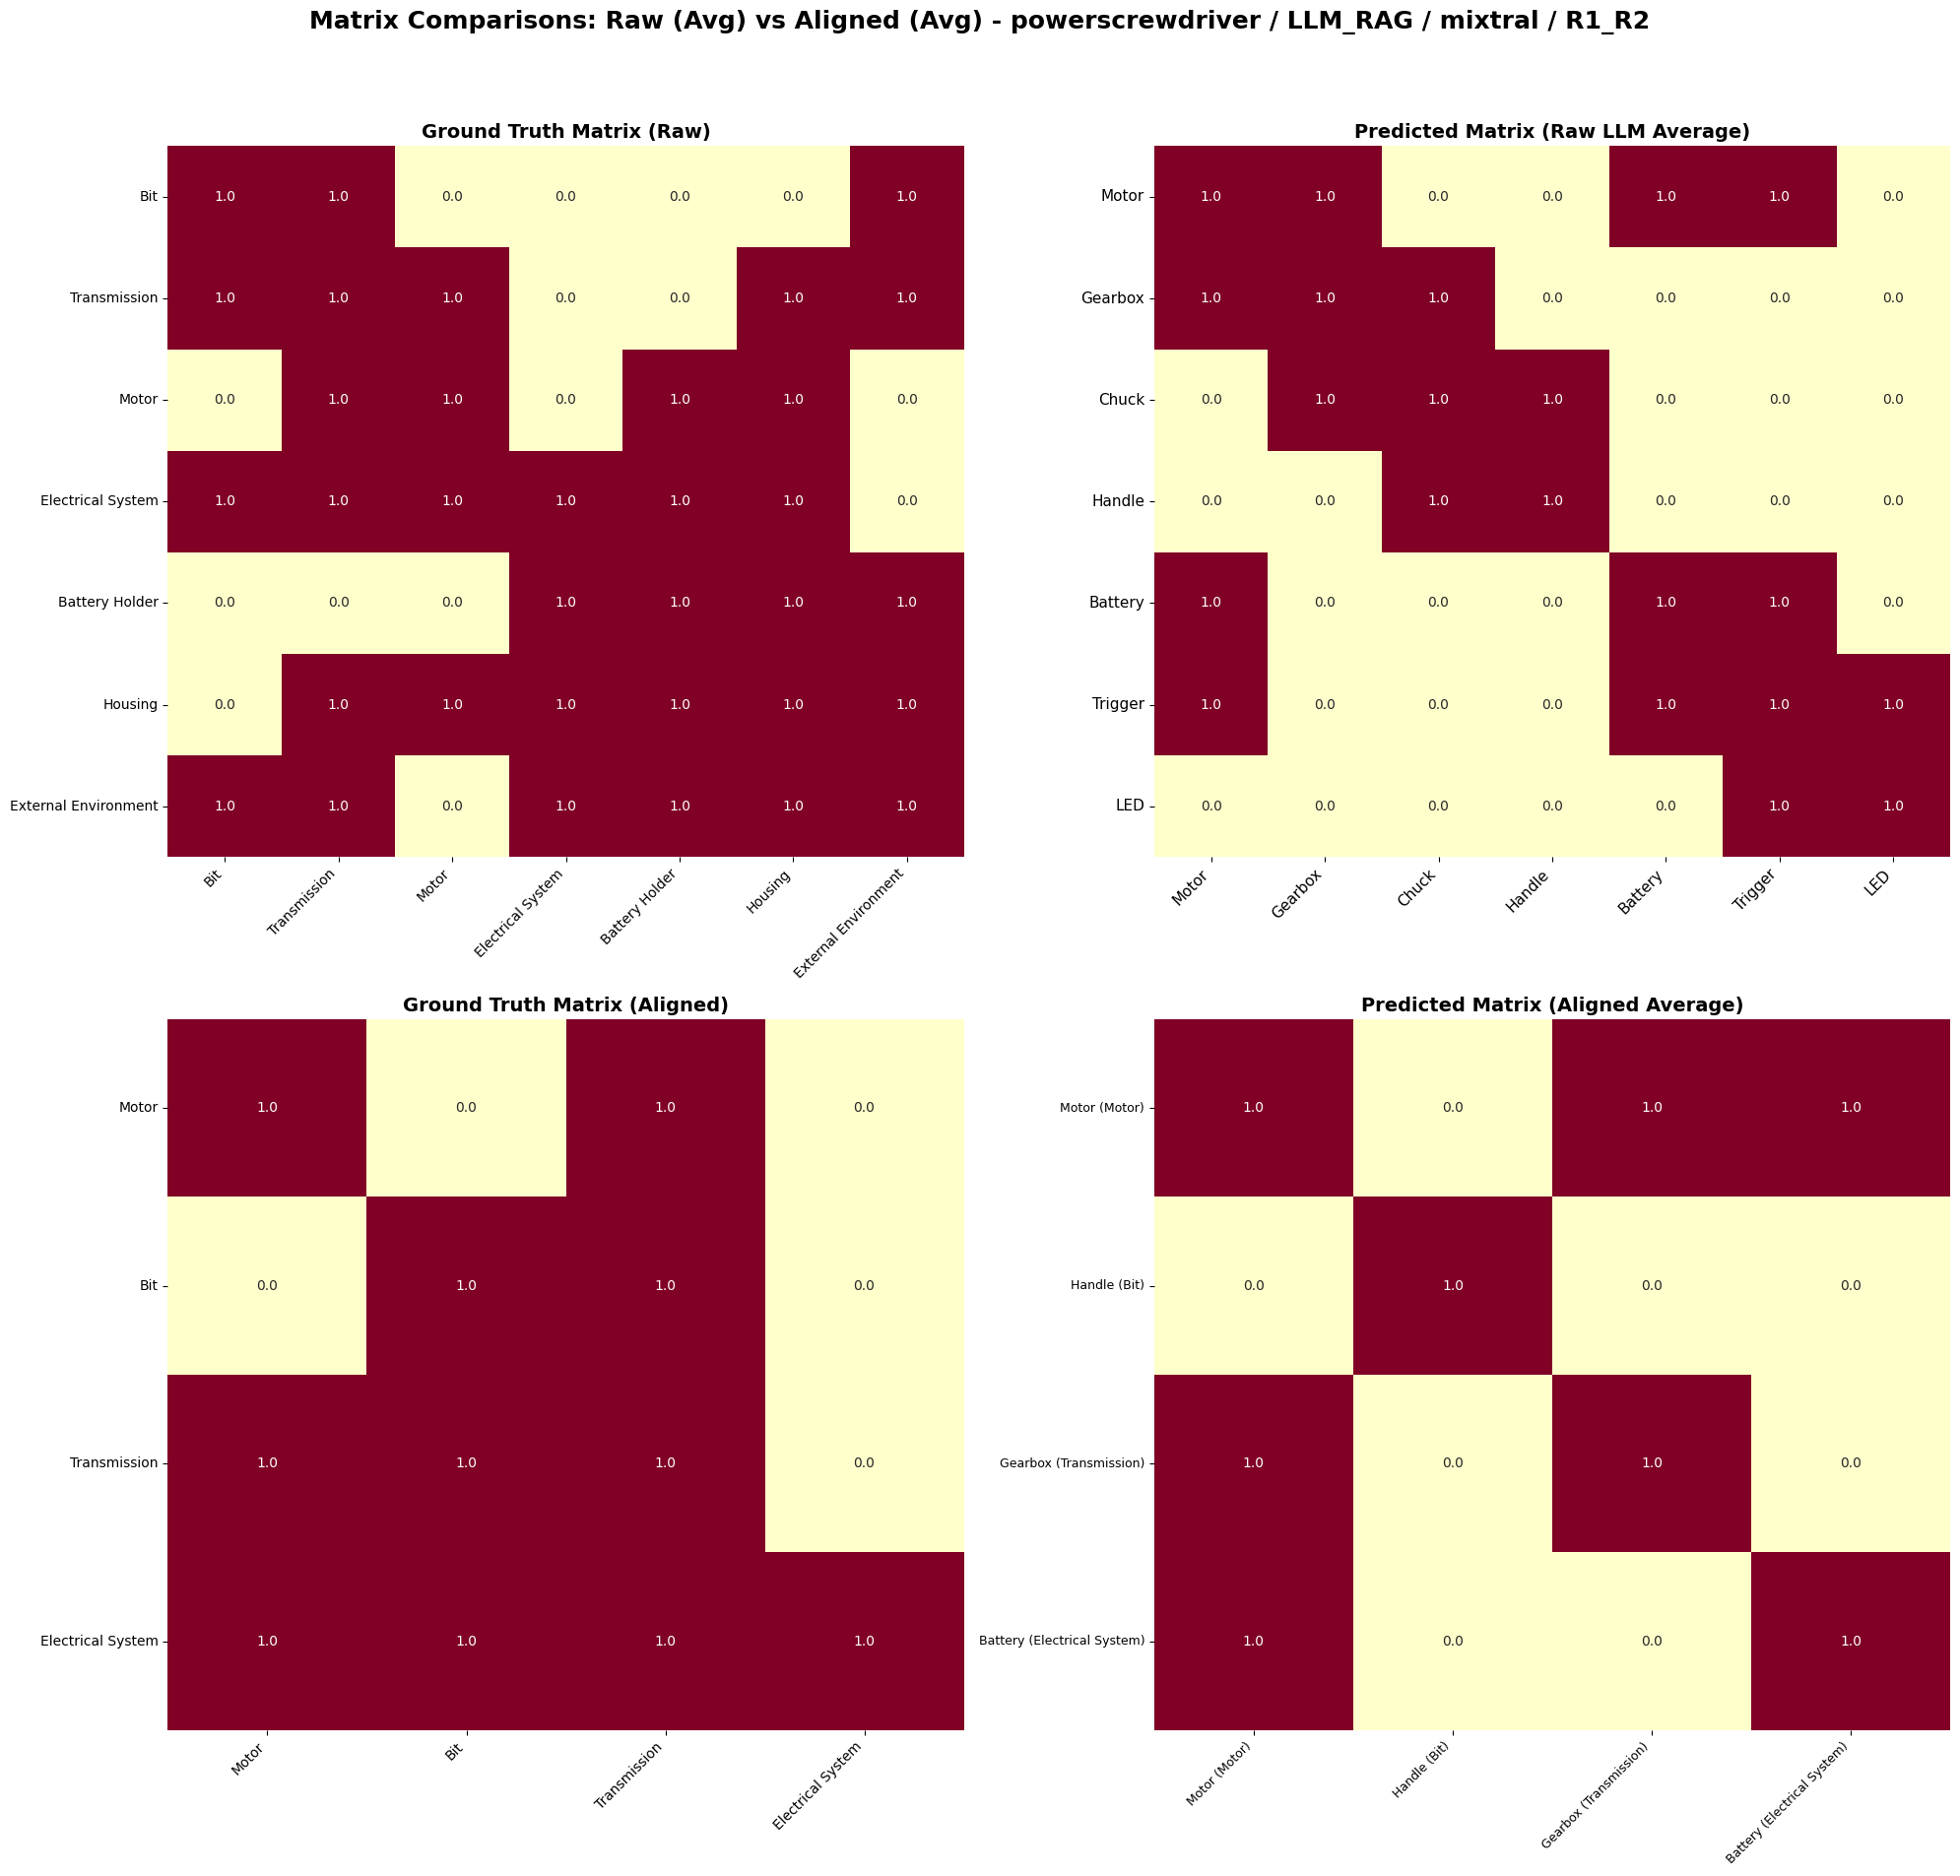

2025-04-12 23:36:25,611 - DSM_None_None_ - INFO - Plots generated and saved.
2025-04-12 23:36:25,612 - DSM_None_None_ - INFO - 
--- Results Summary for ollama:mixtral:8x22b-6k (R1_R2) ---
2025-04-12 23:36:25,613 - DSM_None_None_ - INFO - 
Raw Metrics (Mean ± StdDev):
2025-04-12 23:36:25,614 - DSM_None_None_ - INFO -   accuracy: 0.5306 ± 0.0000
2025-04-12 23:36:25,614 - DSM_None_None_ - INFO -   precision: 0.7619 ± 0.0000
2025-04-12 23:36:25,615 - DSM_None_None_ - INFO -   recall: 0.4706 ± 0.0000
2025-04-12 23:36:25,615 - DSM_None_None_ - INFO -   f1_score: 0.5818 ± 0.0000
2025-04-12 23:36:25,616 - DSM_None_None_ - INFO -   edit_distance: 23.0000 ± 0.0000
2025-04-12 23:36:25,617 - DSM_None_None_ - INFO -   spectral_distance: 2.0839 ± 0.0000
2025-04-12 23:36:25,617 - DSM_None_None_ - INFO - 
Aligned Metrics (Mean ± StdDev):
2025-04-12 23:36:25,618 - DSM_None_None_ - INFO -   accuracy: 0.6875 ± 0.0000
2025-04-12 23:36:25,618 - DSM_None_None_ - INFO -   precision: 0.8750 ± 0.0000
2025-04-1

Logger closed for ollama:mixtral:8x22b-6k (R1_R2).

---> [FIND_LATEST] Processing: powerscrewdriver / ollama:mixtral:8x22b-6k / R1_R3
---> [FIND_LATEST] CSV Path Template: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_{timestamp}/llm_rag_refs_R1_R3/average_matrix_{timestamp}.csv
---> [FIND_LATEST] Searching Exp Dirs: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_*
---> [FIND_LATEST] Checking if parent directory exists: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG
---> [FIND_LATEST] Parent directory exists!
---> [FIND_LATEST] Found Exp Dirs (sorted): ['xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356', 'xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250219-014540']
---> [FIND_LATEST] Latest Exp Dir: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/

2025-04-12 23:36:47,384 - DSM_None_None_ - INFO - Running Analysis For:
2025-04-12 23:36:47,385 - DSM_None_None_ - INFO -   Product: powerscrewdriver
2025-04-12 23:36:47,386 - DSM_None_None_ - INFO -   Model: ollama:mixtral:8x22b-6k
2025-04-12 23:36:47,387 - DSM_None_None_ - INFO -   Type: LLM_RAG
2025-04-12 23:36:47,387 - DSM_None_None_ - INFO -   Reference: R1_R3
2025-04-12 23:36:47,389 - DSM_None_None_ - INFO -   Relationship: whole-part
2025-04-12 23:36:47,390 - DSM_None_None_ - INFO -   Ground Truth Path: xLM_DSM_wip/logs/Process/gt_powerscrewdriver.csv
2025-04-12 23:36:47,391 - DSM_None_None_ - INFO -   Avg Pred Path: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1_R3/average_matrix_20250220-065356.csv
2025-04-12 23:36:47,392 - DSM_None_None_ - INFO -   Indiv JSON Path: Not Found
2025-04-12 23:36:47,398 - DSM_None_None_ - WARNING - Individual matrices JSON file not found/specified.
2025-04-12 23:

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 49
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 49
Shape of y_true_filtered: (49,)
Shape of y_pred_filtered: (49,)
First 49 y_true_filtered: [1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1.
 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1.
 1.]
First 49 y_pred_filtered: [1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0.
 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[10, 5], [21, 13]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (10, 5, 21, 13)
Manual Check - TP: 13, FP: 5, FN: 21, TN: 10
Calculated Accuracy: 0.4694  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.7222 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.3824    [Formula: TP/(

2025-04-12 23:36:48,418 - DSM_None_None_ - INFO - Attempting Component Mapping based on Average Matrix...
2025-04-12 23:36:48,419 - DSM_None_None_ - INFO - Starting get_best_component_matches function
2025-04-12 23:36:48,420 - DSM_None_None_ - INFO - Extracting model from path: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1_R3/average_matrix_20250220-065356.csv
2025-04-12 23:36:48,420 - DSM_None_None_ - INFO - Extracted model: mixtral:8x22b-6k
2025-04-12 23:36:48,425 - DSM_None_None_ - INFO - Automatic high-similarity match: Transmission -> Transmission (similarity: 1.000)
2025-04-12 23:36:48,427 - DSM_None_None_ - INFO - Automatic high-similarity match: Motor -> Motor (similarity: 1.000)
2025-04-12 23:36:48,444 - DSM_None_None_ - INFO - Prompt: 
You are an expert matching engine for cyber-physical system systems. Your task is to determine the optimal one-to-one mapping between remaining ground truth 

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 25
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 25
Shape of y_true_filtered: (25,)
Shape of y_pred_filtered: (25,)
First 25 y_true_filtered: [1. 1. 1. 0. 0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1.
 1.]
First 25 y_pred_filtered: [1. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0.
 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[5, 5], [8, 7]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (5, 5, 8, 7)
Manual Check - TP: 7, FP: 5, FN: 8, TN: 5
Calculated Accuracy: 0.4800  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.5833 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.4667    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.5185  [Formula: 2*(Prec*Rec)/(Prec+Rec)]
--- End Debugging ---


2025-04-12 23:37:43,026 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1_R3/plots/performance_metrics_with_stddev.png


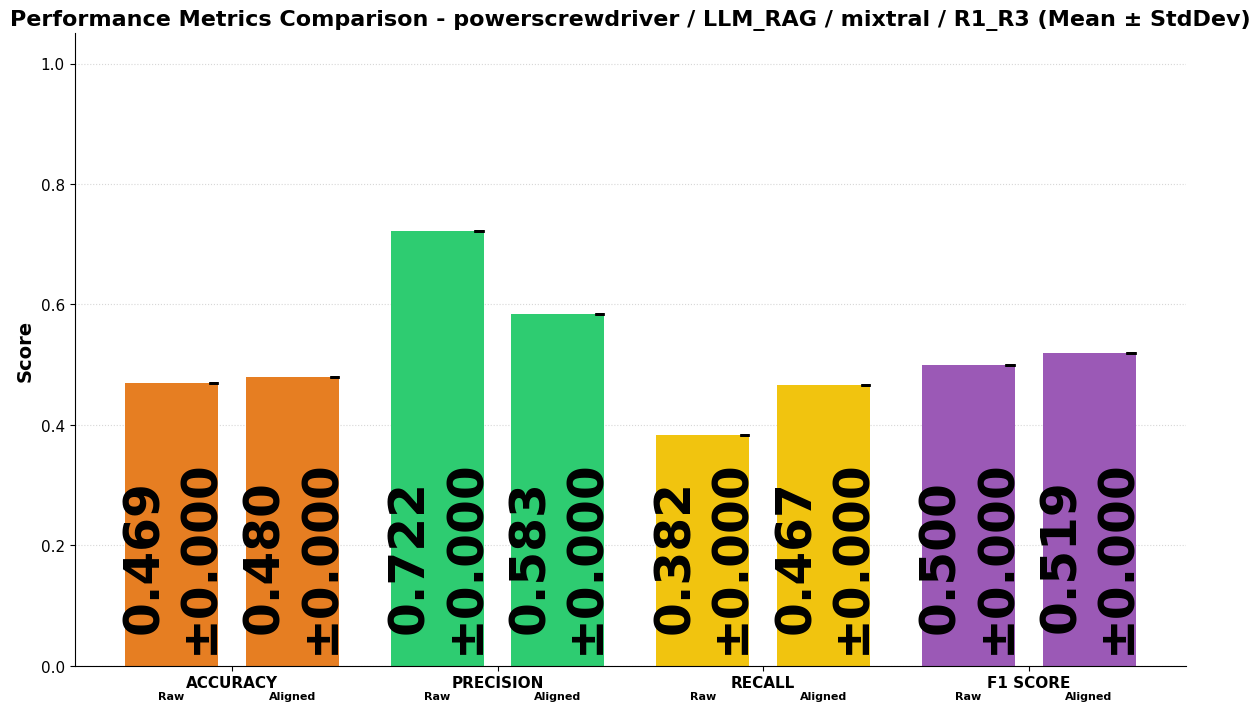

2025-04-12 23:37:43,146 - DSM_None_None_ - INFO - Plotting distance metrics...
2025-04-12 23:37:43,600 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1_R3/plots/distance_metrics_with_stddev.png


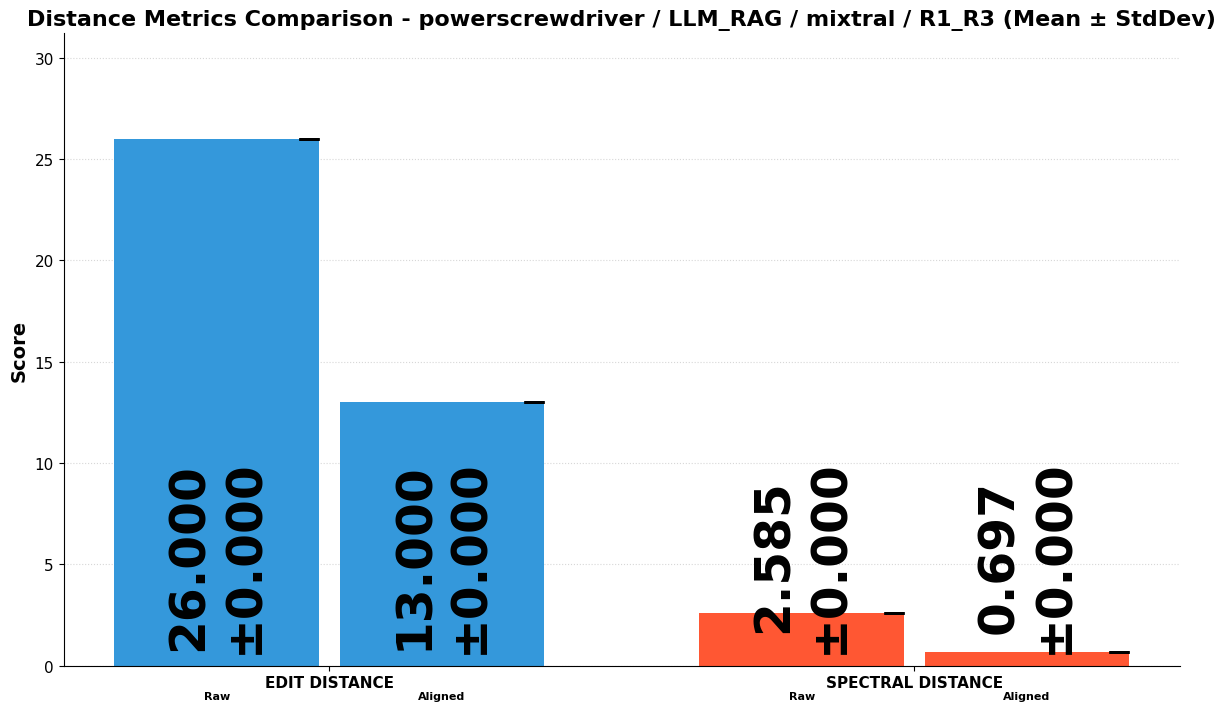

2025-04-12 23:37:43,712 - DSM_None_None_ - INFO - Plotting matrix comparison...
2025-04-12 23:37:45,875 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1_R3/plots/matrices_comparison_avg.png


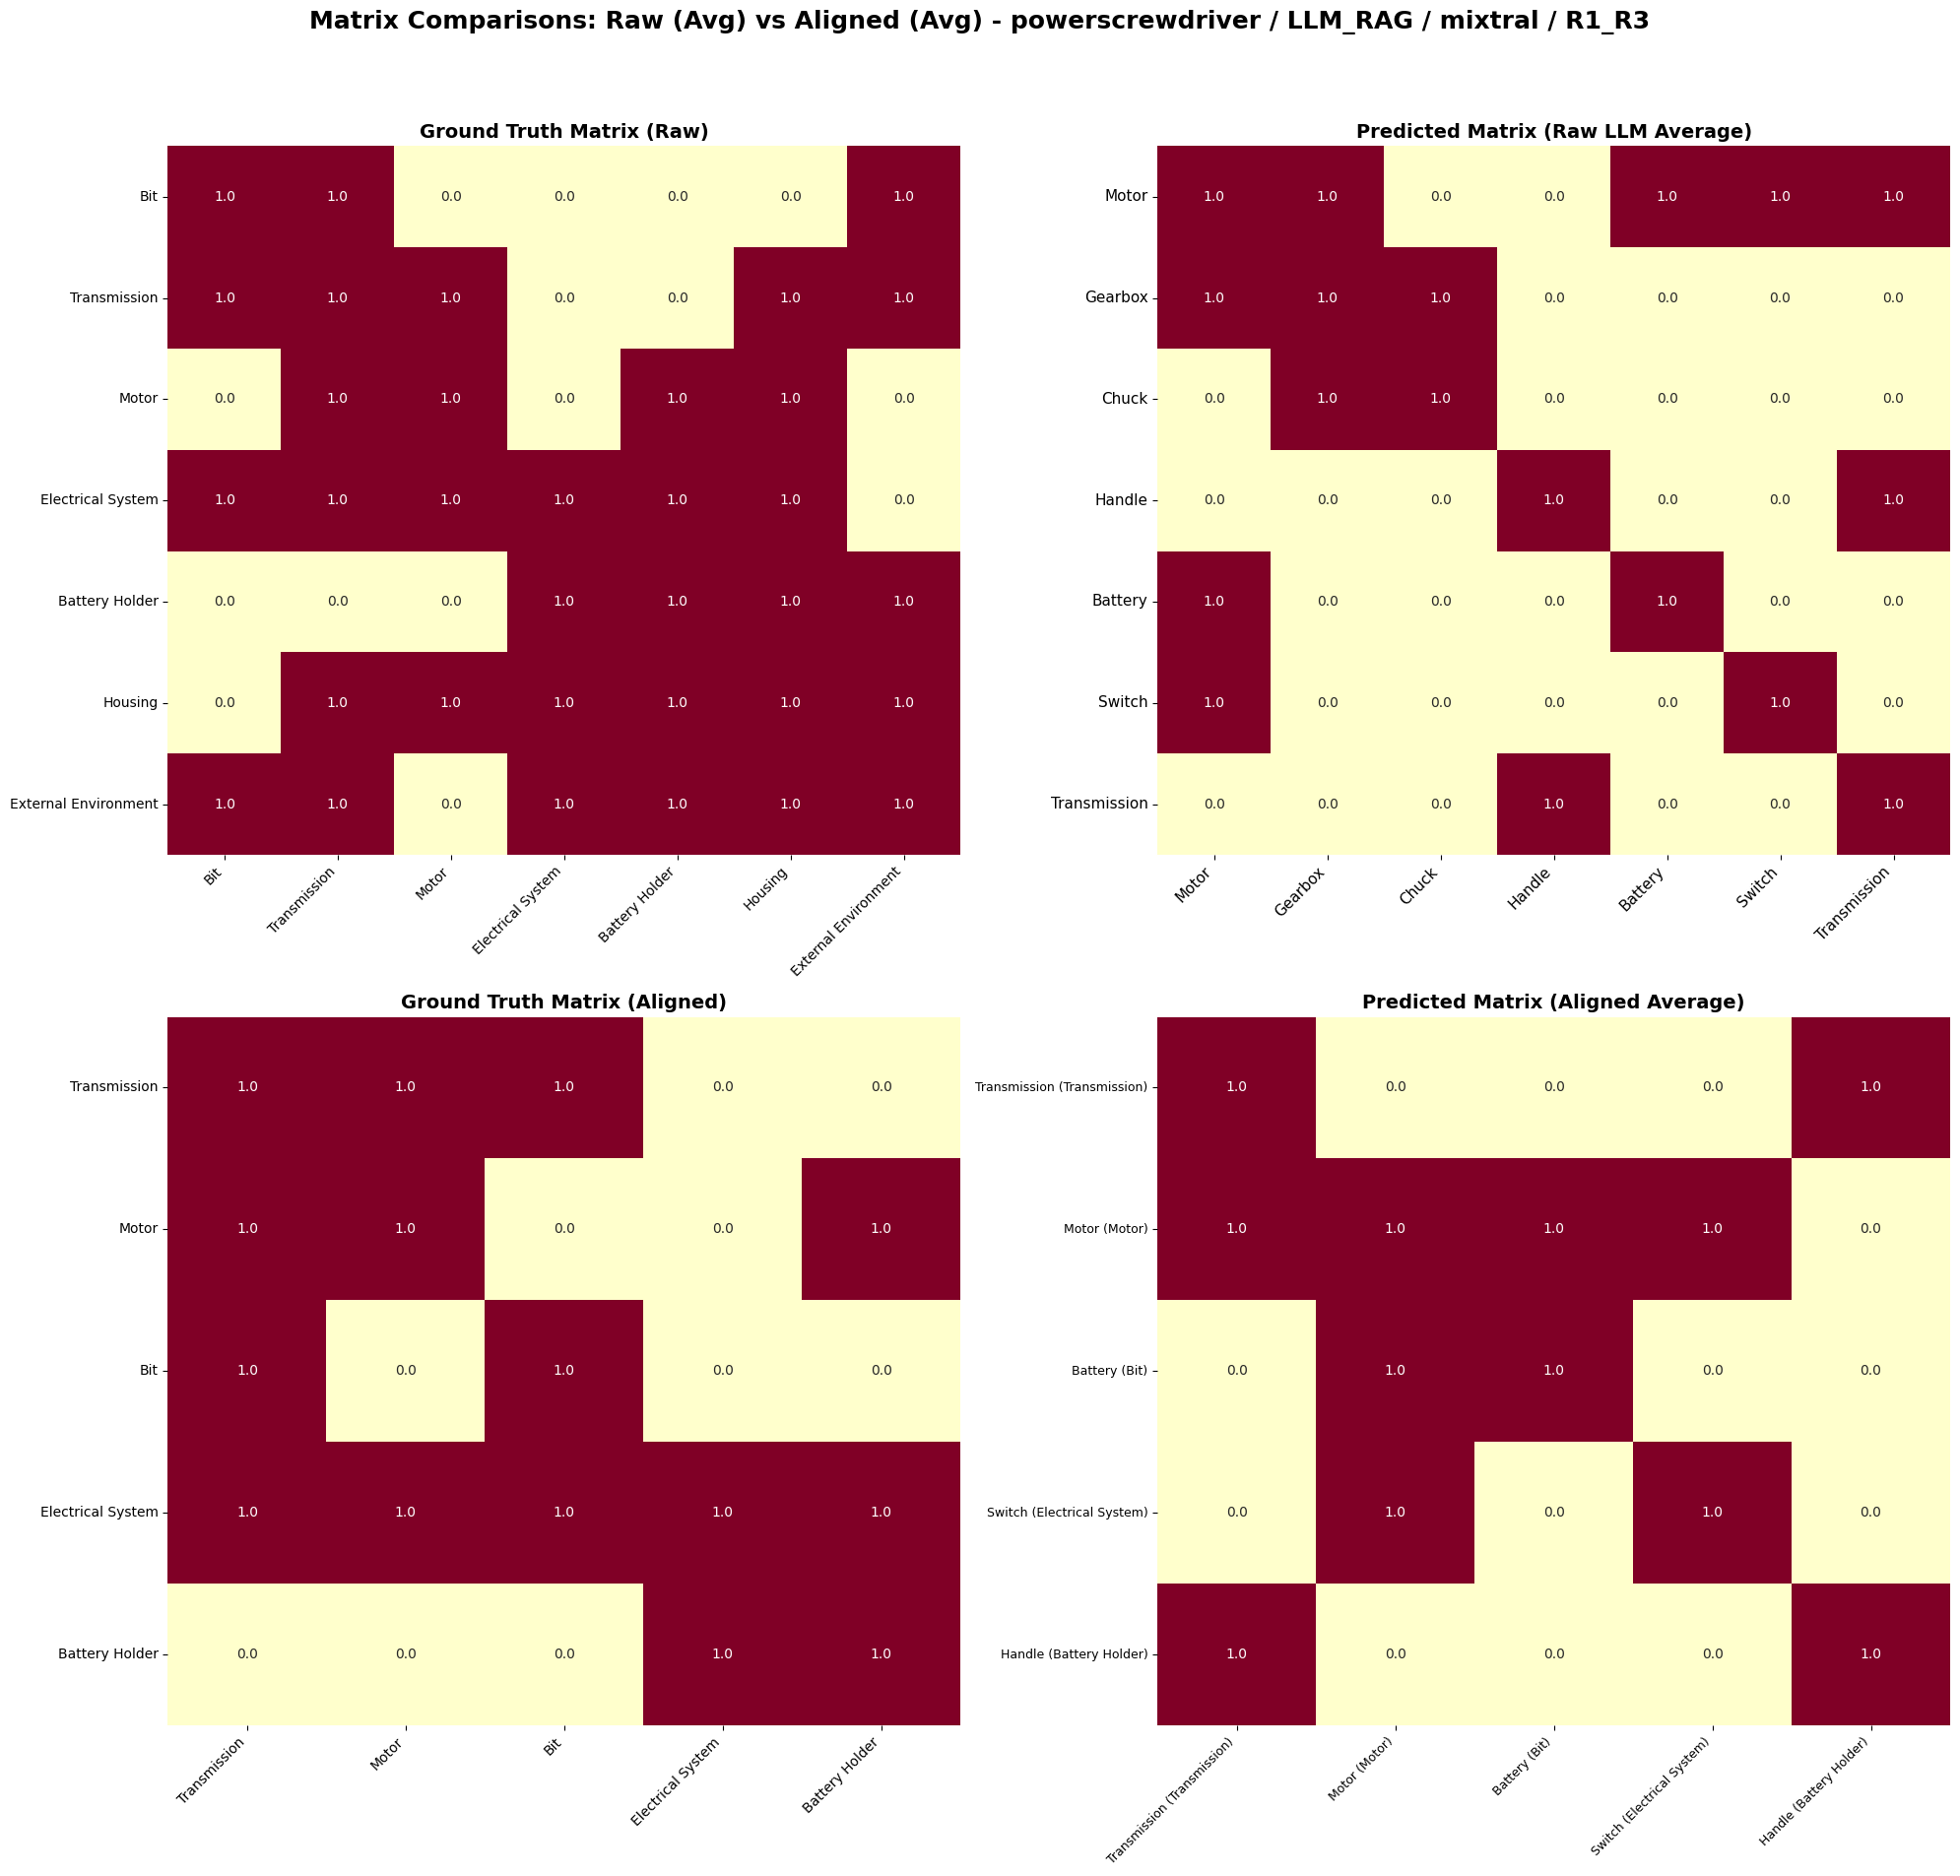

2025-04-12 23:37:46,289 - DSM_None_None_ - INFO - Plots generated and saved.
2025-04-12 23:37:46,290 - DSM_None_None_ - INFO - 
--- Results Summary for ollama:mixtral:8x22b-6k (R1_R3) ---
2025-04-12 23:37:46,291 - DSM_None_None_ - INFO - 
Raw Metrics (Mean ± StdDev):
2025-04-12 23:37:46,291 - DSM_None_None_ - INFO -   accuracy: 0.4694 ± 0.0000
2025-04-12 23:37:46,292 - DSM_None_None_ - INFO -   precision: 0.7222 ± 0.0000
2025-04-12 23:37:46,293 - DSM_None_None_ - INFO -   recall: 0.3824 ± 0.0000
2025-04-12 23:37:46,293 - DSM_None_None_ - INFO -   f1_score: 0.5000 ± 0.0000
2025-04-12 23:37:46,294 - DSM_None_None_ - INFO -   edit_distance: 26.0000 ± 0.0000
2025-04-12 23:37:46,294 - DSM_None_None_ - INFO -   spectral_distance: 2.5852 ± 0.0000
2025-04-12 23:37:46,295 - DSM_None_None_ - INFO - 
Aligned Metrics (Mean ± StdDev):
2025-04-12 23:37:46,296 - DSM_None_None_ - INFO -   accuracy: 0.4800 ± 0.0000
2025-04-12 23:37:46,296 - DSM_None_None_ - INFO -   precision: 0.5833 ± 0.0000
2025-04-1

Logger closed for ollama:mixtral:8x22b-6k (R1_R3).

---> [FIND_LATEST] Processing: powerscrewdriver / ollama:mixtral:8x22b-6k / R2_R3
---> [FIND_LATEST] CSV Path Template: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_{timestamp}/llm_rag_refs_R2_R3/average_matrix_{timestamp}.csv
---> [FIND_LATEST] Searching Exp Dirs: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_*
---> [FIND_LATEST] Checking if parent directory exists: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG
---> [FIND_LATEST] Parent directory exists!
---> [FIND_LATEST] Found Exp Dirs (sorted): ['xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356', 'xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250219-014540']
---> [FIND_LATEST] Latest Exp Dir: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/

2025-04-12 23:38:07,979 - DSM_None_None_ - INFO - Running Analysis For:
2025-04-12 23:38:07,980 - DSM_None_None_ - INFO -   Product: powerscrewdriver
2025-04-12 23:38:07,981 - DSM_None_None_ - INFO -   Model: ollama:mixtral:8x22b-6k
2025-04-12 23:38:07,982 - DSM_None_None_ - INFO -   Type: LLM_RAG
2025-04-12 23:38:07,983 - DSM_None_None_ - INFO -   Reference: R2_R3
2025-04-12 23:38:07,983 - DSM_None_None_ - INFO -   Relationship: whole-part
2025-04-12 23:38:07,985 - DSM_None_None_ - INFO -   Ground Truth Path: xLM_DSM_wip/logs/Process/gt_powerscrewdriver.csv
2025-04-12 23:38:07,986 - DSM_None_None_ - INFO -   Avg Pred Path: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R2_R3/average_matrix_20250220-065356.csv
2025-04-12 23:38:07,987 - DSM_None_None_ - INFO -   Indiv JSON Path: Not Found
2025-04-12 23:38:07,992 - DSM_None_None_ - WARNING - Individual matrices JSON file not found/specified.
2025-04-12 23:

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 49
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 49
Shape of y_true_filtered: (49,)
Shape of y_pred_filtered: (49,)
First 49 y_true_filtered: [1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1.
 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1.
 1.]
First 49 y_pred_filtered: [1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0.
 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 0. 0. 0.
 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[7, 8], [15, 19]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (7, 8, 15, 19)
Manual Check - TP: 19, FP: 8, FN: 15, TN: 7
Calculated Accuracy: 0.5306  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.7037 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.5588    [Formula: TP/(TP+

2025-04-12 23:38:09,223 - DSM_None_None_ - INFO - Attempting Component Mapping based on Average Matrix...
2025-04-12 23:38:09,224 - DSM_None_None_ - INFO - Starting get_best_component_matches function
2025-04-12 23:38:09,225 - DSM_None_None_ - INFO - Extracting model from path: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R2_R3/average_matrix_20250220-065356.csv
2025-04-12 23:38:09,225 - DSM_None_None_ - INFO - Extracted model: mixtral:8x22b-6k
2025-04-12 23:38:09,231 - DSM_None_None_ - INFO - Automatic high-similarity match: Transmission -> Transmission (similarity: 1.000)
2025-04-12 23:38:09,232 - DSM_None_None_ - INFO - Automatic high-similarity match: Motor -> Motor (similarity: 1.000)
2025-04-12 23:38:09,250 - DSM_None_None_ - INFO - Prompt: 
You are an expert matching engine for cyber-physical system systems. Your task is to determine the optimal one-to-one mapping between remaining ground truth 

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 25
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 25
Shape of y_true_filtered: (25,)
Shape of y_pred_filtered: (25,)
First 25 y_true_filtered: [1. 1. 1. 0. 0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1.
 1.]
First 25 y_pred_filtered: [1. 1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0.
 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[6, 4], [6, 9]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (6, 4, 6, 9)
Manual Check - TP: 9, FP: 4, FN: 6, TN: 6
Calculated Accuracy: 0.6000  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.6923 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.6000    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.6429  [Formula: 2*(Prec*Rec)/(Prec+Rec)]
--- End Debugging ---


2025-04-12 23:39:06,956 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R2_R3/plots/performance_metrics_with_stddev.png


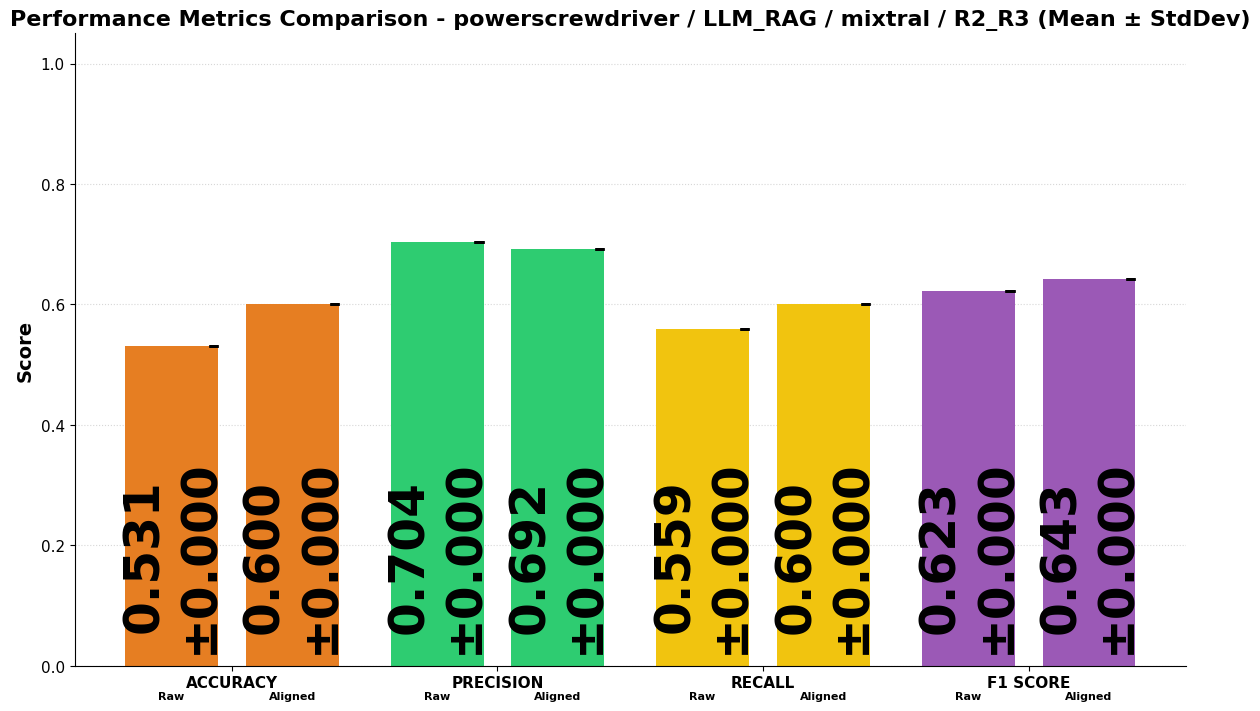

2025-04-12 23:39:07,077 - DSM_None_None_ - INFO - Plotting distance metrics...
2025-04-12 23:39:07,521 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R2_R3/plots/distance_metrics_with_stddev.png


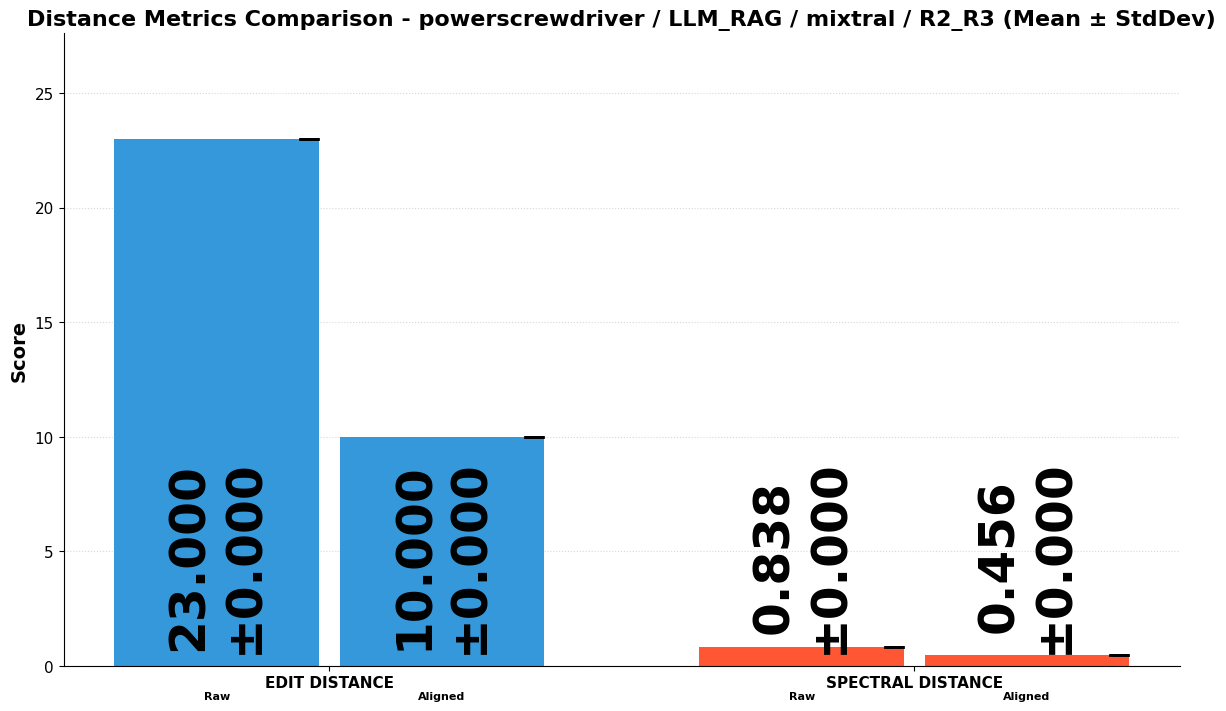

2025-04-12 23:39:07,629 - DSM_None_None_ - INFO - Plotting matrix comparison...
2025-04-12 23:39:09,884 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R2_R3/plots/matrices_comparison_avg.png


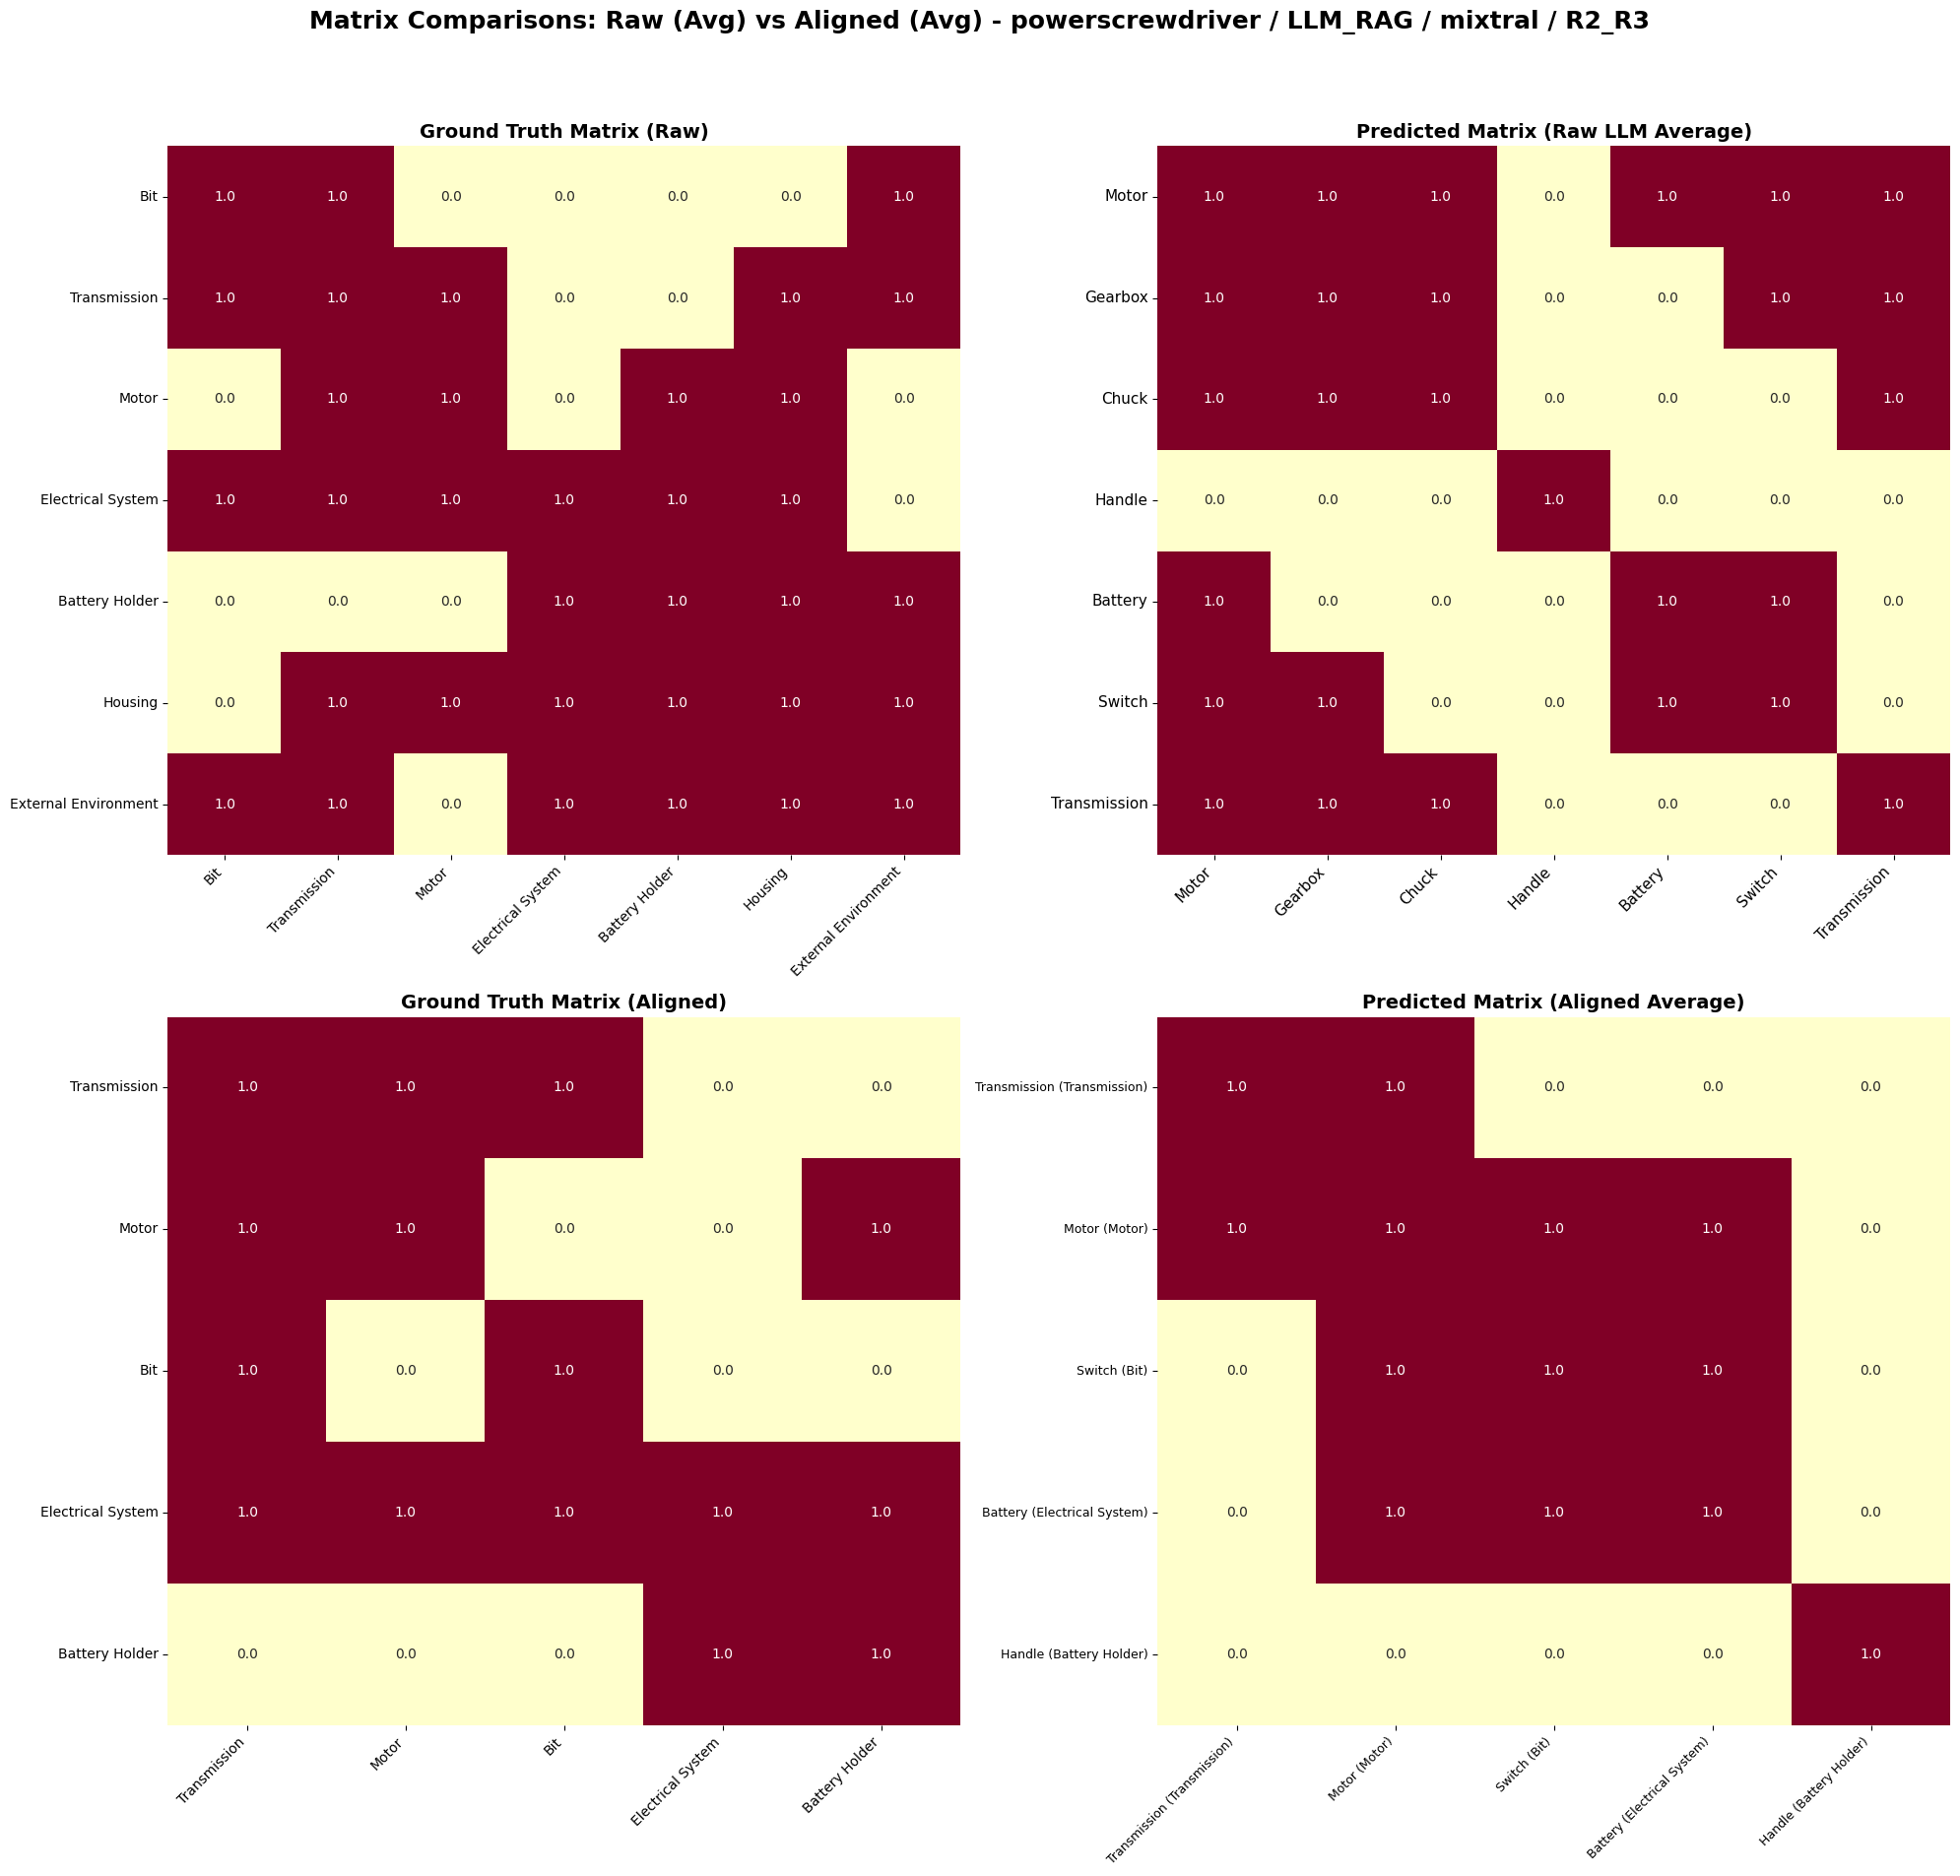

2025-04-12 23:39:10,296 - DSM_None_None_ - INFO - Plots generated and saved.
2025-04-12 23:39:10,297 - DSM_None_None_ - INFO - 
--- Results Summary for ollama:mixtral:8x22b-6k (R2_R3) ---
2025-04-12 23:39:10,298 - DSM_None_None_ - INFO - 
Raw Metrics (Mean ± StdDev):
2025-04-12 23:39:10,299 - DSM_None_None_ - INFO -   accuracy: 0.5306 ± 0.0000
2025-04-12 23:39:10,299 - DSM_None_None_ - INFO -   precision: 0.7037 ± 0.0000
2025-04-12 23:39:10,300 - DSM_None_None_ - INFO -   recall: 0.5588 ± 0.0000
2025-04-12 23:39:10,301 - DSM_None_None_ - INFO -   f1_score: 0.6230 ± 0.0000
2025-04-12 23:39:10,301 - DSM_None_None_ - INFO -   edit_distance: 23.0000 ± 0.0000
2025-04-12 23:39:10,302 - DSM_None_None_ - INFO -   spectral_distance: 0.8380 ± 0.0000
2025-04-12 23:39:10,302 - DSM_None_None_ - INFO - 
Aligned Metrics (Mean ± StdDev):
2025-04-12 23:39:10,303 - DSM_None_None_ - INFO -   accuracy: 0.6000 ± 0.0000
2025-04-12 23:39:10,304 - DSM_None_None_ - INFO -   precision: 0.6923 ± 0.0000
2025-04-1

Logger closed for ollama:mixtral:8x22b-6k (R2_R3).

---> [FIND_LATEST] Processing: powerscrewdriver / ollama:mixtral:8x22b-6k / R1_R2_R3
---> [FIND_LATEST] CSV Path Template: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_{timestamp}/llm_rag_refs_R1_R2_R3/average_matrix_{timestamp}.csv
---> [FIND_LATEST] Searching Exp Dirs: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_*
---> [FIND_LATEST] Checking if parent directory exists: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG
---> [FIND_LATEST] Parent directory exists!
---> [FIND_LATEST] Found Exp Dirs (sorted): ['xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356', 'xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250219-014540']
---> [FIND_LATEST] Latest Exp Dir: xLM_DSM_wip/logs/Process/ii/powerscrewd

2025-04-12 23:39:32,098 - DSM_None_None_ - INFO - Running Analysis For:
2025-04-12 23:39:32,099 - DSM_None_None_ - INFO -   Product: powerscrewdriver
2025-04-12 23:39:32,100 - DSM_None_None_ - INFO -   Model: ollama:mixtral:8x22b-6k
2025-04-12 23:39:32,101 - DSM_None_None_ - INFO -   Type: LLM_RAG
2025-04-12 23:39:32,102 - DSM_None_None_ - INFO -   Reference: R1_R2_R3
2025-04-12 23:39:32,103 - DSM_None_None_ - INFO -   Relationship: whole-part
2025-04-12 23:39:32,105 - DSM_None_None_ - INFO -   Ground Truth Path: xLM_DSM_wip/logs/Process/gt_powerscrewdriver.csv
2025-04-12 23:39:32,106 - DSM_None_None_ - INFO -   Avg Pred Path: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1_R2_R3/average_matrix_20250220-065356.csv
2025-04-12 23:39:32,106 - DSM_None_None_ - INFO -   Indiv JSON Path: Not Found
2025-04-12 23:39:32,112 - DSM_None_None_ - WARNING - Individual matrices JSON file not found/specified.
2025-04-

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 49
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 49
Shape of y_true_filtered: (49,)
Shape of y_pred_filtered: (49,)
First 49 y_true_filtered: [1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1.
 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1.
 1.]
First 49 y_pred_filtered: [1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0.
 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[10, 5], [16, 18]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (10, 5, 16, 18)
Manual Check - TP: 18, FP: 5, FN: 16, TN: 10
Calculated Accuracy: 0.5714  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.7826 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.5294    [Formula: TP/(

2025-04-12 23:39:33,113 - DSM_None_None_ - INFO - Attempting Component Mapping based on Average Matrix...
2025-04-12 23:39:33,114 - DSM_None_None_ - INFO - Starting get_best_component_matches function
2025-04-12 23:39:33,115 - DSM_None_None_ - INFO - Extracting model from path: xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1_R2_R3/average_matrix_20250220-065356.csv
2025-04-12 23:39:33,115 - DSM_None_None_ - INFO - Extracted model: mixtral:8x22b-6k
2025-04-12 23:39:33,121 - DSM_None_None_ - INFO - Automatic high-similarity match: Motor -> Motor (similarity: 1.000)
2025-04-12 23:39:33,142 - DSM_None_None_ - INFO - Prompt: 
You are an expert matching engine for cyber-physical system systems. Your task is to determine the optimal one-to-one mapping between remaining ground truth and predicted major components.

Remaining Ground Truth Components:
['Bit', 'Transmission', 'Electrical System', 'Battery Holder'

--- Debugging cell_by_cell_classification_metrics ---
Original matrix size (flattened): 25
Number of cells excluded (prediction not 0 or 1): 0
Filtered matrix size for metrics: 25
Shape of y_true_filtered: (25,)
Shape of y_pred_filtered: (25,)
First 25 y_true_filtered: [1. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1.
 1.]
First 25 y_pred_filtered: [1. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1.
 1.]
Confusion Matrix (rows=True[0,1], cols=Pred[0,1]): [[7, 3], [3, 12]]
Confusion Matrix Ravelled (TN, FP, FN, TP): (7, 3, 3, 12)
Manual Check - TP: 12, FP: 3, FN: 3, TN: 7
Calculated Accuracy: 0.7600  [Formula: (TP+TN)/(TP+TN+FP+FN)]
Calculated Precision (binary, label=1, zero_division=0): 0.8000 [Formula: TP/(TP+FP)]
Calculated Recall (binary, label=1, zero_division=0): 0.8000    [Formula: TP/(TP+FN)]
Calculated F1 Score (binary, label=1, zero_division=0): 0.8000  [Formula: 2*(Prec*Rec)/(Prec+Rec)]
--- End Debugging ---


2025-04-12 23:40:37,845 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1_R2_R3/plots/performance_metrics_with_stddev.png


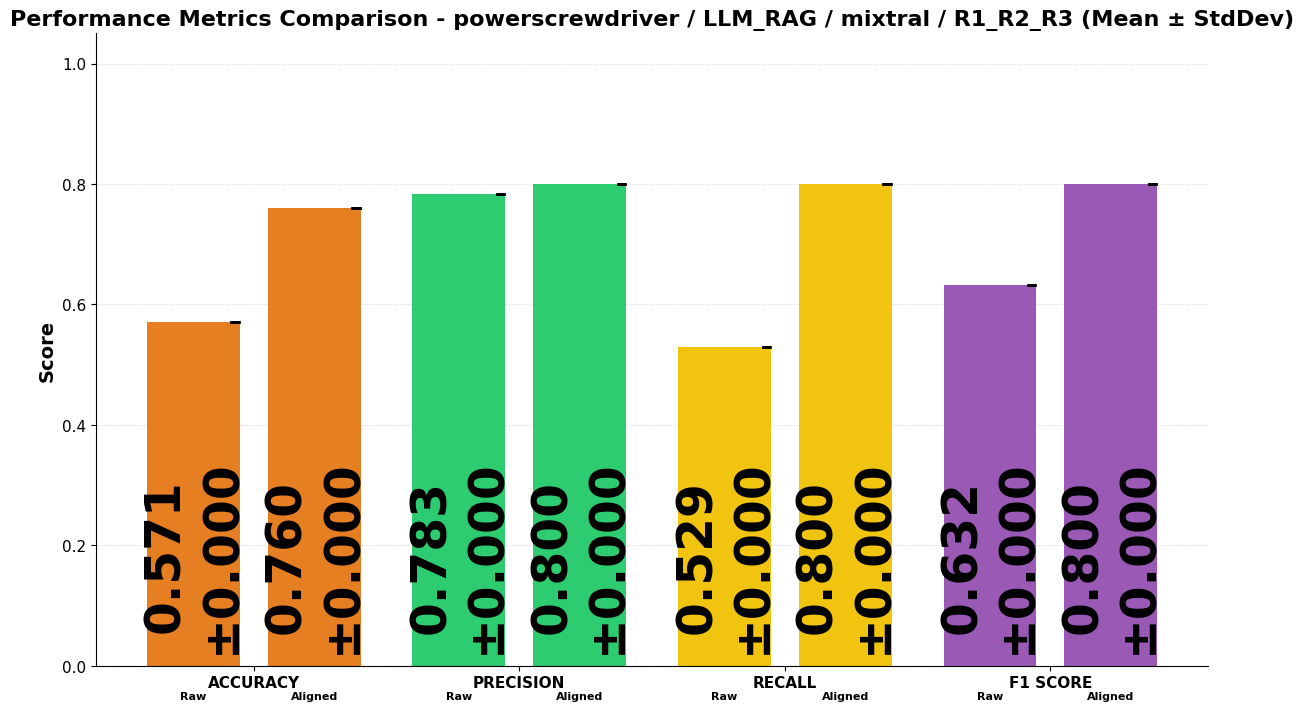

2025-04-12 23:40:37,966 - DSM_None_None_ - INFO - Plotting distance metrics...
2025-04-12 23:40:38,398 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1_R2_R3/plots/distance_metrics_with_stddev.png


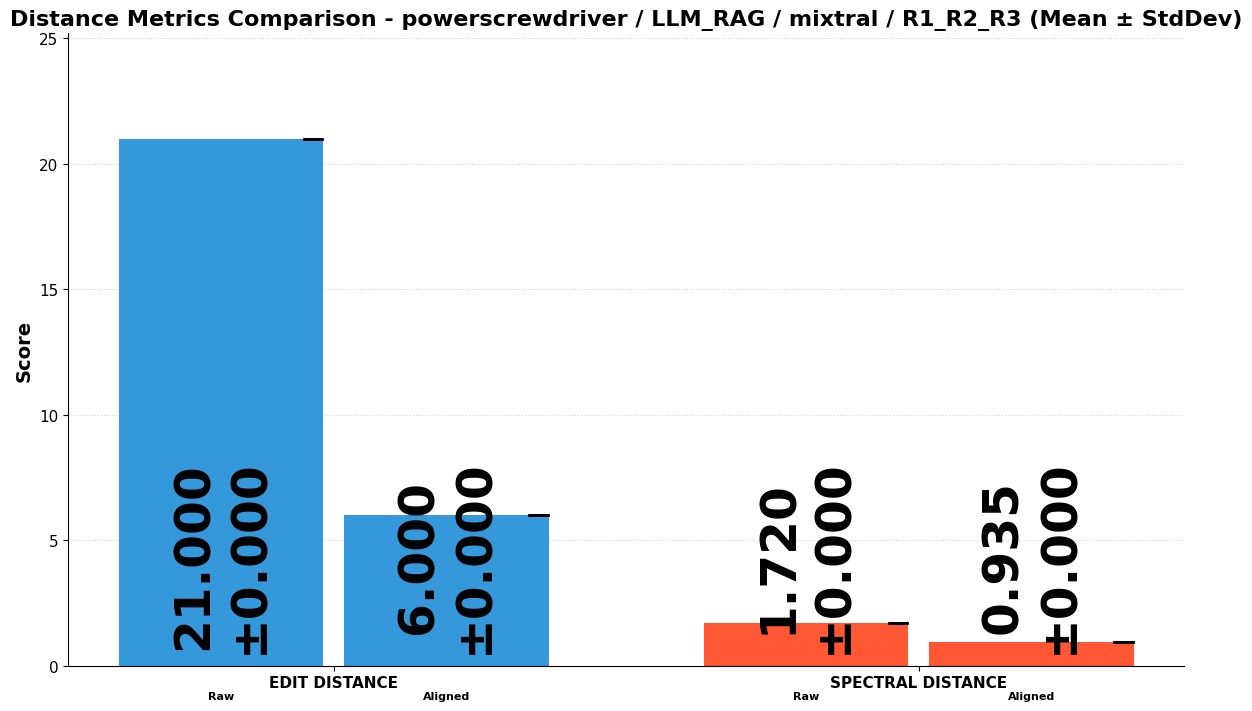

2025-04-12 23:40:38,497 - DSM_None_None_ - INFO - Plotting matrix comparison...
2025-04-12 23:40:40,625 - DSM_None_None_ - INFO - Saved plot to xLM_DSM_wip/logs/Process/ii/powerscrewdriver/te3s/LLM_RAG/experiment_llm_rag_ollama:mixtral:8x22b-6k_20250220-065356/llm_rag_refs_R1_R2_R3/plots/matrices_comparison_avg.png


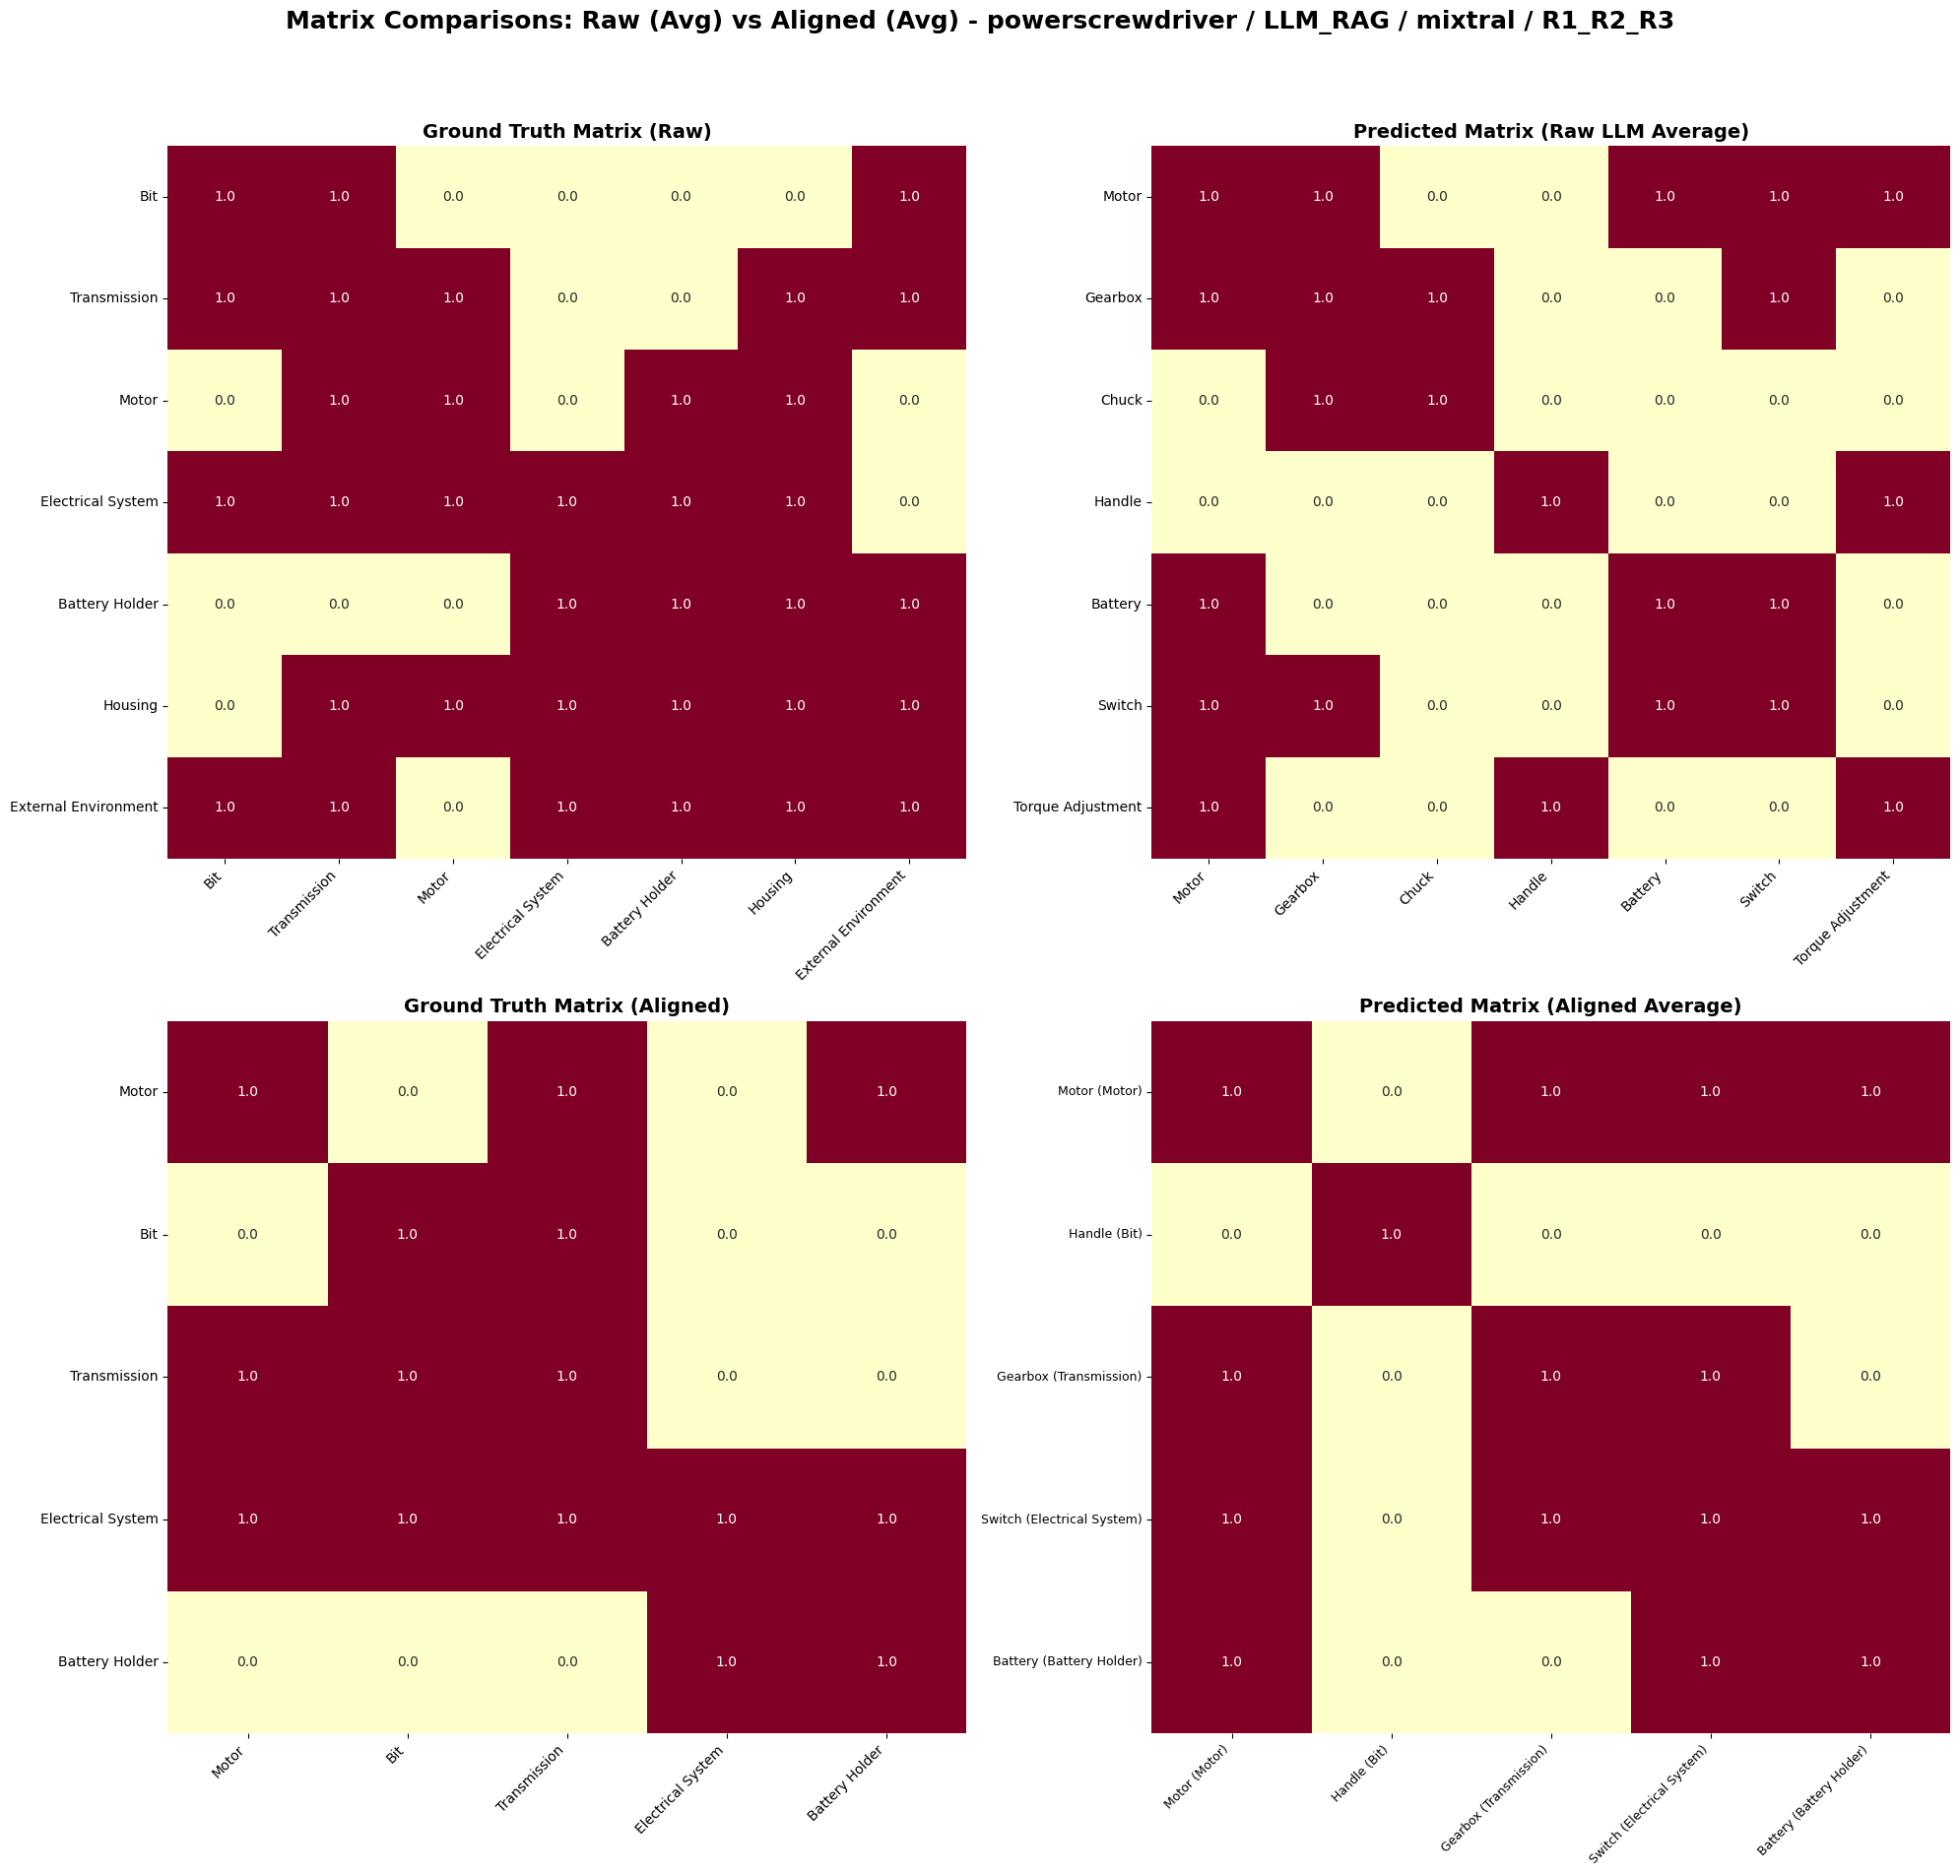

2025-04-12 23:40:41,015 - DSM_None_None_ - INFO - Plots generated and saved.
2025-04-12 23:40:41,017 - DSM_None_None_ - INFO - 
--- Results Summary for ollama:mixtral:8x22b-6k (R1_R2_R3) ---
2025-04-12 23:40:41,017 - DSM_None_None_ - INFO - 
Raw Metrics (Mean ± StdDev):
2025-04-12 23:40:41,018 - DSM_None_None_ - INFO -   accuracy: 0.5714 ± 0.0000
2025-04-12 23:40:41,018 - DSM_None_None_ - INFO -   precision: 0.7826 ± 0.0000
2025-04-12 23:40:41,019 - DSM_None_None_ - INFO -   recall: 0.5294 ± 0.0000
2025-04-12 23:40:41,020 - DSM_None_None_ - INFO -   f1_score: 0.6316 ± 0.0000
2025-04-12 23:40:41,020 - DSM_None_None_ - INFO -   edit_distance: 21.0000 ± 0.0000
2025-04-12 23:40:41,021 - DSM_None_None_ - INFO -   spectral_distance: 1.7198 ± 0.0000
2025-04-12 23:40:41,021 - DSM_None_None_ - INFO - 
Aligned Metrics (Mean ± StdDev):
2025-04-12 23:40:41,022 - DSM_None_None_ - INFO -   accuracy: 0.7600 ± 0.0000
2025-04-12 23:40:41,024 - DSM_None_None_ - INFO -   precision: 0.8000 ± 0.0000
2025-0

Logger closed for ollama:mixtral:8x22b-6k (R1_R2_R3).


In [3]:
def main():
    # Experiment code
    for experiment in experiments:
        run_analysis(experiment)

# This allows the code to work both in notebook and as a script
if __name__ == "__main__":
    main()
else:
    # When imported as a module in a notebook
    print("Script imported as module - use main() to run experiments")